From Price Spike to Monitoring Signal

Detecting Widespread and Persistent Food-Price Shocks Across Indonesia

Primary Analysis Period: January 2021–December 2025

Analytical Coverage: 12 consistently recorded commodities across 32 provinces

# 1. Project Background

Food-price stability is important for maintaining household purchasing power and supporting broader economic stability. However, food-price movements are not uniform across Indonesia. A commodity that remains relatively stable in one province may experience substantial fluctuations in another.

Monitoring average prices alone may not reveal the full extent of the issue. A commodity with a high price is not necessarily unstable, while a relatively affordable commodity may experience frequent and extreme price movements.

Price increases also differ in their level of urgency. Some increases occur temporarily within a limited number of provinces, while others affect many regions simultaneously and remain elevated for several months. Distinguishing between these conditions can help determine which commodities and regions require closer monitoring.

This project analyzes monthly food prices across Indonesian provinces to distinguish localized price fluctuations from widespread and persistent food-price shocks.

# 2. Problem Statement

Traditional descriptive analysis often focuses on the most expensive commodities or regions. However, identifying the highest price alone does not explain whether a price movement is unusual, widespread, persistent, or likely to require further monitoring.

A 25% increase in one province may represent a localized and temporary fluctuation. In contrast, a 15% increase occurring simultaneously across multiple provinces may indicate broader price pressure.

Therefore, this project moves beyond simple price rankings by evaluating food-price movements based on:

- The magnitude of the price change

- The number of affected provinces

- The frequency of price spikes

- The persistence of elevated prices

- The speed of recovery after a spike

- The disparity of prices across regions

The analysis is designed as an exploratory food-price monitoring framework rather than an official measure of inflation.

# 3. Project Objective

The primary objective of this project is to develop a data-driven framework for identifying food-price movements that may require priority monitoring.

- The specific objectives are to:

- Clean and standardize monthly food-price records across Indonesian provinces.

- Construct a consistent five-year dataset for fair historical comparisons.

- Measure month-to-month and year-on-year price changes.

- Identify commodities with the highest long-term price volatility.

- Distinguish localized price fluctuations from geographically widespread shocks.

- Measure the intensity, breadth, frequency, and persistence of price pressure.

- Identify provinces that tend to experience price pressure earlier than others.

- Evaluate how quickly prices recover after a spike.

- Examine persistent price disparities across provinces.

- Develop a monitoring watchlist for province–commodity combinations.

- Present the findings through analytical visualizations and an interactive dashboard.

# 4. Business Questions

This project addresses the following decision-oriented questions:

1. How did food prices change between 2021 and 2025?

2. Which commodities experienced the greatest long-term price increases and volatility?

3. Which price spikes were isolated local events, and which developed into geographically widespread shocks?

4. Which commodity shocks combined the greatest geographical breadth with the highest price-change intensity?

5. Which provinces tended to show early price-pressure signals before similar movements appeared more broadly?

6. Which provinces recovered most quickly after a food-price spike?

7. Which commodities were most likely to remain elevated after an initial spike?

8. Which commodities frequently experienced simultaneous price pressure?

9. Did regional price disparities return to normal after a shock or remain persistently wide?

10. Which province–commodity combinations should be prioritized in a food-price monitoring watchlist?


# 5. Dataset Overview

The dataset contains monthly food-price observations across Indonesian provinces from January 2021 to January 2026.

Each row represents the recorded price of one commodity in one province during a particular month and year.

Dataset Source

The dataset was obtained from an Indonesian government open-data source and contains provincial-level consumer food-price records.

Source organization: Badan Pangan Nasional
Distribution portal: Satu Data Indonesia
Reference: https://data.go.id/

# 6. Analysis Scope

This project uses two complementary analytical scopes.

## 6.1 Primary Scope: Longitudinal Analysis, 2021–2025

The primary analysis covers January 2021 to December 2025.

To maintain comparable observations over time, the analysis uses a balanced panel containing:

- 60 consecutive months

- 12 consistently recorded commodities

- 32 geographically consistent provinces

- 23,040 expected province–commodity–month observations

The Papua region is excluded from the longitudinal analysis because its provincial boundaries and identification codes changed after regional expansion in 2024. Including these observations would compare geographically different areas under similar province labels. The six current Papua provinces remain included in the separate 2025 regional snapshot.

The 12 consistently recorded commodities are:

1. Bawang Merah

2. Bawang Putih (Bonggol)

3. Beras Medium

4. Beras Premium

5. Cabai Merah Keriting

6. Cabai Rawit Merah

7. Daging Ayam Ras

8. Daging Sapi Murni

9. Gula Pasir Lokal/Curah

10. Kedelai Biji Kering

11. Minyak Goreng Kemasan

12. Telur Ayam Ras

Commodities and provinces introduced during later years are excluded from the longitudinal analysis because they do not have equivalent historical coverage.

This balanced panel is used to analyze:

- Five-year price trends

- Monthly and annual price changes

- Long-term volatility

- Repeated monthly patterns

- Price-spike frequency

- Shock persistence

- Post-spike recovery

- Regional price disparities

- Descriptive lead–lag patterns


## 6.2 Exclusion of 2026 Data

Data from 2026 is excluded from the main analysis because it only contains observations for January. Including one incomplete year could distort annual comparisons, volatility measurements, and seasonal interpretations.

# DATA PREPARATION

The next section begins the technical analysis by importing the required libraries, loading the raw dataset, and examining its initial structure.

## Import Libraries and Load the Dataset

This section imports the libraries required for data preparation and loads the raw Excel dataset.

A separate copy of the raw data is preserved so that subsequent cleaning operations do not alter the original dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## Upload the Raw Dataset

The raw dataset is uploaded in Excel format. Only the food-price Excel file is required for this analysis.

In [ ]:
df_raw = pd.read_excel('bahan_pangan.xlsx')
df = df_raw.copy()

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [ ]:
df.head()

,Kode Provinsi,Nama Provinsi,Komoditas,Tahun,Bulan,Harga
0,11,Aceh,Beras Premium,2021,Januari,"Rp12,072"
1,12,Sumatera Utara,Beras Premium,2021,Januari,"Rp12,523"
2,13,Sumatera Barat,Beras Premium,2021,Januari,"Rp13,096"
3,14,Riau,Beras Premium,2021,Januari,"Rp14,605"
4,15,Jambi,Beras Premium,2021,Januari,"Rp12,323"


Before cleaning, the dataset is examined to understand its dimensions, variable types, time coverage, and potential data-quality issues.

In [ ]:
print(f"Number of rows    : {df.shape[0]:,}")
print(f"Number of columns : {df.shape[1]}")

print("\nColumn names:")
print(df.columns.tolist())

Number of rows    : 36,348
Number of columns : 6

Column names:
['Kode Provinsi', 'Nama Provinsi', 'Komoditas', 'Tahun', 'Bulan', 'Harga']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36348 entries, 0 to 36347
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Kode Provinsi  36348 non-null  int64 
 1   Nama Provinsi  36348 non-null  object
 2   Komoditas      36348 non-null  object
 3   Tahun          36348 non-null  int64 
 4   Bulan          36348 non-null  object
 5   Harga          35603 non-null  object
dtypes: int64(2), object(4)
memory usage: 1.7+ MB


## Format Issue

The `Harga` column is stored as an `object` instead of a numeric variable because it contains the `Rp` currency prefix, thousands separators, missing values, and `-` symbols representing unavailable prices.

The currency prefix and thousands separators must be removed before the values can be converted into numeric format. Unavailable values will be retained as missing values rather than automatically imputed.

In [ ]:
df["Harga_Raw"] = df["Harga"]

df["Harga"] = (
    df["Harga"]
    .astype("string")
    .str.strip()
    .replace({
        "-": pd.NA,
        "": pd.NA
    })
    .str.replace("Rp", "", regex=False)
    .str.replace(",", "", regex=False)
    .pipe(pd.to_numeric, errors="coerce")
    .astype("Int64")
)

In [ ]:
df.sample(10, random_state=42)

,Kode Provinsi,Nama Provinsi,Komoditas,Tahun,Bulan,Harga,Harga_Raw
19460,64,Kalimantan Timur,Bawang Merah,2024,Juli,37436,"Rp37,436"
17448,71,Sulawesi Utara,Minyak Goreng Curah,2024,April,17242,"Rp17,242"
34483,94,Papua Tengah,Beras Medium,2025,Desember,18459,"Rp18,459"
9918,71,Sulawesi Utara,Bawang Merah,2023,Januari,43138,"Rp43,138"
6149,76,Sulawesi Barat,Beras Premium,2022,April,11283,"Rp11,283"
3038,33,Jawa Tengah,Cabai Merah Keriting,2021,Agustus,15542,"Rp15,542"
22236,71,Sulawesi Utara,Tepung Terigu Curah,2024,Oktober,10755,"Rp10,755"
2649,82,Maluku Utara,Cabai Merah Keriting,2021,Juli,54518,"Rp54,518"
5179,32,Jawa Barat,Daging Ayam Ras,2022,Januari,37339,"Rp37,339"
33636,71,Sulawesi Utara,Bawang Putih (Bonggol),2025,November,40669,"Rp40,669"


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36348 entries, 0 to 36347
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Kode Provinsi  36348 non-null  int64 
 1   Nama Provinsi  36348 non-null  object
 2   Komoditas      36348 non-null  object
 3   Tahun          36348 non-null  int64 
 4   Bulan          36348 non-null  object
 5   Harga          35138 non-null  Int64 
 6   Harga_Raw      35603 non-null  object
dtypes: Int64(1), int64(2), object(4)
memory usage: 2.0+ MB


In [ ]:
df[["Harga_Raw", "Harga"]].sample(
    10,
    random_state=42
)

,Harga_Raw,Harga
19460,"Rp37,436",37436
17448,"Rp17,242",17242
34483,"Rp18,459",18459
9918,"Rp43,138",43138
6149,"Rp11,283",11283
3038,"Rp15,542",15542
22236,"Rp10,755",10755
2649,"Rp54,518",54518
5179,"Rp37,339",37339
33636,"Rp40,669",40669


In [ ]:
df.drop(columns="Harga_Raw", inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36348 entries, 0 to 36347
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Kode Provinsi  36348 non-null  int64 
 1   Nama Provinsi  36348 non-null  object
 2   Komoditas      36348 non-null  object
 3   Tahun          36348 non-null  int64 
 4   Bulan          36348 non-null  object
 5   Harga          35138 non-null  Int64 
dtypes: Int64(1), int64(2), object(3)
memory usage: 1.7+ MB


In [ ]:
exact_duplicates = df.duplicated().sum()

key_duplicates = df.duplicated(
    subset=[
        "Kode Provinsi",
        "Komoditas",
        "Tahun",
        "Bulan"
    ]
).sum()

print(f"Exact duplicated rows : {exact_duplicates:,}")
print(f"Duplicated data keys  : {key_duplicates:,}")

Exact duplicated rows : 0
Duplicated data keys  : 0


## Dataset Coverage

The number of available commodities and provinces changes across years. This coverage must be examined before constructing comparable analytical datasets.

In [ ]:
coverage_by_year = (
    df.assign(Bulan_Bersih=df["Bulan"].astype(str).str.strip())
      .groupby("Tahun")
      .agg(
          Number_of_Rows=("Tahun", "size"),
          Number_of_Months=("Bulan_Bersih", "nunique"),
          Number_of_Commodities=("Komoditas", "nunique"),
          Number_of_Province_Codes=("Kode Provinsi", "nunique")
      )
      .reset_index()
)

coverage_by_year

,Tahun,Number_of_Rows,Number_of_Months,Number_of_Commodities,Number_of_Province_Codes
0,2021,4896,12,12,34
1,2022,4896,12,12,34
2,2023,4896,12,12,34
3,2024,9386,12,21,38
4,2025,11248,12,25,38
5,2026,1026,1,27,38



The raw dataset contains 1,026 observations for 2026. However, all observations are limited to January.

The 2026 records are preserved in the raw and cleaned datasets for traceability, but they are excluded from the main analytical datasets because:

- One month is insufficient for annual trend analysis.
- Monthly volatility cannot be estimated from a single observation.
- Repeated monthly patterns cannot be evaluated.
- Including 2026 in annual comparisons would create an unfair comparison between one month and twelve complete months.
- The commodity coverage in January 2026 also differs from previous years.

The primary analytical period therefore ends in December 2025. The January 2026 records may be used in a future monitoring update when additional months become available.

text_consistency = pd.DataFrame({
    "Variable": [
        "Province names",
        "Month names"
    ],
    "Unique_Before_Trim": [
        df["Nama Provinsi"].nunique(),
        df["Bulan"].nunique()
    ],
    "Unique_After_Trim": [
        df["Nama Provinsi"].astype(str).str.strip().nunique(),
        df["Bulan"].astype(str).str.strip().nunique()
    ]
})

text_consistency

## Investigating Province-Name Inconsistencies

Removing unnecessary whitespace reduces the number of unique province labels from 77 to 39. However, the dataset contains only 38 province codes.

This indicates that some province codes may be associated with more than one province label. These variations must be examined before the labels are standardized.

In [ ]:
province_name_check = (
    df.assign(
        Nama_Provinsi_Bersih=(
            df["Nama Provinsi"]
            .astype(str)
            .str.strip()
        )
    )
    .groupby("Kode Provinsi")
    .agg(
        Jumlah_Nama=(
            "Nama_Provinsi_Bersih",
            "nunique"
        ),
        Variasi_Nama=(
            "Nama_Provinsi_Bersih",
            lambda x: sorted(x.unique())
        )
    )
    .reset_index()
)

province_name_check[
    province_name_check["Jumlah_Nama"] > 1
]

,Kode Provinsi,Jumlah_Nama,Variasi_Nama
13,34,2,"[D.I Yogyakarta, DI Yogyakarta]"
32,91,2,"[Papua, Papua Barat]"
35,94,2,"[Papua, Papua Tengah]"


In [ ]:
df.assign(
    Nama_Provinsi_Bersih=(
        df["Nama Provinsi"]
        .astype(str)
        .str.strip()
    )
)

,Kode Provinsi,Nama Provinsi,Komoditas,Tahun,Bulan,Harga,Nama_Provinsi_Bersih
0,11,Aceh,Beras Premium,2021,Januari,12072,Aceh
1,12,Sumatera Utara,Beras Premium,2021,Januari,12523,Sumatera Utara
2,13,Sumatera Barat,Beras Premium,2021,Januari,13096,Sumatera Barat
3,14,Riau,Beras Premium,2021,Januari,14605,Riau
4,15,Jambi,Beras Premium,2021,Januari,12323,Jambi
...,...,...,...,...,...,...,...
36343,92,Papua Barat,Daging Kerbau Segar (Lokal),2026,Januari,<NA>,Papua Barat
36344,93,Papua Selatan,Daging Kerbau Segar (Lokal),2026,Januari,140385,Papua Selatan
36345,94,Papua Tengah,Daging Kerbau Segar (Lokal),2026,Januari,<NA>,Papua Tengah
36346,95,Papua Pegunungan,Daging Kerbau Segar (Lokal),2026,Januari,<NA>,Papua Pegunungan


In [ ]:
province_name_check = (
    df.assign(
        Nama_Provinsi_Bersih=df["Nama Provinsi"].astype(str).str.strip()
    )
    .groupby("Kode Provinsi")
    .agg(
        Jumlah_Nama=("Nama_Provinsi_Bersih", "nunique"),
        Variasi_Nama=(
            "Nama_Provinsi_Bersih",
            lambda x: sorted(x.unique())
        )
    )
    .reset_index()
)

province_name_check[
    province_name_check["Jumlah_Nama"] > 1
]

,Kode Provinsi,Jumlah_Nama,Variasi_Nama
13,34,2,"[D.I Yogyakarta, DI Yogyakarta]"
32,91,2,"[Papua, Papua Barat]"
35,94,2,"[Papua, Papua Tengah]"


In [ ]:
Jumlah_Nama=("Nama_Provinsi_Bersih", "nunique")

In [ ]:
lambda x: sorted(x.unique())

<function __main__.<lambda>(x)>

In [ ]:
province_name_check["Jumlah_Nama"] > 1

,Jumlah_Nama
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


In [ ]:
province_name_timeline = (
    df.loc[
        df["Kode Provinsi"].isin([34, 91, 94]),
        ["Kode Provinsi", "Nama Provinsi", "Tahun"]
    ]
    .assign(
        Nama_Provinsi_Bersih=lambda data:
        data["Nama Provinsi"].astype(str).str.strip()
    )
    [["Kode Provinsi", "Nama_Provinsi_Bersih", "Tahun"]]
    .drop_duplicates()
    .sort_values(
        ["Kode Provinsi", "Tahun", "Nama_Provinsi_Bersih"]
    )
)

province_name_timeline

,Kode Provinsi,Nama_Provinsi_Bersih,Tahun
13,34,DI Yogyakarta,2021
4909,34,DI Yogyakarta,2022
9805,34,DI Yogyakarta,2023
14701,34,DI Yogyakarta,2024
25835,34,D.I Yogyakarta,2025
24087,34,DI Yogyakarta,2025
35335,34,D.I Yogyakarta,2026
32,91,Papua Barat,2021
4928,91,Papua Barat,2022
9824,91,Papua Barat,2023


Province's Name Inonsistency

Province names were inspected by grouping each province code and identifying the unique names associated with it.

The inspection found two different types of inconsistencies:

- Code 34 contained two spelling formats, `DI Yogyakarta` and `D.I Yogyakarta`. Since both labels refer to the same province, they were standardized as `DI Yogyakarta`.

- Codes 91 and 94 were associated with different province names across years. These differences reflect changes in the administrative coverage of the Papua region rather than simple spelling errors.

Therefore, the Papua records were preserved in the master dataset and were not automatically renamed. Their eligibility for the 2021–2025 longitudinal analysis will be evaluated separately to avoid comparing geographically inconsistent regions.

In [ ]:
df["Nama Provinsi"] = (
    df["Nama Provinsi"]
    .astype("string")
    .str.strip()
    .replace({
        "D.I Yogyakarta": "DI Yogyakarta"
    })
)

df.loc[
    df["Kode Provinsi"] == 34,
    ["Kode Provinsi", "Nama Provinsi"]
].drop_duplicates()

,Kode Provinsi,Nama Provinsi
13,34,DI Yogyakarta


In [ ]:
province_name_timeline

,Kode Provinsi,Nama_Provinsi_Bersih,Tahun
13,34,DI Yogyakarta,2021
4909,34,DI Yogyakarta,2022
9805,34,DI Yogyakarta,2023
14701,34,DI Yogyakarta,2024
25835,34,D.I Yogyakarta,2025
24087,34,DI Yogyakarta,2025
35335,34,D.I Yogyakarta,2026
32,91,Papua Barat,2021
4928,91,Papua Barat,2022
9824,91,Papua Barat,2023


## Inspecting Commodity Names

Commodity names were inspected before standardization to identify possible spelling differences, unnecessary whitespace, and inconsistent naming formats.

Since the dataset does not provide a separate commodity identification code, the unique commodity names must be reviewed directly before any changes are applied.

In [ ]:
commodity_names = (
    df["Komoditas"]
    .astype("string")
    .str.strip()
    .dropna()
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

commodity_names.to_frame(name="Komoditas")

,Komoditas
0,Bawang Merah
1,Bawang Putih (Bonggol)
2,Beras Khusus (Lokal)
3,Beras Medium
4,Beras Medium Non SPHP
5,Beras Premium
6,Beras SPHP
7,Cabai Merah Besar
8,Cabai Merah Keriting
9,Cabai Rawit Merah


The inspection identified 27 distinct commodity labels. Although several commodities have similar names, they represent different product categories or distribution schemes and should not be combined.

Therefore, no commodity labels were merged. Only unnecessary whitespace was removed while preserving the original commodity classifications.

In [ ]:
df["Komoditas"] = (
    df["Komoditas"]
    .astype("string")
    .str.strip()
)

print("Number of unique commodities:", df["Komoditas"].nunique())

Number of unique commodities: 27


## Month-Name Standardization

Month names were standardized by removing unnecessary whitespace. The cleaned values were then compared with the 12 expected Indonesian month names.

This validation ensures that every monthly observation can later be converted into a valid chronological date.

In [ ]:
df["Bulan"] = (
    df["Bulan"]
    .astype("string")
    .str.strip()
)

expected_months = {
    "Januari", "Februari", "Maret", "April",
    "Mei", "Juni", "Juli", "Agustus",
    "September", "Oktober", "November", "Desember"
}

actual_months = set(df["Bulan"].dropna().unique())

print("Number of unique months:", len(actual_months))
print("Unexpected month names:", actual_months - expected_months)
print("Expected months not found:", expected_months - actual_months)

Number of unique months: 12
Unexpected month names: set()
Expected months not found: set()


## Creating a Monthly Date Variable

The original dataset stores the year and month in separate columns. For chronological analysis, Indonesian month names were converted into month numbers and combined with the year to construct a valid date variable.

The first day of each month is used only as a monthly time identifier. It does not indicate that the recorded price was specifically observed on that date.

In [ ]:
month_mapping = {
    "Januari": 1,
    "Februari": 2,
    "Maret": 3,
    "April": 4,
    "Mei": 5,
    "Juni": 6,
    "Juli": 7,
    "Agustus": 8,
    "September": 9,
    "Oktober": 10,
    "November": 11,
    "Desember": 12
}

df["Tahun"] = pd.to_numeric(
    df["Tahun"],
    errors="coerce"
).astype("Int64")

df["Bulan_Angka"] = (
    df["Bulan"]
    .map(month_mapping)
    .astype("Int64")
)

df["Tanggal"] = pd.to_datetime(
    {
        "year": df["Tahun"],
        "month": df["Bulan_Angka"],
        "day": 1
    },
    errors="coerce"
)

df[
    ["Tahun", "Bulan", "Bulan_Angka", "Tanggal"]
].drop_duplicates().sort_values("Tanggal").head(15)

,Tahun,Bulan,Bulan_Angka,Tanggal
0,2021,Januari,1,2021-01-01
408,2021,Februari,2,2021-02-01
816,2021,Maret,3,2021-03-01
1224,2021,April,4,2021-04-01
1632,2021,Mei,5,2021-05-01
2040,2021,Juni,6,2021-06-01
2448,2021,Juli,7,2021-07-01
2856,2021,Agustus,8,2021-08-01
3264,2021,September,9,2021-09-01
3672,2021,Oktober,10,2021-10-01


## Date Validation

The constructed date variable was validated to ensure that all records were successfully converted and that the resulting time range matched the original dataset coverage.

In [ ]:
date_validation = pd.Series({
    "Invalid dates": df["Tanggal"].isna().sum(),
    "Earliest date": df["Tanggal"].min(),
    "Latest date": df["Tanggal"].max(),
    "Unique monthly periods": df["Tanggal"].nunique()
})

date_validation

,0
Invalid dates,0
Earliest date,2021-01-01 00:00:00
Latest date,2026-01-01 00:00:00
Unique monthly periods,61


## Missing-Price Assessment

Missing price values were identified during the conversion of the `Harga` column from text into numeric format. Records containing symbols such as `-` were converted into missing values rather than interpreted as zero.

Before deciding how to handle these observations, the number and proportion of missing prices must first be measured. Missing values will not be automatically imputed because artificial price values could distort volatility and price-shock measurements.

In [ ]:
total_observations = len(df)
missing_prices = df["Harga"].isna().sum()
missing_percentage = (missing_prices / total_observations) * 100

missing_price_summary = pd.Series({
    "Total observations": total_observations,
    "Missing prices": missing_prices,
    "Missing percentage": round(missing_percentage, 2)
})

missing_price_summary

,0
Total observations,"36,348.00"
Missing prices,"1,210.00"
Missing percentage,3.33


### Missing Prices by Year

Missing-price records were grouped by year to determine whether the missingness was concentrated in a particular period.

This distinction is important because 2026 is excluded from the main analysis, while missing values between 2021 and 2025 may affect historical price-change calculations.

In [ ]:
missing_by_year = (
    df.groupby("Tahun")
    .agg(
        Total_Observations=("Harga", "size"),
        Missing_Prices=("Harga", lambda x: x.isna().sum())
    )
    .reset_index()
)

missing_by_year["Missing_Percentage"] = (
    missing_by_year["Missing_Prices"]
    / missing_by_year["Total_Observations"]
    * 100
).round(2)

missing_by_year

,Tahun,Total_Observations,Missing_Prices,Missing_Percentage
0,2021,4896,25,0.51
1,2022,4896,14,0.29
2,2023,4896,20,0.41
3,2024,9386,88,0.94
4,2025,11248,971,8.63
5,2026,1026,92,8.97


The missing-price rate remained below 1% between 2021 and 2024. However, it increased substantially to 8.63% in 2025 and 8.97% in January 2026.

Because 2026 is excluded from the main analysis, the missing values recorded in 2025 require the most attention. Further inspection is needed to determine whether they are concentrated in particular commodities rather than distributed randomly across the dataset.

In [ ]:
missing_by_commodity_2025 = (
    df[df["Tahun"] == 2025]
    .groupby("Komoditas")
    .agg(
        Total_Observations=("Harga", "size"),
        Missing_Prices=("Harga", lambda x: x.isna().sum())
    )
    .reset_index()
)

missing_by_commodity_2025["Missing_Percentage"] = (
    missing_by_commodity_2025["Missing_Prices"]
    / missing_by_commodity_2025["Total_Observations"]
    * 100
).round(2)

missing_by_commodity_2025 = (
    missing_by_commodity_2025
    .sort_values(
        ["Missing_Percentage", "Missing_Prices"],
        ascending=False
    )
)

missing_by_commodity_2025

,Komoditas,Total_Observations,Missing_Prices,Missing_Percentage
10,Daging Kerbau Segar (Lokal),418,302,72.25
9,Daging Kerbau Beku (Impor),418,293,70.10
17,Jagung Tingkat Peternak,456,83,18.20
19,Minyak Goreng Curah,456,42,9.21
5,Cabai Merah Besar,418,28,6.70
4,Beras SPHP,456,30,6.58
14,Ikan Bandeng,456,20,4.39
18,Kedelai Biji Kering,456,16,3.51
21,Minyak Kita,418,12,2.87
23,Tepung Terigu Curah,456,12,2.63


Missing prices in 2025 were not distributed evenly across commodities. The two buffalo-meat categories accounted for 595 of the 971 missing prices recorded during the year.

Each of these commodities also contained only 418 observations, compared with the expected 456 observations for complete coverage across 38 provinces and 12 months. This indicates that their 2025 coverage was structurally incomplete.

These commodities were not included in the primary longitudinal scope. Their monthly availability must be examined before deciding whether they are suitable for the additional 2025 snapshot.

In [ ]:
buffalo_commodities = [
    "Daging Kerbau Segar (Lokal)",
    "Daging Kerbau Beku (Impor)"
]

buffalo_monthly_coverage = (
    df[
        (df["Tahun"] == 2025)
        & (df["Komoditas"].isin(buffalo_commodities))
    ]
    .groupby(
        ["Bulan_Angka", "Bulan", "Komoditas"]
    )
    .agg(
        Total_Observations=("Harga", "size"),
        Recorded_Prices=("Harga", "count"),
        Missing_Prices=("Harga", lambda x: x.isna().sum())
    )
    .reset_index()
    .sort_values(["Bulan_Angka", "Komoditas"])
)

buffalo_monthly_coverage

,Bulan_Angka,Bulan,Komoditas,Total_Observations,Recorded_Prices,Missing_Prices
0,2,Februari,Daging Kerbau Beku (Impor),38,13,25
1,2,Februari,Daging Kerbau Segar (Lokal),38,10,28
2,3,Maret,Daging Kerbau Beku (Impor),38,11,27
3,3,Maret,Daging Kerbau Segar (Lokal),38,8,30
4,4,April,Daging Kerbau Beku (Impor),38,11,27
5,4,April,Daging Kerbau Segar (Lokal),38,8,30
6,5,Mei,Daging Kerbau Beku (Impor),38,12,26
7,5,Mei,Daging Kerbau Segar (Lokal),38,9,29
8,6,Juni,Daging Kerbau Beku (Impor),38,10,28
9,6,Juni,Daging Kerbau Segar (Lokal),38,12,26


The two buffalo-meat commodities were recorded only from February to December 2025. Even after their introduction, valid prices were available for only a small proportion of the 38 provinces each month.

Because more than 70% of their prices were missing, imputing these records would create substantially more artificial values than observed values. Therefore, both commodities were preserved in the master dataset but excluded from the 2025 analytical snapshot.

In [ ]:
commodity_coverage_2025 = (
    df[df["Tahun"] == 2025]
    .groupby("Komoditas")
    .agg(
        Months_Available=("Tanggal", "nunique"),
        Provinces_Available=("Kode Provinsi", "nunique"),
        Total_Observations=("Harga", "size"),
        Missing_Prices=("Harga", lambda x: x.isna().sum())
    )
    .reset_index()
)

commodity_coverage_2025["Eligible_for_2025_Snapshot"] = (
    (commodity_coverage_2025["Months_Available"] == 12)
    & (commodity_coverage_2025["Provinces_Available"] == 38)
    & (commodity_coverage_2025["Total_Observations"] == 456)
)

print(
    "Eligible commodities:",
    commodity_coverage_2025["Eligible_for_2025_Snapshot"].sum()
)

commodity_coverage_2025[
    ~commodity_coverage_2025["Eligible_for_2025_Snapshot"]
]

Eligible commodities: 21


,Komoditas,Months_Available,Provinces_Available,Total_Observations,Missing_Prices,Eligible_for_2025_Snapshot
5,Cabai Merah Besar,11,38,418,28,False
9,Daging Kerbau Beku (Impor),11,38,418,293,False
10,Daging Kerbau Segar (Lokal),11,38,418,302,False
21,Minyak Kita,11,38,418,12,False


The coverage validation identified 21 commodities with complete structural coverage across all 38 provinces and 12 months of 2025.

Four commodities—Cabai Merah Besar, Daging Kerbau Beku (Impor), Daging Kerbau Segar (Lokal), and Minyak Kita—were excluded because they were available for only 11 months.

Complete structural coverage means that the expected province–month rows exist. It does not necessarily mean that every row contains a valid price.

In [ ]:
eligible_commodities_2025 = (
    commodity_coverage_2025.loc[
        commodity_coverage_2025["Eligible_for_2025_Snapshot"],
        "Komoditas"
    ]
    .tolist()
)

df_snapshot_2025 = df[
    (df["Tahun"] == 2025)
    & (df["Komoditas"].isin(eligible_commodities_2025))
].copy()

snapshot_validation = pd.Series({
    "Total observations": len(df_snapshot_2025),
    "Unique commodities": df_snapshot_2025["Komoditas"].nunique(),
    "Unique province codes": df_snapshot_2025["Kode Provinsi"].nunique(),
    "Unique months": df_snapshot_2025["Tanggal"].nunique(),
    "Missing prices": df_snapshot_2025["Harga"].isna().sum()
})

snapshot_validation

,0
Total observations,9576
Unique commodities,21
Unique province codes,38
Unique months,12
Missing prices,336


### Longitudinal Commodity Coverage

Commodity coverage was evaluated separately for the 2021–2025 longitudinal analysis.

A commodity is considered temporally eligible if it appears in all five years and has records for all 60 monthly periods between January 2021 and December 2025.

This stage evaluates temporal availability only. Province-level consistency, missing prices, and the administrative changes in Papua will be evaluated separately.

In [ ]:
df_2021_2025 = df[
    df["Tahun"].between(2021, 2025)
].copy()

commodity_coverage_longitudinal = (
    df_2021_2025
    .groupby("Komoditas")
    .agg(
        Years_Available=("Tahun", "nunique"),
        Months_Available=("Tanggal", "nunique"),
        Earliest_Date=("Tanggal", "min"),
        Latest_Date=("Tanggal", "max")
    )
    .reset_index()
)

commodity_coverage_longitudinal["Temporally_Eligible"] = (
    (commodity_coverage_longitudinal["Years_Available"] == 5)
    & (commodity_coverage_longitudinal["Months_Available"] == 60)
    & (
        commodity_coverage_longitudinal["Earliest_Date"]
        == pd.Timestamp("2021-01-01")
    )
    & (
        commodity_coverage_longitudinal["Latest_Date"]
        == pd.Timestamp("2025-12-01")
    )
)

commodity_coverage_longitudinal = (
    commodity_coverage_longitudinal
    .sort_values(
        ["Temporally_Eligible", "Months_Available", "Komoditas"],
        ascending=[False, False, True]
    )
)

print(
    "Temporally eligible commodities:",
    commodity_coverage_longitudinal["Temporally_Eligible"].sum()
)

commodity_coverage_longitudinal

Temporally eligible commodities: 12


,Komoditas,Years_Available,Months_Available,Earliest_Date,Latest_Date,Temporally_Eligible
0,Bawang Merah,5,60,2021-01-01,2025-12-01,True
1,Bawang Putih (Bonggol),5,60,2021-01-01,2025-12-01,True
2,Beras Medium,5,60,2021-01-01,2025-12-01,True
3,Beras Premium,5,60,2021-01-01,2025-12-01,True
6,Cabai Merah Keriting,5,60,2021-01-01,2025-12-01,True
7,Cabai Rawit Merah,5,60,2021-01-01,2025-12-01,True
8,Daging Ayam Ras,5,60,2021-01-01,2025-12-01,True
11,Daging Sapi Murni,5,60,2021-01-01,2025-12-01,True
13,Gula Pasir Lokal/Curah,5,60,2021-01-01,2025-12-01,True
18,Kedelai Biji Kering,5,60,2021-01-01,2025-12-01,True


The temporal-coverage assessment identified 12 commodities with complete monthly availability from January 2021 to December 2025.

Several additional commodities were introduced in 2024, while four commodities appeared only from February 2025. These later-introduced commodities were preserved in the master dataset but excluded from the five-year longitudinal analysis because equivalent historical observations were unavailable.

### Longitudinal Province Coverage

Province coverage was evaluated for the 12 temporally eligible commodities.

A province is considered eligible for longitudinal analysis if it:

- Appears in all five years
- Is available for all 60 monthly periods
- Has one geographically consistent province name
- Contains the expected 720 structural observations

The expected number is calculated as 12 commodities multiplied by 60 months.

In [ ]:
eligible_commodities_longitudinal = (
    commodity_coverage_longitudinal.loc[
        commodity_coverage_longitudinal["Temporally_Eligible"],
        "Komoditas"
    ]
    .tolist()
)

longitudinal_candidates = df_2021_2025[
    df_2021_2025["Komoditas"].isin(
        eligible_commodities_longitudinal
    )
].copy()

province_coverage_longitudinal = (
    longitudinal_candidates
    .groupby("Kode Provinsi")
    .agg(
        Province_Names=(
            "Nama Provinsi",
            lambda x: sorted(x.dropna().unique())
        ),
        Name_Count=("Nama Provinsi", "nunique"),
        Years_Available=("Tahun", "nunique"),
        Months_Available=("Tanggal", "nunique"),
        Total_Observations=("Harga", "size")
    )
    .reset_index()
)

province_coverage_longitudinal["Eligible_for_Longitudinal"] = (
    (province_coverage_longitudinal["Name_Count"] == 1)
    & (province_coverage_longitudinal["Years_Available"] == 5)
    & (province_coverage_longitudinal["Months_Available"] == 60)
    & (province_coverage_longitudinal["Total_Observations"] == 720)
)

print(
    "Eligible provinces:",
    province_coverage_longitudinal[
        "Eligible_for_Longitudinal"
    ].sum()
)

province_coverage_longitudinal[
    ~province_coverage_longitudinal["Eligible_for_Longitudinal"]
]

Eligible provinces: 32


,Kode Provinsi,Province_Names,Name_Count,Years_Available,Months_Available,Total_Observations,Eligible_for_Longitudinal
32,91,"[Papua, Papua Barat]",2,5,60,720,False
33,92,[Papua Barat],1,2,24,288,False
34,93,[Papua Selatan],1,2,24,288,False
35,94,"[Papua, Papua Tengah]",2,5,60,720,False
36,95,[Papua Pegunungan],1,2,24,288,False
37,96,[Papua Barat Daya],1,2,24,288,False


The province-coverage assessment identified 32 provinces with geographically consistent records throughout 2021–2025.

Six province codes associated with the Papua region were excluded from the longitudinal dataset. Codes 91 and 94 were available for 60 months but represented different province names across the study period. Codes 92, 93, 95, and 96 were available only from 2024 onward.

These records were preserved in the master dataset and remained eligible for the 2025 snapshot. However, they were excluded from the five-year analysis to avoid comparing regions with different administrative boundaries.

In [ ]:
eligible_province_codes = (
    province_coverage_longitudinal.loc[
        province_coverage_longitudinal["Eligible_for_Longitudinal"],
        "Kode Provinsi"
    ]
    .tolist()
)

df_longitudinal = longitudinal_candidates[
    longitudinal_candidates["Kode Provinsi"].isin(
        eligible_province_codes
    )
].copy()

df_longitudinal = df_longitudinal.sort_values(
    ["Kode Provinsi", "Komoditas", "Tanggal"]
).reset_index(drop=True)

longitudinal_validation = pd.Series({
    "Total observations": len(df_longitudinal),
    "Unique commodities": df_longitudinal["Komoditas"].nunique(),
    "Unique province codes": df_longitudinal["Kode Provinsi"].nunique(),
    "Unique months": df_longitudinal["Tanggal"].nunique(),
    "Missing prices": df_longitudinal["Harga"].isna().sum()
})

longitudinal_validation

,0
Total observations,23040
Unique commodities,12
Unique province codes,32
Unique months,60
Missing prices,61


### Missing Prices in the Longitudinal Dataset

The final longitudinal dataset contains 23,040 structural observations, representing all combinations of 32 provinces, 12 commodities, and 60 months.

Among these observations, 61 price values were missing, equivalent to approximately 0.26% of the longitudinal dataset.

Although the missing proportion is small, the values were not immediately imputed. The distribution of missing prices must first be examined because interpolation could artificially smooth the price movements that this project aims to detect.

In [ ]:
missing_by_commodity_longitudinal = (
    df_longitudinal
    .groupby("Komoditas")
    .agg(
        Total_Observations=("Harga", "size"),
        Recorded_Prices=("Harga", "count"),
        Missing_Prices=("Harga", lambda x: x.isna().sum())
    )
    .reset_index()
)

missing_by_commodity_longitudinal["Missing_Percentage"] = (
    missing_by_commodity_longitudinal["Missing_Prices"]
    / missing_by_commodity_longitudinal["Total_Observations"]
    * 100
).round(2)

missing_by_commodity_longitudinal = (
    missing_by_commodity_longitudinal
    .sort_values(
        ["Missing_Prices", "Komoditas"],
        ascending=[False, True]
    )
)

missing_by_commodity_longitudinal

,Komoditas,Total_Observations,Recorded_Prices,Missing_Prices,Missing_Percentage
9,Kedelai Biji Kering,1920,1894,26,1.35
5,Cabai Rawit Merah,1920,1899,21,1.09
10,Minyak Goreng Kemasan,1920,1916,4,0.21
3,Beras Premium,1920,1918,2,0.10
0,Bawang Merah,1920,1919,1,0.05
1,Bawang Putih (Bonggol),1920,1919,1,0.05
2,Beras Medium,1920,1919,1,0.05
4,Cabai Merah Keriting,1920,1919,1,0.05
6,Daging Ayam Ras,1920,1919,1,0.05
7,Daging Sapi Murni,1920,1919,1,0.05


Missing prices were concentrated primarily in Kedelai Biji Kering and Cabai Rawit Merah, which together accounted for 47 of the 61 missing values.

Nevertheless, the missing rate remained below 1.5% for every commodity. The next assessment examines whether these missing values occurred as isolated observations or as consecutive gaps within each province–commodity time series.


In [ ]:
price_context = df_longitudinal.copy()

group_columns = [
    "Kode Provinsi",
    "Komoditas"
]

price_context["Previous_Price"] = (
    price_context
    .groupby(group_columns)["Harga"]
    .shift(1)
)

price_context["Next_Price"] = (
    price_context
    .groupby(group_columns)["Harga"]
    .shift(-1)
)

price_context["Previous_Date"] = (
    price_context
    .groupby(group_columns)["Tanggal"]
    .shift(1)
)

price_context["Next_Date"] = (
    price_context
    .groupby(group_columns)["Tanggal"]
    .shift(-1)
)

missing_context = price_context[
    price_context["Harga"].isna()
].copy()

missing_context["Missing_Pattern"] = "Adjacent to another missing value"

isolated_condition = (
    missing_context["Previous_Price"].notna()
    & missing_context["Next_Price"].notna()
)

boundary_condition = (
    missing_context["Previous_Date"].isna()
    | missing_context["Next_Date"].isna()
)

missing_context.loc[
    isolated_condition,
    "Missing_Pattern"
] = "Isolated between valid prices"

missing_context.loc[
    boundary_condition,
    "Missing_Pattern"
] = "Located at series boundary"

missing_context["Missing_Pattern"].value_counts()

,count
Missing_Pattern,
Adjacent to another missing value,36
Isolated between valid prices,21
Located at series boundary,4


Only 21 of the 61 missing prices were isolated between two valid observations. Meanwhile, 36 missing observations were adjacent to at least one other missing value, and four were located at the beginning or end of a province–commodity series.

Therefore, a single imputation rule should not be applied to all missing values. The lengths and locations of consecutive missing-price gaps must be examined before selecting an appropriate treatment.

In [ ]:
price_context = price_context.sort_values(
    ["Kode Provinsi", "Komoditas", "Tanggal"]
).reset_index(drop=True)

price_context["Is_Missing"] = (
    price_context["Harga"].isna()
)

price_context["Gap_ID"] = (
    (~price_context["Is_Missing"])
    .groupby([
        price_context["Kode Provinsi"],
        price_context["Komoditas"]
    ])
    .cumsum()
)

missing_runs = (
    price_context[price_context["Is_Missing"]]
    .groupby([
        "Kode Provinsi",
        "Nama Provinsi",
        "Komoditas",
        "Gap_ID"
    ])
    .agg(
        Gap_Start=("Tanggal", "min"),
        Gap_End=("Tanggal", "max"),
        Gap_Length=("Tanggal", "size")
    )
    .reset_index()
)

missing_runs["At_Series_Boundary"] = (
    (missing_runs["Gap_Start"] == pd.Timestamp("2021-01-01"))
    | (missing_runs["Gap_End"] == pd.Timestamp("2025-12-01"))
)

gap_length_summary = (
    missing_runs["Gap_Length"]
    .value_counts()
    .sort_index()
    .rename_axis("Gap_Length")
    .reset_index(name="Number_of_Gaps")
)

gap_length_summary

,Gap_Length,Number_of_Gaps
0,1,23
1,2,7
2,3,1
3,4,1
4,17,1


The 61 missing prices formed 33 separate missing-data gaps. Most gaps were relatively short, including 23 one-month gaps and seven two-month gaps.

However, one province–commodity series contained a substantially longer gap of 17 consecutive months. Such a long gap is not suitable for interpolation because the resulting values would be predominantly artificial.

The specific locations of multi-month and boundary gaps must therefore be inspected before determining the final missing-value treatment.

In [ ]:
important_missing_runs = (
    missing_runs[
        (missing_runs["Gap_Length"] > 1)
        | (missing_runs["At_Series_Boundary"])
    ]
    [
        [
            "Kode Provinsi",
            "Nama Provinsi",
            "Komoditas",
            "Gap_Start",
            "Gap_End",
            "Gap_Length",
            "At_Series_Boundary"
        ]
    ]
    .sort_values(
        ["Gap_Length", "Nama Provinsi", "Komoditas"],
        ascending=[False, True, True]
    )
    .reset_index(drop=True)
)

important_missing_runs

,Kode Provinsi,Nama Provinsi,Komoditas,Gap_Start,Gap_End,Gap_Length,At_Series_Boundary
0,75,Gorontalo,Kedelai Biji Kering,2021-01-01,2022-05-01,17,True
1,75,Gorontalo,Kedelai Biji Kering,2022-08-01,2022-11-01,4,False
2,75,Gorontalo,Kedelai Biji Kering,2023-01-01,2023-03-01,3,False
3,11,Aceh,Cabai Rawit Merah,2022-04-01,2022-05-01,2,False
4,11,Aceh,Cabai Rawit Merah,2022-08-01,2022-09-01,2,False
5,11,Aceh,Cabai Rawit Merah,2023-02-01,2023-03-01,2,False
6,65,Kalimantan Utara,Minyak Goreng Kemasan,2021-01-01,2021-02-01,2,True
7,13,Sumatera Barat,Cabai Rawit Merah,2021-02-01,2021-03-01,2,False
8,13,Sumatera Barat,Cabai Rawit Merah,2021-05-01,2021-06-01,2,False
9,13,Sumatera Barat,Cabai Rawit Merah,2021-09-01,2021-10-01,2,False


The longest missing-data problem occurred in the Gorontalo–Kedelai Biji Kering series. It contained a 17-month boundary gap followed by additional four-month and three-month gaps.

These gaps are too long for reliable interpolation and indicate a series-specific data-availability problem. Several shorter gaps were also identified for Cabai Rawit Merah, Minyak Goreng Kemasan, and other commodities.

Before determining the final treatment, the completeness of every province–commodity series was calculated to identify whether any series had insufficient observed-price coverage.

In [ ]:
series_completeness = (
    df_longitudinal
    .groupby([
        "Kode Provinsi",
        "Nama Provinsi",
        "Komoditas"
    ])
    .agg(
        Expected_Prices=("Harga", "size"),
        Recorded_Prices=("Harga", "count"),
        Missing_Prices=("Harga", lambda x: x.isna().sum())
    )
    .reset_index()
)

series_completeness["Coverage_Percentage"] = (
    series_completeness["Recorded_Prices"]
    / series_completeness["Expected_Prices"]
    * 100
).round(2)

series_with_missing = (
    series_completeness[
        series_completeness["Missing_Prices"] > 0
    ]
    .sort_values(
        ["Coverage_Percentage", "Missing_Prices"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

series_with_missing

,Kode Provinsi,Nama Provinsi,Komoditas,Expected_Prices,Recorded_Prices,Missing_Prices,Coverage_Percentage
0,75,Gorontalo,Kedelai Biji Kering,60,36,24,60.00
1,11,Aceh,Cabai Rawit Merah,60,46,14,76.67
2,13,Sumatera Barat,Cabai Rawit Merah,60,54,6,90.00
3,65,Kalimantan Utara,Minyak Goreng Kemasan,60,58,2,96.67
4,72,Sulawesi Tengah,Bawang Merah,60,59,1,98.33
5,72,Sulawesi Tengah,Bawang Putih (Bonggol),60,59,1,98.33
6,72,Sulawesi Tengah,Beras Medium,60,59,1,98.33
7,72,Sulawesi Tengah,Beras Premium,60,59,1,98.33
8,72,Sulawesi Tengah,Cabai Merah Keriting,60,59,1,98.33
9,72,Sulawesi Tengah,Cabai Rawit Merah,60,59,1,98.33


Only 19 of the 384 province–commodity series contained missing prices. Most affected series retained more than 90% of their observations.

Two combinations showed substantially lower coverage: Gorontalo–Kedelai Biji Kering at 60% and Aceh–Cabai Rawit Merah at 76.67%.

All 12 commodity series in Sulawesi Tengah were each missing exactly one price. This pattern may represent a province-wide reporting gap during a particular month rather than independent commodity-level missingness.

In [ ]:
missing_by_province_month = (
    df_longitudinal[
        df_longitudinal["Harga"].isna()
    ]
    .groupby([
        "Kode Provinsi",
        "Nama Provinsi",
        "Tanggal"
    ])
    .agg(
        Missing_Commodities=("Komoditas", "nunique"),
        Commodity_List=(
            "Komoditas",
            lambda x: sorted(x.unique())
        )
    )
    .reset_index()
    .sort_values(
        ["Missing_Commodities", "Tanggal"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

missing_by_province_month.head(20)

,Kode Provinsi,Nama Provinsi,Tanggal,Missing_Commodities,Commodity_List
0,72,Sulawesi Tengah,2023-05-01,12,"[Bawang Merah, Bawang Putih (Bonggol), Beras M..."
1,75,Gorontalo,2022-05-01,2,"[Kedelai Biji Kering, Minyak Goreng Kemasan]"
2,65,Kalimantan Utara,2021-01-01,1,[Minyak Goreng Kemasan]
3,75,Gorontalo,2021-01-01,1,[Kedelai Biji Kering]
4,82,Maluku Utara,2021-01-01,1,[Kedelai Biji Kering]
5,13,Sumatera Barat,2021-02-01,1,[Cabai Rawit Merah]
6,65,Kalimantan Utara,2021-02-01,1,[Minyak Goreng Kemasan]
7,75,Gorontalo,2021-02-01,1,[Kedelai Biji Kering]
8,13,Sumatera Barat,2021-03-01,1,[Cabai Rawit Merah]
9,75,Gorontalo,2021-03-01,1,[Kedelai Biji Kering]


### Final Missing-Value Treatment

No missing prices were imputed in the longitudinal dataset.

This decision was made because the project focuses on price shocks and volatility. Interpolation could artificially smooth genuine price movements or create price changes that were never observed.

The assessment also identified different missing-data mechanisms:

- A long and discontinuous reporting gap in the Gorontalo–Kedelai Biji Kering series
- Substantial missingness in the Aceh–Cabai Rawit Merah series
- A province-wide reporting gap affecting all 12 commodities in Sulawesi Tengah in May 2023
- Several shorter and isolated gaps across other province–commodity series

All missing records were preserved and flagged. Province–commodity series with at least 90% observed-price coverage were retained for series-level analysis. Series below this threshold were excluded from volatility, persistence, recovery, and watchlist calculations.

Month-to-month and year-on-year changes will only be calculated when the required observed prices are available. No artificial price values are used for shock detection.

In [ ]:
series_completeness["Eligible_for_Series_Analysis"] = (
    series_completeness["Coverage_Percentage"] >= 90
)

series_coverage_lookup = series_completeness[
    [
        "Kode Provinsi",
        "Komoditas",
        "Coverage_Percentage",
        "Eligible_for_Series_Analysis"
    ]
]

df_longitudinal = df_longitudinal.merge(
    series_coverage_lookup,
    on=["Kode Provinsi", "Komoditas"],
    how="left",
    validate="many_to_one"
)

df_longitudinal["Price_Status"] = "Observed"

df_longitudinal.loc[
    df_longitudinal["Harga"].isna(),
    "Price_Status"
] = "Missing"

missing_treatment_validation = pd.Series({
    "Total observations": len(df_longitudinal),
    "Observed prices": df_longitudinal["Harga"].notna().sum(),
    "Missing prices retained": df_longitudinal["Harga"].isna().sum(),
    "Artificial prices created": 0,
    "Eligible series": series_completeness[
        "Eligible_for_Series_Analysis"
    ].sum(),
    "Excluded series": (
        ~series_completeness["Eligible_for_Series_Analysis"]
    ).sum()
})

missing_treatment_validation

,0
Total observations,23040
Observed prices,22979
Missing prices retained,61
Artificial prices created,0
Eligible series,382
Excluded series,2


### Missing Prices in the 2025 Snapshot

The structurally complete 2025 snapshot contains 9,576 observations across 21 commodities, 38 provinces, and 12 months.

Among these observations, 336 prices were missing, equivalent to approximately 3.51% of the snapshot dataset.

Because the snapshot covers only 12 months, its missing-data pattern was assessed separately from the five-year longitudinal dataset. Each province–commodity series was expected to contain 12 monthly price observations.

In [ ]:
snapshot_series_completeness = (
    df_snapshot_2025
    .groupby([
        "Kode Provinsi",
        "Nama Provinsi",
        "Komoditas"
    ])
    .agg(
        Expected_Prices=("Harga", "size"),
        Recorded_Prices=("Harga", "count"),
        Missing_Prices=("Harga", lambda x: x.isna().sum())
    )
    .reset_index()
)

snapshot_series_completeness["Coverage_Percentage"] = (
    snapshot_series_completeness["Recorded_Prices"]
    / snapshot_series_completeness["Expected_Prices"]
    * 100
).round(2)

snapshot_series_with_missing = (
    snapshot_series_completeness[
        snapshot_series_completeness["Missing_Prices"] > 0
    ]
    .sort_values(
        ["Coverage_Percentage", "Missing_Prices"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

print(
    "Total province–commodity series:",
    len(snapshot_series_completeness)
)

print(
    "Series containing missing prices:",
    len(snapshot_series_with_missing)
)

snapshot_series_with_missing.head(30)

Total province–commodity series: 798
Series containing missing prices: 65


,Kode Provinsi,Nama Provinsi,Komoditas,Expected_Prices,Recorded_Prices,Missing_Prices,Coverage_Percentage
0,17,Bengkulu,Jagung Tingkat Peternak,12,0,12,0.00
1,31,DKI Jakarta,Jagung Tingkat Peternak,12,0,12,0.00
2,65,Kalimantan Utara,Jagung Tingkat Peternak,12,0,12,0.00
3,95,Papua Pegunungan,Beras SPHP,12,0,12,0.00
4,95,Papua Pegunungan,Jagung Tingkat Peternak,12,0,12,0.00
5,95,Papua Pegunungan,Kedelai Biji Kering,12,0,12,0.00
6,19,Kepulauan Bangka Belitung,Jagung Tingkat Peternak,12,1,11,8.33
7,65,Kalimantan Utara,Minyak Goreng Curah,12,1,11,8.33
8,75,Gorontalo,Jagung Tingkat Peternak,12,1,11,8.33
9,94,Papua Tengah,Minyak Goreng Curah,12,1,11,8.33


In [ ]:
snapshot_missing_by_province = (
    df_snapshot_2025
    .groupby([
        "Kode Provinsi",
        "Nama Provinsi"
    ])
    .agg(
        Expected_Prices=("Harga", "size"),
        Recorded_Prices=("Harga", "count"),
        Missing_Prices=("Harga", lambda x: x.isna().sum())
    )
    .reset_index()
)

snapshot_missing_by_province["Coverage_Percentage"] = (
    snapshot_missing_by_province["Recorded_Prices"]
    / snapshot_missing_by_province["Expected_Prices"]
    * 100
).round(2)

snapshot_missing_by_province = (
    snapshot_missing_by_province
    .sort_values(
        ["Coverage_Percentage", "Missing_Prices"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

snapshot_missing_by_province.head(15)

,Kode Provinsi,Nama Provinsi,Expected_Prices,Recorded_Prices,Missing_Prices,Coverage_Percentage
0,95,Papua Pegunungan,252,107,145,42.46
1,93,Papua Selatan,252,188,64,74.60
2,65,Kalimantan Utara,252,228,24,90.48
3,17,Bengkulu,252,230,22,91.27
4,19,Kepulauan Bangka Belitung,252,232,20,92.06
5,31,DKI Jakarta,252,236,16,93.65
6,94,Papua Tengah,252,237,15,94.05
7,75,Gorontalo,252,240,12,95.24
8,62,Kalimantan Tengah,252,243,9,96.43
9,92,Papua Barat,252,249,3,98.81


In [ ]:
snapshot_missing_by_commodity = (
    df_snapshot_2025
    .groupby("Komoditas")
    .agg(
        Expected_Prices=("Harga", "size"),
        Recorded_Prices=("Harga", "count"),
        Missing_Prices=("Harga", lambda x: x.isna().sum())
    )
    .reset_index()
)

snapshot_missing_by_commodity["Coverage_Percentage"] = (
    snapshot_missing_by_commodity["Recorded_Prices"]
    / snapshot_missing_by_commodity["Expected_Prices"]
    * 100
).round(2)

snapshot_missing_by_commodity = (
    snapshot_missing_by_commodity
    .sort_values(
        ["Coverage_Percentage", "Missing_Prices"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

snapshot_missing_by_commodity

,Komoditas,Expected_Prices,Recorded_Prices,Missing_Prices,Coverage_Percentage
0,Jagung Tingkat Peternak,456,373,83,81.80
1,Minyak Goreng Curah,456,414,42,90.79
2,Beras SPHP,456,426,30,93.42
3,Ikan Bandeng,456,436,20,95.61
4,Kedelai Biji Kering,456,440,16,96.49
5,Tepung Terigu Curah,456,444,12,97.37
6,Cabai Merah Keriting,456,445,11,97.59
7,Tepung Terigu Kemasan,456,445,11,97.59
8,Beras Premium,456,446,10,97.81
9,Bawang Merah,456,447,9,98.03


In [ ]:
jagung_missing_by_province = (
    snapshot_series_completeness[
        (snapshot_series_completeness["Komoditas"] == "Jagung Tingkat Peternak") &
        (snapshot_series_completeness["Missing_Prices"] > 0)
    ]
    .sort_values(
        ["Coverage_Percentage", "Missing_Prices"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

jagung_missing_by_province

,Kode Provinsi,Nama Provinsi,Komoditas,Expected_Prices,Recorded_Prices,Missing_Prices,Coverage_Percentage
0,17,Bengkulu,Jagung Tingkat Peternak,12,0,12,0.00
1,31,DKI Jakarta,Jagung Tingkat Peternak,12,0,12,0.00
2,65,Kalimantan Utara,Jagung Tingkat Peternak,12,0,12,0.00
3,95,Papua Pegunungan,Jagung Tingkat Peternak,12,0,12,0.00
4,19,Kepulauan Bangka Belitung,Jagung Tingkat Peternak,12,1,11,8.33
5,75,Gorontalo,Jagung Tingkat Peternak,12,1,11,8.33
6,62,Kalimantan Tengah,Jagung Tingkat Peternak,12,3,9,25.00
7,93,Papua Selatan,Jagung Tingkat Peternak,12,8,4,66.67


## Final Commodity Coverage for the 2025 Snapshot

Although 21 commodities were recorded across all 12 months of 2025, price-value completeness was not equal across commodities.

`Jagung Tingkat Peternak` had the lowest overall price coverage at 81.80%. Eight provinces contained missing prices for this commodity, including four provinces with no recorded prices during the entire year and three provinces with only one to three recorded monthly prices.

Therefore, `Jagung Tingkat Peternak` was excluded from the analytical 2025 snapshot. The original records remain unchanged in the master dataset. The resulting snapshot contains 20 commodities across 38 provinces. Missing prices in the remaining data are retained and are not imputed.

In [ ]:
eligible_commodities_snapshot = (
    snapshot_missing_by_commodity.loc[
        snapshot_missing_by_commodity["Coverage_Percentage"] >= 90,
        "Komoditas"
    ]
    .tolist()
)

df_snapshot_2025_analysis = (
    df_snapshot_2025[
        df_snapshot_2025["Komoditas"].isin(
            eligible_commodities_snapshot
        )
    ]
    .copy()
)

snapshot_final_summary = pd.Series({
    "Total observations": len(df_snapshot_2025_analysis),
    "Unique commodities": df_snapshot_2025_analysis["Komoditas"].nunique(),
    "Unique province codes": df_snapshot_2025_analysis["Kode Provinsi"].nunique(),
    "Unique months": df_snapshot_2025_analysis["Tanggal"].nunique(),
    "Observed prices": df_snapshot_2025_analysis["Harga"].notna().sum(),
    "Missing prices retained": df_snapshot_2025_analysis["Harga"].isna().sum(),
    "Artificial prices created": 0
})

snapshot_final_summary

,0
Total observations,9120
Unique commodities,20
Unique province codes,38
Unique months,12
Observed prices,8867
Missing prices retained,253
Artificial prices created,0


In [ ]:
snapshot_analysis_series_completeness = (
    df_snapshot_2025_analysis
    .groupby([
        "Kode Provinsi",
        "Nama Provinsi",
        "Komoditas"
    ])
    .agg(
        Expected_Prices=("Harga", "size"),
        Recorded_Prices=("Harga", "count"),
        Missing_Prices=("Harga", lambda x: x.isna().sum())
    )
    .reset_index()
)

snapshot_analysis_series_completeness["Coverage_Percentage"] = (
    snapshot_analysis_series_completeness["Recorded_Prices"]
    / snapshot_analysis_series_completeness["Expected_Prices"]
    * 100
).round(2)

snapshot_series_coverage_distribution = (
    snapshot_analysis_series_completeness
    .groupby([
        "Recorded_Prices",
        "Coverage_Percentage"
    ])
    .size()
    .reset_index(name="Number_of_Series")
    .sort_values("Recorded_Prices")
    .reset_index(drop=True)
)

snapshot_series_coverage_distribution

,Recorded_Prices,Coverage_Percentage,Number_of_Series
0,0,0.00,2
1,1,8.33,2
2,2,16.67,1
3,3,25.00,2
4,4,33.33,3
5,6,50.00,5
6,7,58.33,9
7,8,66.67,1
8,9,75.00,22
9,11,91.67,10


In [ ]:
snapshot_analysis_series_completeness[
    "Eligible_for_Series_Analysis"
] = (
    snapshot_analysis_series_completeness[
        "Coverage_Percentage"
    ] >= 90
)

df_snapshot_2025_analysis = (
    df_snapshot_2025_analysis
    .merge(
        snapshot_analysis_series_completeness[[
            "Kode Provinsi",
            "Nama Provinsi",
            "Komoditas",
            "Coverage_Percentage",
            "Eligible_for_Series_Analysis"
        ]],
        on=[
            "Kode Provinsi",
            "Nama Provinsi",
            "Komoditas"
        ],
        how="left",
        validate="many_to_one"
    )
)

df_snapshot_2025_analysis["Price_Status"] = np.where(
    df_snapshot_2025_analysis["Harga"].isna(),
    "Missing",
    "Observed"
)

snapshot_eligibility_summary = pd.Series({
    "Total series": len(snapshot_analysis_series_completeness),
    "Eligible series": snapshot_analysis_series_completeness[
        "Eligible_for_Series_Analysis"
    ].sum(),
    "Excluded series": (
        ~snapshot_analysis_series_completeness[
            "Eligible_for_Series_Analysis"
        ]
    ).sum(),
    "Complete series": (
        snapshot_analysis_series_completeness[
            "Recorded_Prices"
        ] == 12
    ).sum(),
    "Missing prices retained": (
        df_snapshot_2025_analysis["Harga"].isna().sum()
    ),
    "Artificial prices created": 0
})

snapshot_eligibility_summary

,0
Total series,760
Eligible series,713
Excluded series,47
Complete series,703
Missing prices retained,253
Artificial prices created,0


# **Data Preparation Summary**

The data-preparation stage transformed the raw food-price dataset into two analysis-ready datasets.

The preparation process included:

- Converting price values into a numeric format

- Standardizing province, commodity, and month names

- Constructing a monthly date variable

- Checking duplicate and invalid observations

- Examining differences in commodity and provincial coverage

- Excluding incomplete 2026 data from the main analysis

- Separating the data into longitudinal and 2025 snapshot scopes

- Assessing missing-price patterns without creating artificial prices

- Flagging province–commodity series according to their analytical eligibility

The final longitudinal dataset contains 23,040 observations covering 12 commodities, 32 geographically consistent provinces, and 60 months from January 2021 to December 2025. It retains 61 missing prices, with 382 province–commodity series eligible for series-based analysis and two series excluded because their coverage was below 90%.

The final 2025 snapshot contains 9,120 observations covering 20 commodities, all 38 provinces, and 12 months. Jagung Tingkat Peternak was excluded from this analytical subset because its price coverage was only 81.80% and several provinces had insufficient or entirely missing records. The resulting snapshot retains 253 missing prices, with 713 province–commodity series eligible for series-based analysis.

Missing prices were not imputed because artificial values could reduce or create price movements and consequently distort volatility, spike, persistence, and recovery measurements. The original observations remain available in the master dataset.

**Next Stage: SQL Analytical Processing**

The cleaned analytical datasets will next be exported from Python and imported into a MySQL-compatible database through phpMyAdmin.

SQL will be used to:

- Validate the imported tables and observation counts.

- Calculate month-to-month and year-on-year price changes.

- Rank commodity price volatility.

- Identify price spikes and measure their intensity.

- Measure the geographical breadth of simultaneous price pressure.

- Identify persistent increases and post-spike recovery.

- Analyze regional price disparities.

- Develop province–commodity monitoring priorities.

- Produce analytical tables for Python visualizations and the Power BI dashboard.

In [ ]:
from google.colab import files
import zipfile

# Nama kolom yang lebih aman dan mudah digunakan dalam SQL
sql_column_names = {
    "Kode Provinsi": "kode_provinsi",
    "Nama Provinsi": "nama_provinsi",
    "Komoditas": "komoditas",
    "Tahun": "tahun",
    "Bulan": "bulan",
    "Harga": "harga",
    "Bulan_Angka": "bulan_angka",
    "Tanggal": "tanggal",
    "Coverage_Percentage": "coverage_percentage",
    "Eligible_for_Series_Analysis": "eligible_for_series_analysis",
    "Price_Status": "price_status"
}

sql_columns = list(sql_column_names.values())

# Membuat salinan khusus untuk ekspor SQL
longitudinal_sql = (
    df_longitudinal
    .rename(columns=sql_column_names)[sql_columns]
    .copy()
)

snapshot_2025_sql = (
    df_snapshot_2025_analysis
    .rename(columns=sql_column_names)[sql_columns]
    .copy()
)

# Mengubah tanggal menjadi format standar database
longitudinal_sql["tanggal"] = pd.to_datetime(
    longitudinal_sql["tanggal"]
).dt.strftime("%Y-%m-%d")

snapshot_2025_sql["tanggal"] = pd.to_datetime(
    snapshot_2025_sql["tanggal"]
).dt.strftime("%Y-%m-%d")

# True/False diubah menjadi 1/0 agar mudah dibaca MySQL
longitudinal_sql["eligible_for_series_analysis"] = (
    longitudinal_sql["eligible_for_series_analysis"].astype(int)
)

snapshot_2025_sql["eligible_for_series_analysis"] = (
    snapshot_2025_sql["eligible_for_series_analysis"].astype(int)
)

# Mengekspor tanpa kolom index pandas
longitudinal_sql.to_csv(
    "food_prices_longitudinal_2021_2025.csv",
    index=False,
    encoding="utf-8-sig",
    na_rep=""
)

snapshot_2025_sql.to_csv(
    "food_prices_snapshot_2025.csv",
    index=False,
    encoding="utf-8-sig",
    na_rep=""
)

# Menggabungkan kedua CSV ke satu ZIP agar mudah diunduh
with zipfile.ZipFile(
    "food_price_sql_datasets.zip",
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zip_file:
    zip_file.write("food_prices_longitudinal_2021_2025.csv")
    zip_file.write("food_prices_snapshot_2025.csv")

files.download("food_price_sql_datasets.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# SQL Analytical Processing with DuckDB

The cleaned pandas DataFrames are registered as DuckDB tables. This allows analytical calculations to be performed using SQL directly within the notebook without duplicating or modifying the original DataFrames.

In [ ]:
import duckdb

# Membuat koneksi DuckDB di dalam Colab
con = duckdb.connect()

# Mendaftarkan DataFrame sebagai tabel yang bisa dibaca dengan SQL
con.register(
    "food_prices_longitudinal",
    df_longitudinal
)

con.register(
    "food_prices_snapshot_2025",
    df_snapshot_2025_analysis
)

# Memastikan kedua tabel berhasil terdaftar
con.sql("""
    SHOW TABLES
""").df()

,name
0,food_prices_longitudinal
1,food_prices_snapshot_2025


## SQL Table Validation

Before performing analytical calculations, the registered DuckDB tables are validated to confirm their observation counts, commodity coverage, provincial coverage, time coverage, and missing-price totals.

In [ ]:
sql_table_validation = con.sql("""
    SELECT
        'Longitudinal 2021–2025' AS dataset,
        COUNT(*) AS total_observations,
        COUNT(DISTINCT "Komoditas") AS unique_commodities,
        COUNT(DISTINCT "Kode Provinsi") AS unique_provinces,
        COUNT(DISTINCT "Tanggal") AS unique_months,
        COUNT("Harga") AS observed_prices,
        SUM(
            CASE
                WHEN "Harga" IS NULL THEN 1
                ELSE 0
            END
        ) AS missing_prices
    FROM food_prices_longitudinal

    UNION ALL

    SELECT
        'Snapshot 2025' AS dataset,
        COUNT(*) AS total_observations,
        COUNT(DISTINCT "Komoditas") AS unique_commodities,
        COUNT(DISTINCT "Kode Provinsi") AS unique_provinces,
        COUNT(DISTINCT "Tanggal") AS unique_months,
        COUNT("Harga") AS observed_prices,
        SUM(
            CASE
                WHEN "Harga" IS NULL THEN 1
                ELSE 0
            END
        ) AS missing_prices
    FROM food_prices_snapshot_2025
""").df()

sql_table_validation

,dataset,total_observations,unique_commodities,unique_provinces,unique_months,observed_prices,missing_prices
0,Longitudinal 2021–2025,23040,12,32,60,22979,61.00
1,Snapshot 2025,9120,20,38,12,8867,253.00


## Month-to-Month and Year-on-Year Price Changes

The first analytical SQL table calculates price changes within each province–commodity series.

- Month-to-month change compares the current price with the immediately preceding month.
- Year-on-year change compares the current price with the same month one year earlier.
- Changes are calculated only when both required prices are observed.
- Missing prices are not replaced or carried forward.

In [ ]:
con.sql("""
    CREATE OR REPLACE TABLE longitudinal_price_changes AS

    WITH lagged_prices AS (
        SELECT
            CAST("Kode Provinsi" AS INTEGER) AS province_code,
            "Nama Provinsi" AS province_name,
            "Komoditas" AS commodity,
            CAST("Tanggal" AS DATE) AS price_date,
            CAST("Tahun" AS INTEGER) AS year,
            CAST("Bulan_Angka" AS INTEGER) AS month_number,
            CAST("Harga" AS DOUBLE) AS price,
            "Coverage_Percentage" AS coverage_percentage,
            "Eligible_for_Series_Analysis"
                AS eligible_for_series_analysis,

            LAG(CAST("Harga" AS DOUBLE), 1) OVER (
                PARTITION BY
                    "Kode Provinsi",
                    "Komoditas"
                ORDER BY "Tanggal"
            ) AS previous_month_price,

            LAG(CAST("Tanggal" AS DATE), 1) OVER (
                PARTITION BY
                    "Kode Provinsi",
                    "Komoditas"
                ORDER BY "Tanggal"
            ) AS previous_month_date,

            LAG(CAST("Harga" AS DOUBLE), 12) OVER (
                PARTITION BY
                    "Kode Provinsi",
                    "Komoditas"
                ORDER BY "Tanggal"
            ) AS previous_year_price,

            LAG(CAST("Tanggal" AS DATE), 12) OVER (
                PARTITION BY
                    "Kode Provinsi",
                    "Komoditas"
                ORDER BY "Tanggal"
            ) AS previous_year_date

        FROM food_prices_longitudinal
    )

    SELECT
        *,

        CASE
            WHEN price IS NOT NULL
                AND previous_month_price IS NOT NULL
                AND previous_month_price <> 0
                AND DATE_DIFF(
                    'month',
                    previous_month_date,
                    price_date
                ) = 1
            THEN ROUND(
                (
                    (price - previous_month_price)
                    / previous_month_price
                ) * 100,
                2
            )
            ELSE NULL
        END AS mom_change_pct,

        CASE
            WHEN price IS NOT NULL
                AND previous_year_price IS NOT NULL
                AND previous_year_price <> 0
                AND DATE_DIFF(
                    'month',
                    previous_year_date,
                    price_date
                ) = 12
            THEN ROUND(
                (
                    (price - previous_year_price)
                    / previous_year_price
                ) * 100,
                2
            )
            ELSE NULL
        END AS yoy_change_pct

    FROM lagged_prices
""")

In [ ]:
con.sql("""
    SELECT
        province_name,
        commodity,
        price_date,
        price,
        previous_month_price,
        mom_change_pct,
        previous_year_price,
        yoy_change_pct
    FROM longitudinal_price_changes
    WHERE province_name = 'Aceh'
      AND commodity = 'Bawang Merah'
    ORDER BY price_date
    LIMIT 15
""").df()

,province_name,commodity,price_date,price,previous_month_price,mom_change_pct,previous_year_price,yoy_change_pct
0,Aceh,Bawang Merah,2021-01-01,"33,853.00",NaN,NaN,NaN,NaN
1,Aceh,Bawang Merah,2021-02-01,"31,971.00","33,853.00",-5.56,NaN,NaN
2,Aceh,Bawang Merah,2021-03-01,"33,891.00","31,971.00",6.01,NaN,NaN
3,Aceh,Bawang Merah,2021-04-01,"34,839.00","33,891.00",2.80,NaN,NaN
4,Aceh,Bawang Merah,2021-05-01,"34,021.00","34,839.00",-2.35,NaN,NaN
5,Aceh,Bawang Merah,2021-06-01,"31,066.00","34,021.00",-8.69,NaN,NaN
6,Aceh,Bawang Merah,2021-07-01,"32,883.00","31,066.00",5.85,NaN,NaN
7,Aceh,Bawang Merah,2021-08-01,"33,984.00","32,883.00",3.35,NaN,NaN
8,Aceh,Bawang Merah,2021-09-01,"29,915.00","33,984.00",-11.97,NaN,NaN
9,Aceh,Bawang Merah,2021-10-01,"28,593.00","29,915.00",-4.42,NaN,NaN


### Price-Change Table Validation

The price-change table is validated before it is used for volatility and shock analysis. Unavailable changes are expected for the first observation of each series, the first 12 months of year-on-year comparison, and periods affected by missing prices.

In [ ]:
price_change_validation = con.sql("""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(price) AS observed_prices,

        COUNT(mom_change_pct) AS valid_mom_changes,
        COUNT(*) - COUNT(mom_change_pct)
            AS unavailable_mom_changes,

        COUNT(yoy_change_pct) AS valid_yoy_changes,
        COUNT(*) - COUNT(yoy_change_pct)
            AS unavailable_yoy_changes,

        ROUND(MIN(mom_change_pct), 2)
            AS minimum_mom_change,
        ROUND(MAX(mom_change_pct), 2)
            AS maximum_mom_change,

        ROUND(MIN(yoy_change_pct), 2)
            AS minimum_yoy_change,
        ROUND(MAX(yoy_change_pct), 2)
            AS maximum_yoy_change

    FROM longitudinal_price_changes
""").df()

price_change_validation

,total_rows,observed_prices,valid_mom_changes,unavailable_mom_changes,valid_yoy_changes,unavailable_yoy_changes,minimum_mom_change,maximum_mom_change,minimum_yoy_change,maximum_yoy_change
0,23040,22979,22566,474,18351,4689,-92.20,"1,651.59",-92.96,"1,174.21"


In [ ]:
largest_mom_changes = con.sql("""
    SELECT
        province_name,
        commodity,
        price_date,
        previous_month_price,
        price,
        mom_change_pct,
        coverage_percentage,
        eligible_for_series_analysis
    FROM longitudinal_price_changes
    WHERE mom_change_pct IS NOT NULL
    ORDER BY ABS(mom_change_pct) DESC
    LIMIT 20
""").df()

largest_mom_changes

,province_name,commodity,price_date,previous_month_price,price,mom_change_pct,coverage_percentage,eligible_for_series_analysis
0,Aceh,Cabai Merah Keriting,2022-03-01,"29,790.00","521,800.00","1,651.59",100.00,True
1,Nusa Tenggara Barat,Cabai Rawit Merah,2021-12-01,"14,294.00","56,660.00",296.39,100.00,True
2,Jawa Timur,Cabai Rawit Merah,2021-12-01,"18,587.00","68,190.00",266.87,100.00,True
3,Sulawesi Selatan,Cabai Rawit Merah,2021-12-01,"17,994.00","59,889.00",232.83,100.00,True
4,Bali,Cabai Rawit Merah,2021-12-01,"19,551.00","63,851.00",226.59,100.00,True
5,DI Yogyakarta,Cabai Rawit Merah,2021-12-01,"20,579.00","65,756.00",219.53,100.00,True
6,Gorontalo,Cabai Rawit Merah,2021-12-01,"27,016.00","81,269.00",200.82,100.00,True
7,Banten,Cabai Rawit Merah,2021-12-01,"26,333.00","71,078.00",169.92,100.00,True
8,Jawa Tengah,Cabai Rawit Merah,2021-12-01,"23,853.00","64,323.00",169.66,100.00,True
9,Sulawesi Utara,Cabai Rawit Merah,2021-12-01,"30,576.00","80,901.00",164.59,100.00,True


In [ ]:
aceh_chili_outlier_check = con.sql("""
    SELECT
        province_name,
        commodity,
        price_date,
        previous_month_price,
        price,
        mom_change_pct,
        previous_year_price,
        yoy_change_pct
    FROM longitudinal_price_changes
    WHERE province_name = 'Aceh'
      AND commodity = 'Cabai Merah Keriting'
      AND price_date BETWEEN
          DATE '2021-12-01'
          AND DATE '2022-06-01'
    ORDER BY price_date
""").df()

aceh_chili_outlier_check

,province_name,commodity,price_date,previous_month_price,price,mom_change_pct,previous_year_price,yoy_change_pct
0,Aceh,Cabai Merah Keriting,2021-12-01,"44,071.00","31,426.00",-28.69,NaN,NaN
1,Aceh,Cabai Merah Keriting,2022-01-01,"31,426.00","20,378.00",-35.16,"42,353.00",-51.89
2,Aceh,Cabai Merah Keriting,2022-02-01,"20,378.00","29,790.00",46.19,"39,211.00",-24.03
3,Aceh,Cabai Merah Keriting,2022-03-01,"29,790.00","521,800.00","1,651.59","40,951.00","1,174.21"
4,Aceh,Cabai Merah Keriting,2022-04-01,"521,800.00","40,686.00",-92.20,"43,740.00",-6.98
5,Aceh,Cabai Merah Keriting,2022-05-01,"40,686.00","34,702.00",-14.71,"35,674.00",-2.72
6,Aceh,Cabai Merah Keriting,2022-06-01,"34,702.00","70,083.00",101.96,"24,730.00",183.39


### Treatment of a Suspected Price Anomaly

A value of Rp521,800 was recorded for `Cabai Merah Keriting` in Aceh in March 2022. The surrounding prices were Rp29,790 in February 2022 and Rp40,686 in April 2022, while the price in March 2021 was Rp40,951.

The isolated value produced a 1,651.59% monthly increase followed by a 92.20% decline. Based on its temporal pattern and extreme deviation from the surrounding observations, the value was flagged as a suspected data-entry anomaly.

The original value is retained as `raw_price` for transparency. It is converted to `NULL` only in the analytical price field and is not replaced with an estimated value.

In [ ]:
con.sql("""
    CREATE OR REPLACE TABLE validated_longitudinal_prices AS

    SELECT
        CAST("Kode Provinsi" AS INTEGER)
            AS province_code,
        "Nama Provinsi" AS province_name,
        "Komoditas" AS commodity,
        CAST("Tanggal" AS DATE) AS price_date,
        CAST("Tahun" AS INTEGER) AS year,
        CAST("Bulan_Angka" AS INTEGER) AS month_number,

        CAST("Harga" AS DOUBLE) AS raw_price,

        CASE
            WHEN "Nama Provinsi" = 'Aceh'
                AND "Komoditas" = 'Cabai Merah Keriting'
                AND CAST("Tanggal" AS DATE) = DATE '2022-03-01'
            THEN NULL
            ELSE CAST("Harga" AS DOUBLE)
        END AS analysis_price,

        CASE
            WHEN "Nama Provinsi" = 'Aceh'
                AND "Komoditas" = 'Cabai Merah Keriting'
                AND CAST("Tanggal" AS DATE) = DATE '2022-03-01'
            THEN 'Suspected data-entry anomaly'
            WHEN "Harga" IS NULL
            THEN 'Missing source price'
            ELSE 'Valid observed price'
        END AS data_quality_flag,

        "Coverage_Percentage"
            AS coverage_percentage,

        "Eligible_for_Series_Analysis"
            AS eligible_for_series_analysis

    FROM food_prices_longitudinal
""")

In [ ]:
con.sql("""
    SELECT
        province_name,
        commodity,
        price_date,
        raw_price,
        analysis_price,
        data_quality_flag
    FROM validated_longitudinal_prices
    WHERE data_quality_flag = 'Suspected data-entry anomaly'
""").df()

,province_name,commodity,price_date,raw_price,analysis_price,data_quality_flag
0,Aceh,Cabai Merah Keriting,2022-03-01,"521,800.00",NaN,Suspected data-entry anomaly


### Recalculating Price Changes After Anomaly Treatment

The month-to-month and year-on-year price changes were recalculated using the validated analytical price. The original value remains available in `raw_price` for transparency, while the suspected data-entry anomaly is excluded from analytical calculations through `analysis_price`.

In [ ]:
con.sql("""
    CREATE OR REPLACE TABLE longitudinal_price_changes AS

    WITH lagged_prices AS (
        SELECT
            province_code,
            province_name,
            commodity,
            price_date,
            year,
            month_number,
            raw_price,
            analysis_price AS price,
            data_quality_flag,
            coverage_percentage,
            eligible_for_series_analysis,

            LAG(analysis_price, 1) OVER (
                PARTITION BY province_code, commodity
                ORDER BY price_date
            ) AS previous_month_price,

            LAG(price_date, 1) OVER (
                PARTITION BY province_code, commodity
                ORDER BY price_date
            ) AS previous_month_date,

            LAG(analysis_price, 12) OVER (
                PARTITION BY province_code, commodity
                ORDER BY price_date
            ) AS previous_year_price,

            LAG(price_date, 12) OVER (
                PARTITION BY province_code, commodity
                ORDER BY price_date
            ) AS previous_year_date

        FROM validated_longitudinal_prices
    )

    SELECT
        *,

        CASE
            WHEN price IS NOT NULL
             AND previous_month_price IS NOT NULL
             AND previous_month_price <> 0
             AND DATE_DIFF(
                    'month',
                    previous_month_date,
                    price_date
                 ) = 1
            THEN ROUND(
                ((price - previous_month_price)
                / previous_month_price) * 100,
                2
            )
            ELSE NULL
        END AS mom_change_pct,

        CASE
            WHEN price IS NOT NULL
             AND previous_year_price IS NOT NULL
             AND previous_year_price <> 0
             AND DATE_DIFF(
                    'month',
                    previous_year_date,
                    price_date
                 ) = 12
            THEN ROUND(
                ((price - previous_year_price)
                / previous_year_price) * 100,
                2
            )
            ELSE NULL
        END AS yoy_change_pct

    FROM lagged_prices
""")

In [ ]:
con.sql("""
    SELECT
        price_date,
        raw_price,
        price AS analysis_price,
        data_quality_flag,
        previous_month_price,
        mom_change_pct,
        previous_year_price,
        yoy_change_pct

    FROM longitudinal_price_changes

    WHERE province_name = 'Aceh'
      AND commodity = 'Cabai Merah Keriting'
      AND price_date IN (
          DATE '2022-02-01',
          DATE '2022-03-01',
          DATE '2022-04-01',
          DATE '2023-03-01'
      )

    ORDER BY price_date
""").df()

,price_date,raw_price,analysis_price,data_quality_flag,previous_month_price,mom_change_pct,previous_year_price,yoy_change_pct
0,2022-02-01,"29,790.00","29,790.00",Valid observed price,"20,378.00",46.19,"39,211.00",-24.03
1,2022-03-01,"521,800.00",NaN,Suspected data-entry anomaly,"29,790.00",NaN,"40,951.00",NaN
2,2022-04-01,"40,686.00","40,686.00",Valid observed price,NaN,NaN,"43,740.00",-6.98
3,2023-03-01,"36,726.00","36,726.00",Valid observed price,"41,884.00",-12.31,NaN,NaN


# Business Question 1: How Did Food Prices Change Between 2021 and 2025?

### Long-Term Price Change by Commodity

To compare food-price movements between 2021 and 2025, the annual median price was calculated for each commodity. The median is used because it is less affected by extreme regional prices and missing observations than the mean.

Each province–month observation receives equal treatment because the dataset does not contain official consumption or expenditure weights. Therefore, the resulting values represent descriptive provincial price patterns and should not be interpreted as an official national food-price index.

In [ ]:
bq1_price_comparison = con.sql("""
    WITH annual_prices AS (
        SELECT
            commodity,
            year,
            MEDIAN(price) AS median_price,
            COUNT(price) AS observed_prices

        FROM longitudinal_price_changes

        WHERE year IN (2021, 2025)
          AND price IS NOT NULL
          AND eligible_for_series_analysis = TRUE

        GROUP BY
            commodity,
            year
    ),

    price_comparison AS (
        SELECT
            commodity,

            MAX(
                CASE WHEN year = 2021
                THEN median_price END
            ) AS median_price_2021,

            MAX(
                CASE WHEN year = 2025
                THEN median_price END
            ) AS median_price_2025,

            MAX(
                CASE WHEN year = 2021
                THEN observed_prices END
            ) AS observations_2021,

            MAX(
                CASE WHEN year = 2025
                THEN observed_prices END
            ) AS observations_2025

        FROM annual_prices

        GROUP BY commodity
    )

    SELECT
        commodity,
        ROUND(median_price_2021, 2) AS median_price_2021,
        ROUND(median_price_2025, 2) AS median_price_2025,

        ROUND(
            (
                (median_price_2025 - median_price_2021)
                / median_price_2021
            ) * 100,
            2
        ) AS price_change_pct,

        observations_2021,
        observations_2025

    FROM price_comparison

    ORDER BY price_change_pct DESC
""").df()

bq1_price_comparison

,commodity,median_price_2021,median_price_2025,price_change_pct,observations_2021,observations_2025
0,Bawang Putih (Bonggol),"27,391.50","40,347.00",47.30,384,384
1,Minyak Goreng Kemasan,"13,936.00","20,421.50",46.54,382,384
2,Bawang Merah,"30,192.50","41,912.50",38.82,384,384
3,Gula Pasir Lokal/Curah,"13,341.00","18,229.00",36.64,384,384
4,Cabai Merah Keriting,"39,199.50","52,187.00",33.13,384,384
5,Beras Premium,"11,984.00","15,531.00",29.60,384,383
6,Beras Medium,"10,629.00","13,596.50",27.92,384,384
7,Telur Ayam Ras,"24,691.50","29,494.50",19.45,384,384
8,Daging Sapi Murni,"124,924.00","134,793.50",7.90,384,384
9,Daging Ayam Ras,"34,550.00","36,365.50",5.25,384,384


### Commodity Price-Change Ranking

The percentage change in annual median prices is visualized to compare the direction and magnitude of long-term price movements across commodities. Positive values indicate that the 2025 median price was higher than in 2021, while negative values indicate a decline.

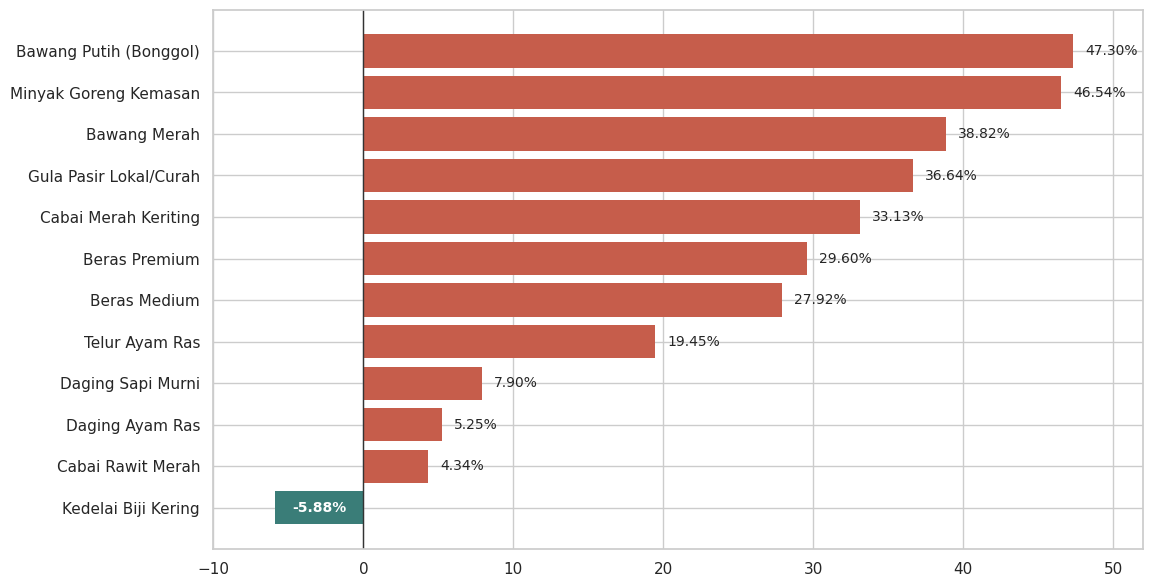

In [ ]:
# Sort commodities from the smallest to the largest price change
bq1_chart_data = (
    bq1_price_comparison
    .sort_values("price_change_pct")
    .reset_index(drop=True)
)

# Use different colors for increases and decreases
bar_colors = [
    "#C65D4B" if value >= 0 else "#3A7D78"
    for value in bq1_chart_data["price_change_pct"]
]

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    bq1_chart_data["commodity"],
    bq1_chart_data["price_change_pct"],
    color=bar_colors,
    edgecolor="none"
)

# Zero reference line
ax.axvline(
    x=0,
    color="#333333",
    linewidth=1
)

ax.set_xlim(-10, 52)

# Add percentage labels
for bar, value in zip(
    bars,
    bq1_chart_data["price_change_pct"]
):
    y_position = bar.get_y() + bar.get_height() / 2

    if value >= 0:
        ax.text(
            value + 0.8,
            y_position,
            f"{value:.2f}%",
            va="center",
            ha="left",
            fontsize=10
        )
    else:
        ax.text(
            value / 2,
            y_position,
            f"{value:.2f}%",
            va="center",
            ha="center",
            fontsize=10,
            color="white",
            fontweight="bold"
        )

### Key Findings

Between 2021 and 2025, annual median prices increased for 11 of the 12 commodities analyzed. The largest increases were recorded for Bawang Putih (Bonggol), Minyak Goreng Kemasan, and Bawang Merah, with increases of 47.30%, 46.54%, and 38.82%, respectively.

Substantial increases were also observed for Gula Pasir Lokal/Curah, Cabai Merah Keriting, Beras Premium, and Beras Medium. In contrast, Kedelai Biji Kering was the only commodity with a lower annual median price in 2025, declining by 5.88% compared with 2021.

Overall, the results indicate broad upward food-price pressure during the five-year period. However, the magnitude of the increase varied considerably across commodities, showing that long-term price movements were not uniform. This comparison describes changes in price levels but does not yet reveal when the increases occurred or whether they developed gradually or through temporary spikes.

### Monthly Indexed Price Trends

The annual comparison shows the overall change between 2021 and 2025 but does not reveal when price movements occurred. Therefore, monthly median prices are converted into an index with January 2021 set to 100 for each commodity.

An index value of 130 means that the monthly median price was 30% higher than its January 2021 level. This normalization allows commodities with different nominal price levels to be compared on the same scale. The index is descriptive and does not represent an official national food-price index.

In [ ]:
con.sql("""
    CREATE OR REPLACE TABLE bq1_monthly_price_index AS

    WITH monthly_prices AS (
        SELECT
            commodity,
            price_date,
            MEDIAN(price) AS monthly_median_price,
            COUNT(price) AS observed_provinces

        FROM longitudinal_price_changes

        WHERE price IS NOT NULL
          AND eligible_for_series_analysis = TRUE

        GROUP BY
            commodity,
            price_date
    ),

    base_prices AS (
        SELECT
            commodity,
            monthly_median_price AS january_2021_price

        FROM monthly_prices

        WHERE price_date = DATE '2021-01-01'
    )

    SELECT
        monthly.commodity,
        monthly.price_date,
        ROUND(monthly.monthly_median_price, 2)
            AS monthly_median_price,

        monthly.observed_provinces,

        ROUND(base.january_2021_price, 2)
            AS january_2021_price,

        ROUND(
            (
                monthly.monthly_median_price
                / NULLIF(base.january_2021_price, 0)
            ) * 100,
            2
        ) AS price_index

    FROM monthly_prices AS monthly

    INNER JOIN base_prices AS base
        ON monthly.commodity = base.commodity

    ORDER BY
        monthly.commodity,
        monthly.price_date
""")

In [ ]:
bq1_monthly_validation = con.sql("""
    SELECT
        commodity,
        COUNT(*) AS total_months,

        MAX(
            CASE
                WHEN price_date = DATE '2021-01-01'
                THEN price_index
            END
        ) AS january_2021_index,

        ROUND(MIN(price_index), 2) AS minimum_index,
        ROUND(MAX(price_index), 2) AS maximum_index,

        MAX(
            CASE
                WHEN price_date = DATE '2025-12-01'
                THEN price_index
            END
        ) AS december_2025_index

    FROM bq1_monthly_price_index

    GROUP BY commodity

    ORDER BY december_2025_index DESC
""").df()

bq1_monthly_validation

,commodity,total_months,january_2021_index,minimum_index,maximum_index,december_2025_index
0,Minyak Goreng Kemasan,60,100.00,99.36,194.59,164.38
1,Bawang Merah,60,100.00,78.27,193.87,155.32
2,Bawang Putih (Bonggol),60,100.00,92.53,170.31,139.47
3,Gula Pasir Lokal/Curah,60,100.00,98.34,137.53,133.66
4,Beras Premium,60,100.00,97.05,135.22,126.95
5,Beras Medium,60,100.00,94.61,132.92,123.28
6,Telur Ayam Ras,60,100.00,89.27,123.73,120.58
7,Daging Ayam Ras,60,100.00,96.60,115.50,115.50
8,Cabai Merah Keriting,60,100.00,54.94,154.90,112.12
9,Daging Sapi Murni,60,100.00,100.00,113.71,110.78


### Monthly Price-Index Paths

The monthly price index illustrates how each commodity moved throughout the five-year period. Separate panels are used to preserve readability, while a common index scale allows the magnitude and timing of price movements to be compared across commodities.

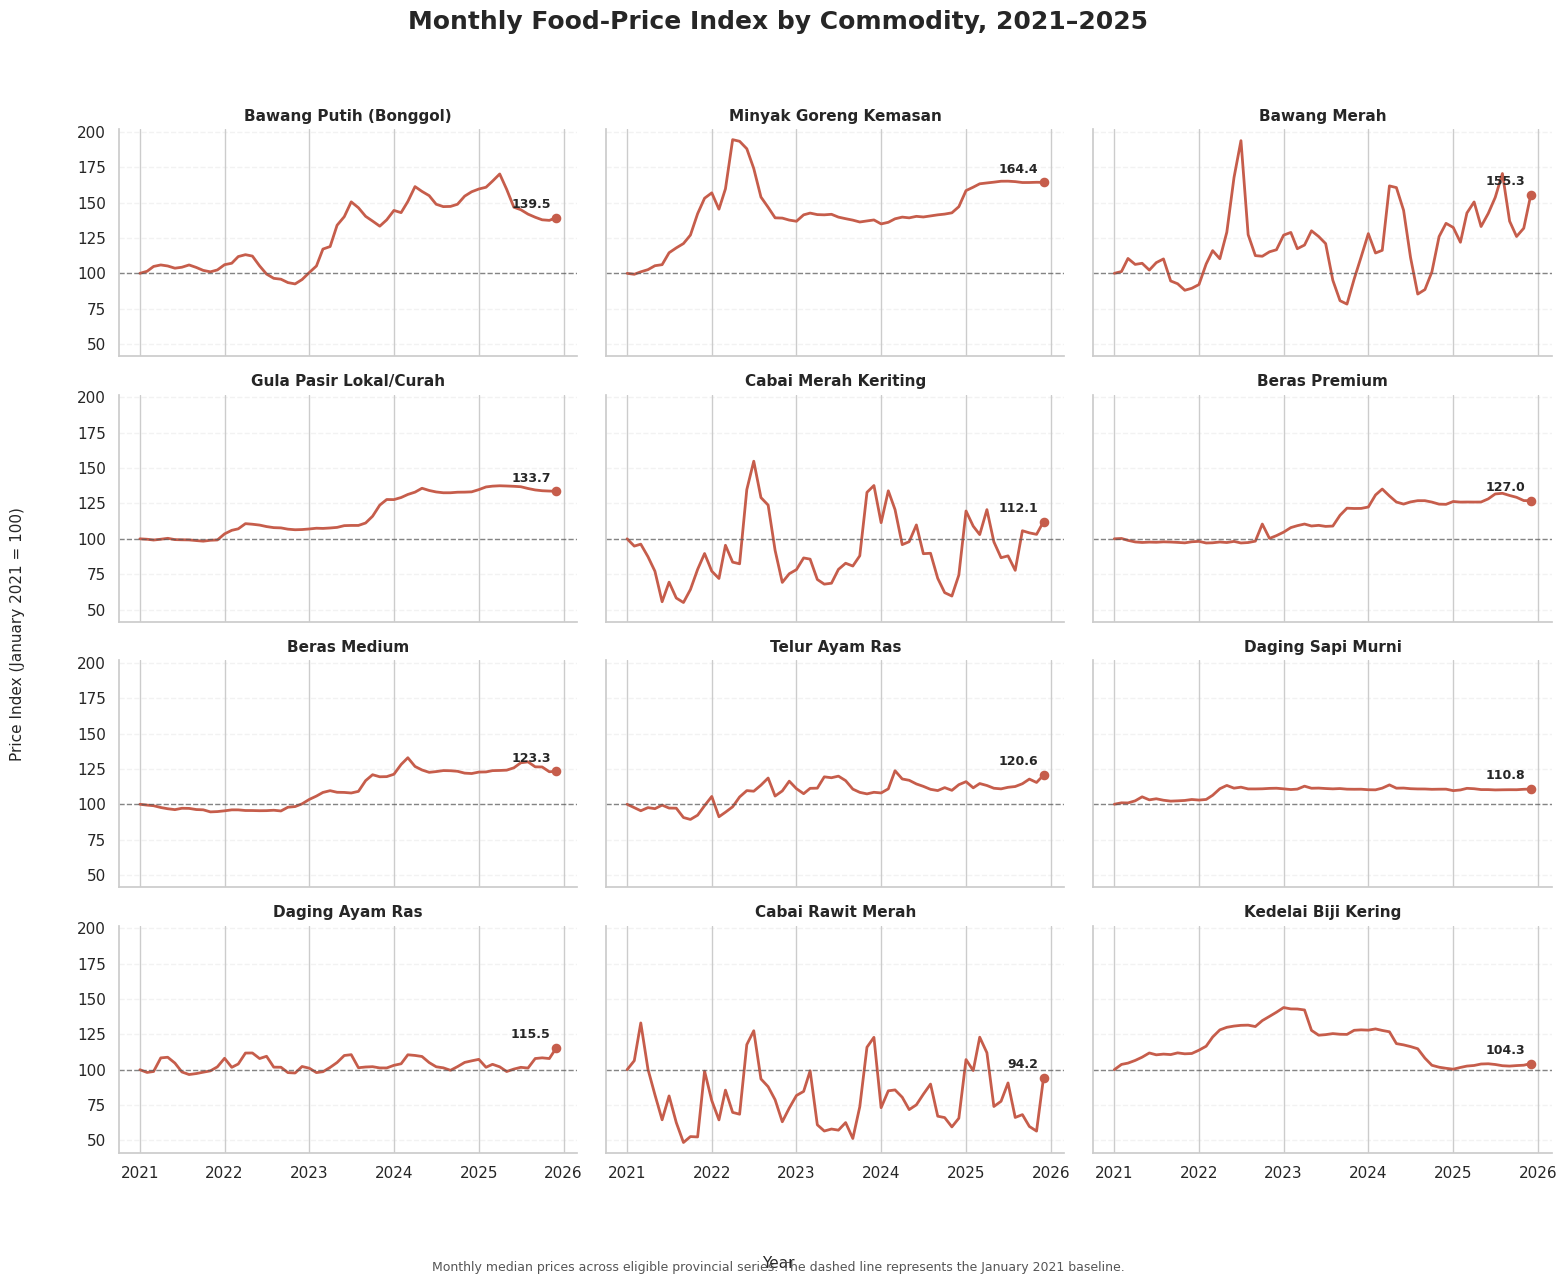

In [ ]:
import matplotlib.dates as mdates

# Retrieve monthly index data from DuckDB
bq1_monthly_trend = con.sql("""
    SELECT
        commodity,
        price_date,
        price_index
    FROM bq1_monthly_price_index
    ORDER BY
        commodity,
        price_date
""").df()

bq1_monthly_trend["price_date"] = pd.to_datetime(
    bq1_monthly_trend["price_date"]
)

# Arrange commodities based on the long-term price-change ranking
commodity_order = (
    bq1_price_comparison
    .sort_values("price_change_pct", ascending=False)
    ["commodity"]
    .tolist()
)

fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(16, 13),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, commodity in zip(axes, commodity_order):
    commodity_data = bq1_monthly_trend[
        bq1_monthly_trend["commodity"] == commodity
    ]

    ax.plot(
        commodity_data["price_date"],
        commodity_data["price_index"],
        color="#C65D4B",
        linewidth=2
    )

    # January 2021 reference level
    ax.axhline(
        y=100,
        color="#555555",
        linestyle="--",
        linewidth=1,
        alpha=0.7
    )

    # Mark the final observation
    final_row = commodity_data.iloc[-1]

    ax.scatter(
        final_row["price_date"],
        final_row["price_index"],
        color="#C65D4B",
        s=35,
        zorder=3
    )

    ax.annotate(
        f'{final_row["price_index"]:.1f}',
        xy=(
            final_row["price_date"],
            final_row["price_index"]
        ),
        xytext=(-4, 7),
        textcoords="offset points",
        ha="right",
        fontsize=9,
        fontweight="bold"
    )

    ax.set_title(
        commodity,
        fontsize=11,
        fontweight="bold"
    )

    ax.xaxis.set_major_locator(
        mdates.YearLocator()
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%Y")
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Monthly Food-Price Index by Commodity, 2021–2025",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

fig.supxlabel(
    "Year",
    fontsize=11
)

fig.supylabel(
    "Price Index (January 2021 = 100)",
    fontsize=11
)

plt.figtext(
    0.5,
    0.01,
    "Monthly median prices across eligible provincial series. "
    "The dashed line represents the January 2021 baseline.",
    ha="center",
    fontsize=9,
    color="#555555"
)

plt.tight_layout(
    rect=[0.03, 0.04, 1, 0.95]
)

plt.show()

### **Business Question 1 Conclusion**

Food-price movements between 2021 and 2025 were predominantly upward, but their trajectories differed substantially across commodities.

Bawang Putih (Bonggol) and Minyak Goreng Kemasan recorded some of the largest long-term increases. Minyak Goreng Kemasan rose sharply during 2021–2022, declined from its peak, and subsequently remained considerably above its January 2021 level. Bawang Putih (Bonggol) experienced a more pronounced upward shift beginning in 2023 and also remained elevated through 2025.

Beras Medium, Beras Premium, and Gula Pasir Lokal/Curah displayed comparatively gradual increases, indicating a sustained shift in their price levels rather than repeated short-lived spikes. Daging Sapi Murni remained relatively stable, while Telur Ayam Ras and Daging Ayam Ras experienced moderate increases.

In contrast, Bawang Merah, Cabai Merah Keriting, and Cabai Rawit Merah showed frequent peaks and reversals. Their monthly paths demonstrate that a commodity can experience substantial temporary pressure even when its final index is relatively close to the initial baseline. Kedelai Biji Kering increased through 2023 before declining toward its January 2021 level.

Overall, 11 of the 12 commodities recorded higher annual median prices in 2025 than in 2021. However, the monthly analysis shows that these increases consisted of different combinations of gradual price growth, sustained level shifts, and temporary price spikes. These differences motivate the subsequent analysis of long-term volatility.

# Business Question 2: Which Commodities Experienced the Greatest Long-Term Price Increases and Volatility?

### Commodity-Level Volatility Measurement

Long-term price growth and price volatility represent different forms of price pressure. A commodity may experience a substantial long-term increase while remaining relatively stable, whereas another commodity may end near its initial price level after experiencing repeated monthly spikes and declines.

Commodity volatility is measured using the standard deviation of valid province-level month-to-month percentage changes. A higher standard deviation indicates greater instability in monthly price movements.

The median absolute monthly change and the 90th percentile of absolute monthly changes are also calculated. These supplementary measures describe typical price movement and the magnitude of relatively extreme movements without relying only on the standard deviation.

In [ ]:
bq2_commodity_volatility = con.sql("""
    WITH annual_prices AS (
        SELECT
            commodity,
            year,
            MEDIAN(price) AS annual_median_price

        FROM longitudinal_price_changes

        WHERE year IN (2021, 2025)
          AND price IS NOT NULL
          AND eligible_for_series_analysis = TRUE

        GROUP BY
            commodity,
            year
    ),

    long_term_change AS (
        SELECT
            commodity,

            MAX(
                CASE WHEN year = 2021
                THEN annual_median_price END
            ) AS median_price_2021,

            MAX(
                CASE WHEN year = 2025
                THEN annual_median_price END
            ) AS median_price_2025

        FROM annual_prices

        GROUP BY commodity
    ),

    volatility_metrics AS (
        SELECT
            commodity,

            COUNT(mom_change_pct)
                AS valid_mom_observations,

            STDDEV_SAMP(mom_change_pct)
                AS mom_volatility_pct,

            MEDIAN(ABS(mom_change_pct))
                AS median_absolute_mom_change_pct,

            QUANTILE_CONT(
                ABS(mom_change_pct),
                0.90
            ) AS p90_absolute_mom_change_pct

        FROM longitudinal_price_changes

        WHERE mom_change_pct IS NOT NULL
          AND eligible_for_series_analysis = TRUE

        GROUP BY commodity
    ),

    combined_metrics AS (
        SELECT
            long_term.commodity,

            (
                (
                    long_term.median_price_2025
                    - long_term.median_price_2021
                )
                / NULLIF(
                    long_term.median_price_2021,
                    0
                )
            ) * 100 AS long_term_change_pct,

            volatility.valid_mom_observations,
            volatility.mom_volatility_pct,
            volatility.median_absolute_mom_change_pct,
            volatility.p90_absolute_mom_change_pct

        FROM long_term_change AS long_term

        INNER JOIN volatility_metrics AS volatility
            ON long_term.commodity = volatility.commodity
    )

    SELECT
        commodity,

        ROUND(long_term_change_pct, 2)
            AS long_term_change_pct,

        ROUND(mom_volatility_pct, 2)
            AS mom_volatility_pct,

        ROUND(median_absolute_mom_change_pct, 2)
            AS median_absolute_mom_change_pct,

        ROUND(p90_absolute_mom_change_pct, 2)
            AS p90_absolute_mom_change_pct,

        valid_mom_observations,

        DENSE_RANK() OVER (
            ORDER BY mom_volatility_pct DESC
        ) AS volatility_rank,

        DENSE_RANK() OVER (
            ORDER BY long_term_change_pct DESC
        ) AS long_term_increase_rank

    FROM combined_metrics

    ORDER BY volatility_rank
""").df()

bq2_commodity_volatility

,commodity,long_term_change_pct,mom_volatility_pct,median_absolute_mom_change_pct,p90_absolute_mom_change_pct,valid_mom_observations,volatility_rank,long_term_increase_rank
0,Cabai Rawit Merah,4.34,33.63,15.24,46.61,1818,1,11
1,Cabai Merah Keriting,33.13,23.80,12.32,34.33,1884,2,5
2,Bawang Merah,38.82,15.11,8.43,25.34,1886,3,3
3,Minyak Goreng Kemasan,46.54,5.49,1.32,8.52,1882,4,2
4,Daging Ayam Ras,5.25,4.92,2.57,8.10,1886,5,10
5,Telur Ayam Ras,19.45,4.75,2.30,7.98,1886,6,8
6,Bawang Putih (Bonggol),47.30,4.53,2.47,7.48,1886,7,1
7,Kedelai Biji Kering,-5.88,3.39,1.12,4.72,1826,8,12
8,Beras Premium,29.60,2.72,0.63,3.72,1885,9,6
9,Beras Medium,27.92,2.23,0.74,3.34,1886,10,7


### Long-Term Price Increase and Monthly Volatility

A scatter plot is used to examine whether commodities with large long-term price increases also experienced high monthly volatility. The horizontal and vertical reference lines represent the median long-term increase and median volatility across the 12 commodities.

The resulting quadrants describe the relative position of each commodity within this dataset. They are descriptive categories and not official monitoring classifications.

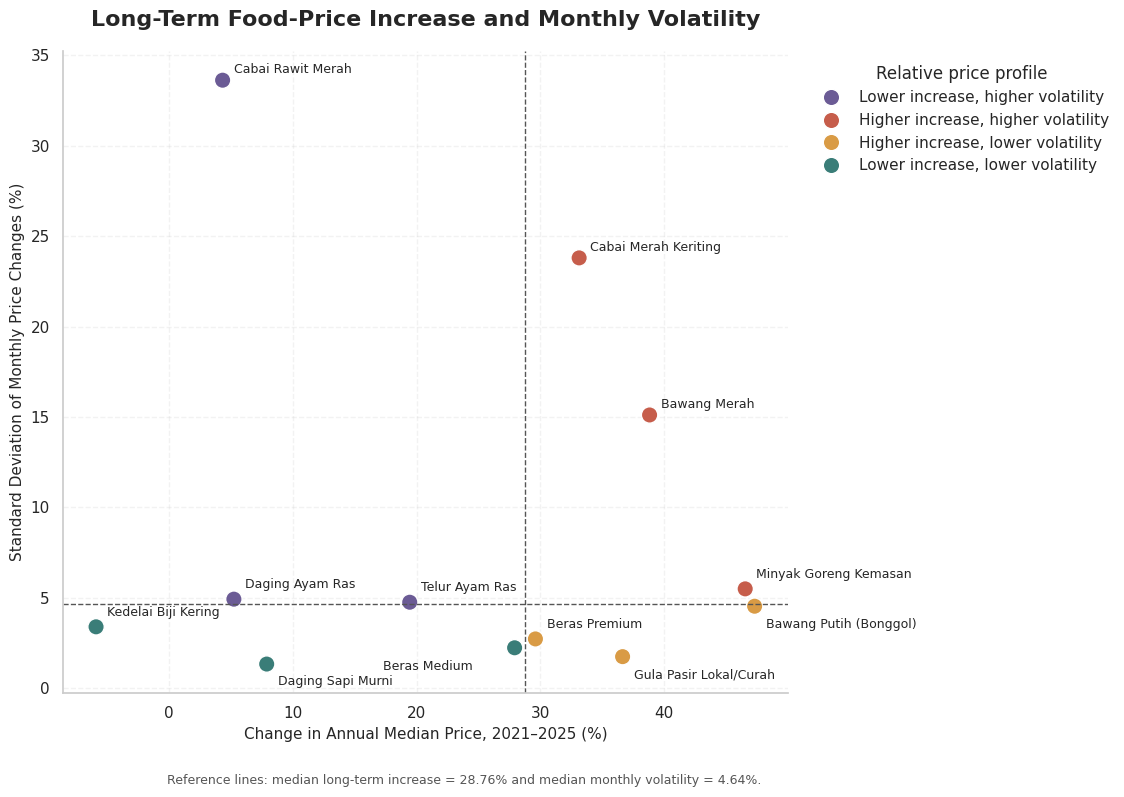

In [ ]:
# Prepare scatter-plot data
bq2_plot_data = bq2_commodity_volatility.copy()

increase_threshold = (
    bq2_plot_data["long_term_change_pct"].median()
)

volatility_threshold = (
    bq2_plot_data["mom_volatility_pct"].median()
)

# Assign a relative commodity profile
def assign_price_profile(row):
    high_increase = (
        row["long_term_change_pct"] >= increase_threshold
    )
    high_volatility = (
        row["mom_volatility_pct"] >= volatility_threshold
    )

    if high_increase and high_volatility:
        return "Higher increase, higher volatility"
    elif high_increase and not high_volatility:
        return "Higher increase, lower volatility"
    elif not high_increase and high_volatility:
        return "Lower increase, higher volatility"
    else:
        return "Lower increase, lower volatility"


bq2_plot_data["price_profile"] = (
    bq2_plot_data.apply(
        assign_price_profile,
        axis=1
    )
)

profile_colors = {
    "Higher increase, higher volatility": "#C65D4B",
    "Higher increase, lower volatility": "#D99B45",
    "Lower increase, higher volatility": "#6B5B95",
    "Lower increase, lower volatility": "#3A7D78"
}

fig, ax = plt.subplots(figsize=(14, 8))

sns.scatterplot(
    data=bq2_plot_data,
    x="long_term_change_pct",
    y="mom_volatility_pct",
    hue="price_profile",
    palette=profile_colors,
    s=140,
    edgecolor="white",
    linewidth=1,
    ax=ax
)

# Median reference lines
ax.axvline(
    increase_threshold,
    color="#555555",
    linestyle="--",
    linewidth=1
)

ax.axhline(
    volatility_threshold,
    color="#555555",
    linestyle="--",
    linewidth=1
)

# Custom label offsets to reduce overlap
label_offsets = {
    "Beras Medium": (-95, -16),
    "Beras Premium": (8, 8),
    "Gula Pasir Lokal/Curah": (8, -16),
    "Bawang Putih (Bonggol)": (8, -16),
    "Minyak Goreng Kemasan": (8, 8),
    "Daging Sapi Murni": (8, -15),
    "Daging Ayam Ras": (8, 8),
    "Telur Ayam Ras": (8, 8),
    "Kedelai Biji Kering": (8, 8),
    "Cabai Rawit Merah": (8, 5),
    "Cabai Merah Keriting": (8, 5),
    "Bawang Merah": (8, 5)
}

for _, row in bq2_plot_data.iterrows():
    offset = label_offsets.get(
        row["commodity"],
        (8, 6)
    )

    ax.annotate(
        row["commodity"],
        (
            row["long_term_change_pct"],
            row["mom_volatility_pct"]
        ),
        xytext=offset,
        textcoords="offset points",
        fontsize=9
    )

ax.set_title(
    "Long-Term Food-Price Increase and Monthly Volatility",
    fontsize=16,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "Change in Annual Median Price, 2021–2025 (%)",
    fontsize=11
)

ax.set_ylabel(
    "Standard Deviation of Monthly Price Changes (%)",
    fontsize=11
)

ax.grid(
    linestyle="--",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    title="Relative price profile",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.figtext(
    0.125,
    0.01,
    (
        f"Reference lines: median long-term increase = "
        f"{increase_threshold:.2f}% and median monthly volatility = "
        f"{volatility_threshold:.2f}%."
    ),
    fontsize=9,
    color="#555555"
)

plt.tight_layout(rect=[0, 0.04, 0.82, 1])
plt.show()

### **Business Question 2 Conclusion**

The commodities with the largest long-term price increases were Bawang Putih (Bonggol), Minyak Goreng Kemasan, and Bawang Merah, which recorded increases of 47.30%, 46.54%, and 38.82%, respectively.

However, the volatility ranking produced a different pattern. Cabai Rawit Merah was the most volatile commodity, with a monthly-change standard deviation of 33.63%, followed by Cabai Merah Keriting at 23.80% and Bawang Merah at 15.11%. Their high median absolute changes and 90th-percentile values confirm that large monthly movements occurred repeatedly rather than being driven by only one observation.

Bawang Merah stands out because it ranked among the three highest commodities for both long-term price growth and monthly volatility. Cabai Merah Keriting also combined a substantial long-term increase with high instability. These commodities experienced both elevated price levels and repeated monthly fluctuations.

In contrast, Cabai Rawit Merah recorded the highest volatility but only a 4.34% increase in its annual median price. This indicates that its large price increases were frequently followed by declines, leaving a relatively small net long-term change.

Bawang Putih (Bonggol), Gula Pasir Lokal/Curah, and Beras Premium recorded relatively high long-term increases with lower volatility. Their price pressure was therefore characterized more by sustained increases than repeated extreme monthly movements.

Overall, long-term price growth and volatility represent distinct monitoring dimensions. Commodities with the greatest cumulative increases were not always the most unstable, while highly volatile commodities did not necessarily maintain higher prices over the complete period.

# Business Question 3: Which Price Spikes Were Isolated Local Events, and Which Developed into Geographically Widespread Shocks?

### Data-Driven Price-Spike Identification

A price spike is defined as a positive month-to-month price change that equals or exceeds the commodity-specific 90th percentile of historical monthly changes.

Commodity-specific thresholds are used because commodities have different levels of normal price variation. A monthly increase that is unusual for rice may still be relatively common for chili.

After identifying province-level spikes, shock breadth is calculated as the percentage of provinces experiencing a spike in the same commodity and month. The boundary between localized and widespread events will be determined after examining the empirical distribution of shock breadth.

In [ ]:
# Create commodity-specific spike thresholds
con.sql("""
    CREATE OR REPLACE TABLE bq3_commodity_spike_thresholds AS

    SELECT
        commodity,

        QUANTILE_CONT(
            mom_change_pct,
            0.90
        ) AS spike_threshold_pct,

        COUNT(mom_change_pct)
            AS valid_mom_observations

    FROM longitudinal_price_changes

    WHERE mom_change_pct IS NOT NULL
      AND eligible_for_series_analysis = TRUE

    GROUP BY commodity
""")


# Calculate the monthly geographical breadth of price spikes
con.sql("""
    CREATE OR REPLACE TABLE bq3_monthly_shock_breadth AS

    WITH province_spike_flags AS (
        SELECT
            prices.province_code,
            prices.province_name,
            prices.commodity,
            prices.price_date,
            prices.year,
            prices.month_number,
            prices.mom_change_pct,
            thresholds.spike_threshold_pct,

            CASE
                WHEN prices.mom_change_pct > 0
                 AND prices.mom_change_pct
                     >= thresholds.spike_threshold_pct
                THEN 1
                ELSE 0
            END AS is_price_spike

        FROM longitudinal_price_changes AS prices

        INNER JOIN bq3_commodity_spike_thresholds
            AS thresholds
            ON prices.commodity = thresholds.commodity

        WHERE prices.mom_change_pct IS NOT NULL
          AND prices.eligible_for_series_analysis = TRUE
    )

    SELECT
        commodity,
        price_date,
        year,
        month_number,

        MAX(spike_threshold_pct)
            AS spike_threshold_pct,

        COUNT(DISTINCT province_code)
            AS valid_mom_provinces,

        CAST(
            SUM(is_price_spike) AS INTEGER
        ) AS spike_provinces,

        ROUND(
            (
                SUM(is_price_spike) * 100.0
                / NULLIF(
                    COUNT(DISTINCT province_code),
                    0
                )
            ),
            2
        ) AS shock_breadth_pct,

        ROUND(
            MEDIAN(
                CASE
                    WHEN is_price_spike = 1
                    THEN mom_change_pct
                END
            ),
            2
        ) AS median_spike_intensity_pct,

        ROUND(
            MAX(
                CASE
                    WHEN is_price_spike = 1
                    THEN mom_change_pct
                END
            ),
            2
        ) AS maximum_spike_intensity_pct

    FROM province_spike_flags

    GROUP BY
        commodity,
        price_date,
        year,
        month_number

    ORDER BY
        commodity,
        price_date
""")

In [ ]:
bq3_threshold_validation = con.sql("""
    SELECT
        thresholds.commodity,

        ROUND(
            thresholds.spike_threshold_pct,
            2
        ) AS spike_threshold_pct,

        thresholds.valid_mom_observations,

        COUNT(monthly.price_date)
            AS observed_months,

        SUM(
            CASE
                WHEN monthly.spike_provinces > 0
                THEN 1
                ELSE 0
            END
        ) AS months_with_spikes,

        MAX(monthly.spike_provinces)
            AS maximum_spike_provinces,

        MAX(monthly.shock_breadth_pct)
            AS maximum_shock_breadth_pct

    FROM bq3_commodity_spike_thresholds AS thresholds

    LEFT JOIN bq3_monthly_shock_breadth AS monthly
        ON thresholds.commodity = monthly.commodity

    GROUP BY
        thresholds.commodity,
        thresholds.spike_threshold_pct,
        thresholds.valid_mom_observations

    ORDER BY
        spike_threshold_pct DESC
""").df()

bq3_threshold_validation

,commodity,spike_threshold_pct,valid_mom_observations,observed_months,months_with_spikes,maximum_spike_provinces,maximum_shock_breadth_pct
0,Cabai Rawit Merah,41.46,1818,59,24.00,26,83.87
1,Cabai Merah Keriting,32.10,1884,59,27.00,23,71.88
2,Bawang Merah,21.21,1886,59,25.00,26,81.25
3,Telur Ayam Ras,6.40,1886,59,23.00,24,75.00
4,Daging Ayam Ras,6.14,1886,59,35.00,18,56.25
5,Bawang Putih (Bonggol),6.12,1886,59,26.00,29,90.63
6,Minyak Goreng Kemasan,6.05,1882,59,14.00,32,100.00
7,Kedelai Biji Kering,3.18,1826,59,38.00,26,83.87
8,Beras Premium,2.70,1885,59,26.00,30,93.75
9,Beras Medium,2.52,1886,59,32.00,27,84.38


### Empirical Distribution of Shock Breadth

Only commodity–month observations containing at least one provincial price spike are treated as spike events. The distribution of shock breadth is examined to determine how provincial spikes were geographically concentrated.

This step prevents the boundary between localized and widespread shocks from being selected without reference to the observed data.

In [ ]:
bq3_breadth_distribution = con.sql("""
    WITH spike_events AS (
        SELECT
            commodity,
            price_date,
            spike_provinces,
            valid_mom_provinces,
            shock_breadth_pct

        FROM bq3_monthly_shock_breadth

        WHERE spike_provinces > 0
    )

    SELECT
        COUNT(*) AS total_spike_events,

        ROUND(
            MIN(shock_breadth_pct),
            2
        ) AS minimum_breadth_pct,

        ROUND(
            QUANTILE_CONT(
                shock_breadth_pct,
                0.25
            ),
            2
        ) AS p25_breadth_pct,

        ROUND(
            MEDIAN(shock_breadth_pct),
            2
        ) AS median_breadth_pct,

        ROUND(
            QUANTILE_CONT(
                shock_breadth_pct,
                0.75
            ),
            2
        ) AS p75_breadth_pct,

        ROUND(
            QUANTILE_CONT(
                shock_breadth_pct,
                0.90
            ),
            2
        ) AS p90_breadth_pct,

        ROUND(
            MAX(shock_breadth_pct),
            2
        ) AS maximum_breadth_pct,

        ROUND(
            AVG(shock_breadth_pct),
            2
        ) AS average_breadth_pct

    FROM spike_events
""").df()

bq3_breadth_distribution

,total_spike_events,minimum_breadth_pct,p25_breadth_pct,median_breadth_pct,p75_breadth_pct,p90_breadth_pct,maximum_breadth_pct,average_breadth_pct
0,332,3.13,3.23,9.53,29.59,56.25,100.00,21.42


### Empirical Shock-Breadth Classification

The distribution contains 332 commodity–month spike events. Half of the events affected no more than approximately 9.53% of valid provinces, while the upper quartile began at approximately 29.59%.

Based on this empirical distribution, events are classified as follows:

- **Isolated spike:** exactly one province experienced a spike.
- **Localized shock:** more than one province was affected, but breadth did not exceed the median.
- **Regional shock:** breadth was above the median but below the 75th percentile.
- **Widespread shock:** breadth was equal to or above the 75th percentile.

These boundaries describe the relative geographical scale of events in this dataset and are not official government thresholds.

In [ ]:
con.sql("""
    CREATE OR REPLACE TABLE bq3_classified_shocks AS

    WITH empirical_boundaries AS (
        SELECT
            MEDIAN(shock_breadth_pct)
                AS median_breadth_threshold,

            QUANTILE_CONT(
                shock_breadth_pct,
                0.75
            ) AS p75_breadth_threshold

        FROM bq3_monthly_shock_breadth

        WHERE spike_provinces > 0
    )

    SELECT
        monthly.*,
        boundaries.median_breadth_threshold,
        boundaries.p75_breadth_threshold,

        CASE
            WHEN monthly.spike_provinces = 0
                THEN 'No spike'

            WHEN monthly.spike_provinces = 1
                THEN 'Isolated spike'

            WHEN monthly.shock_breadth_pct
                 <= boundaries.median_breadth_threshold
                THEN 'Localized shock'

            WHEN monthly.shock_breadth_pct
                 < boundaries.p75_breadth_threshold
                THEN 'Regional shock'

            ELSE 'Widespread shock'
        END AS shock_classification

    FROM bq3_monthly_shock_breadth AS monthly

    CROSS JOIN empirical_boundaries AS boundaries
""")

In [ ]:
bq3_classification_summary = con.sql("""
    SELECT
        shock_classification,

        COUNT(*) AS total_events,

        ROUND(
            COUNT(*) * 100.0
            / SUM(COUNT(*)) OVER (),
            2
        ) AS share_of_spike_events_pct,

        ROUND(
            MEDIAN(shock_breadth_pct),
            2
        ) AS median_breadth_pct,

        ROUND(
            MAX(shock_breadth_pct),
            2
        ) AS maximum_breadth_pct,

        ROUND(
            MEDIAN(median_spike_intensity_pct),
            2
        ) AS median_intensity_pct

    FROM bq3_classified_shocks

    WHERE spike_provinces > 0

    GROUP BY shock_classification

    ORDER BY
        CASE shock_classification
            WHEN 'Isolated spike' THEN 1
            WHEN 'Localized shock' THEN 2
            WHEN 'Regional shock' THEN 3
            WHEN 'Widespread shock' THEN 4
        END
""").df()

bq3_classification_summary

,shock_classification,total_events,share_of_spike_events_pct,median_breadth_pct,maximum_breadth_pct,median_intensity_pct
0,Isolated spike,98,29.52,3.13,3.33,6.40
1,Localized shock,68,20.48,6.45,9.38,5.22
2,Regional shock,83,25.00,18.75,29.03,7.47
3,Widespread shock,83,25.00,53.13,100.00,8.79


### Identifying the Largest Widespread and Isolated Events

Widespread shocks are ranked primarily by geographical breadth and then by median spike intensity. Isolated spikes are ranked by their province-level price-change intensity.

This comparison identifies events that affected many provinces simultaneously as well as extreme increases that remained confined to only one province.

In [ ]:
# Largest widespread shocks
bq3_top_widespread = con.sql("""
    SELECT
        price_date,
        commodity,
        spike_provinces,
        valid_mom_provinces,
        shock_breadth_pct,
        median_spike_intensity_pct,
        maximum_spike_intensity_pct,
        ROUND(
            spike_threshold_pct,
            2
        ) AS spike_threshold_pct

    FROM bq3_classified_shocks

    WHERE shock_classification = 'Widespread shock'

    ORDER BY
        shock_breadth_pct DESC,
        median_spike_intensity_pct DESC

    LIMIT 10
""").df()


# Most intense isolated spikes and their provinces
bq3_top_isolated = con.sql("""
    SELECT
        classified.price_date,
        classified.commodity,
        prices.province_name,
        ROUND(
            prices.mom_change_pct,
            2
        ) AS spike_intensity_pct,

        ROUND(
            classified.spike_threshold_pct,
            2
        ) AS spike_threshold_pct,

        classified.shock_breadth_pct

    FROM bq3_classified_shocks AS classified

    INNER JOIN longitudinal_price_changes AS prices
        ON classified.commodity = prices.commodity
       AND classified.price_date = prices.price_date

    WHERE classified.shock_classification
          = 'Isolated spike'

      AND prices.eligible_for_series_analysis = TRUE
      AND prices.mom_change_pct IS NOT NULL
      AND prices.mom_change_pct > 0
      AND prices.mom_change_pct
          >= classified.spike_threshold_pct

    ORDER BY
        prices.mom_change_pct DESC

    LIMIT 10
""").df()


print("Top 10 Widespread Shocks")
display(bq3_top_widespread)

print("\nTop 10 Most Intense Isolated Spikes")
display(bq3_top_isolated)

Top 10 Widespread Shocks


,price_date,commodity,spike_provinces,valid_mom_provinces,shock_breadth_pct,median_spike_intensity_pct,maximum_spike_intensity_pct,spike_threshold_pct
0,2022-04-01,Minyak Goreng Kemasan,32,32,100.00,20.23,45.44,6.05
1,2023-11-01,Gula Pasir Lokal/Curah,32,32,100.00,6.99,10.55,2.36
2,2021-07-01,Minyak Goreng Kemasan,31,32,96.88,8.84,12.78,6.05
3,2022-10-01,Beras Premium,30,32,93.75,10.76,20.24,2.70
4,2021-11-01,Minyak Goreng Kemasan,29,32,90.63,12.05,19.37,6.05
5,2023-03-01,Bawang Putih (Bonggol),29,32,90.63,9.83,16.43,6.12
6,2023-12-01,Gula Pasir Lokal/Curah,29,32,90.63,4.19,6.72,2.36
7,2022-04-01,Daging Sapi Murni,28,32,87.50,3.52,10.61,1.64
8,2023-09-01,Beras Medium,27,32,84.38,7.19,12.76,2.52
9,2023-09-01,Beras Premium,27,32,84.38,6.19,12.74,2.70



Top 10 Most Intense Isolated Spikes


,price_date,commodity,province_name,spike_intensity_pct,spike_threshold_pct,shock_breadth_pct
0,2021-03-01,Cabai Rawit Merah,Nusa Tenggara Barat,78.08,41.46,3.33
1,2023-01-01,Cabai Rawit Merah,Nusa Tenggara Barat,75.77,41.46,3.23
2,2022-07-01,Cabai Merah Keriting,DI Yogyakarta,68.33,32.10,3.13
3,2021-02-01,Cabai Merah Keriting,Bali,56.30,32.10,3.13
4,2024-02-01,Cabai Rawit Merah,Kalimantan Barat,50.27,41.46,3.23
5,2022-04-01,Cabai Rawit Merah,Sumatera Barat,46.36,41.46,3.23
6,2022-02-01,Cabai Merah Keriting,Aceh,46.19,32.10,3.13
7,2021-10-01,Cabai Rawit Merah,DI Yogyakarta,45.24,41.46,3.33
8,2022-07-01,Cabai Rawit Merah,DI Yogyakarta,45.15,41.46,3.23
9,2024-12-01,Cabai Rawit Merah,DI Yogyakarta,43.41,41.46,3.23


### Distribution of Shock Types by Commodity

The number of isolated, localized, regional, and widespread events is compared across commodities. This shows whether a commodity's historical price pressure tended to remain concentrated in a small number of provinces or occur simultaneously across a broader geographical area.

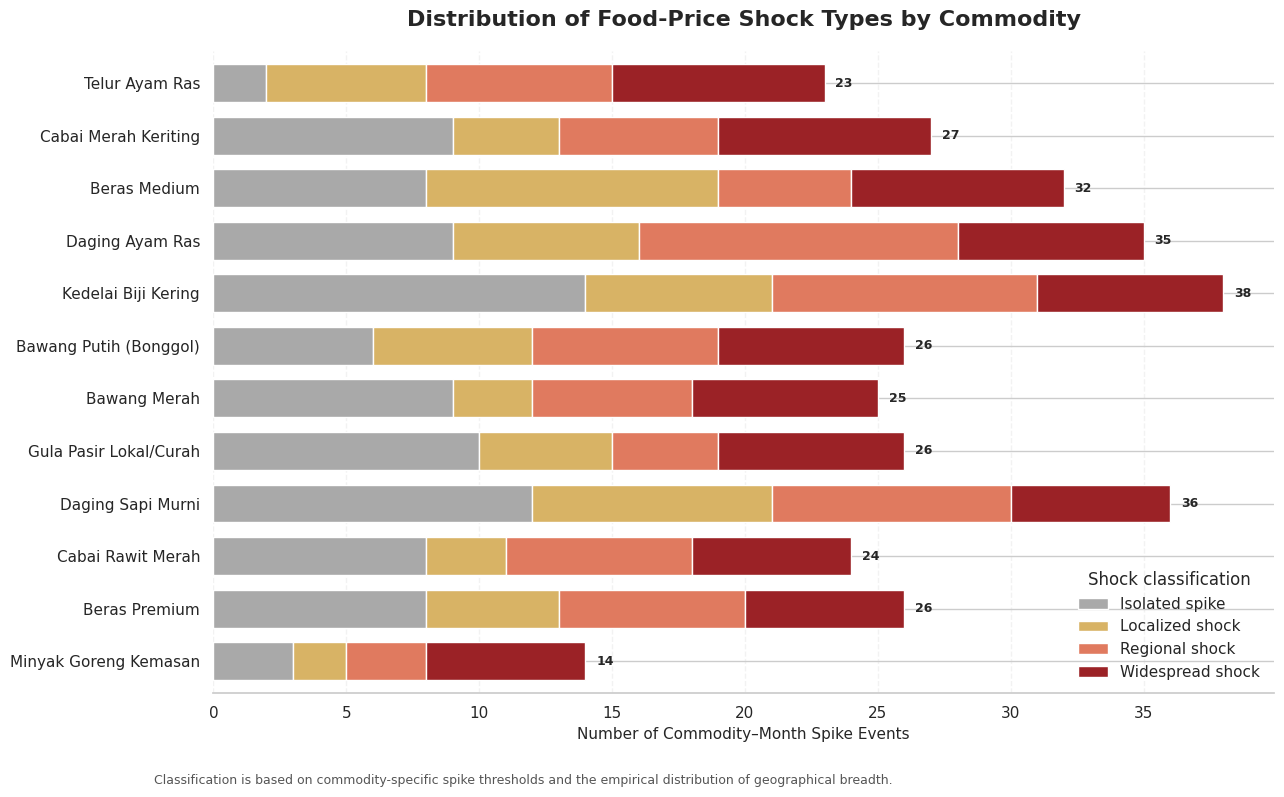

In [ ]:
bq3_commodity_shock_counts = con.sql("""
    SELECT
        commodity,

        SUM(
            CASE WHEN shock_classification = 'Isolated spike'
            THEN 1 ELSE 0 END
        ) AS isolated_spikes,

        SUM(
            CASE WHEN shock_classification = 'Localized shock'
            THEN 1 ELSE 0 END
        ) AS localized_shocks,

        SUM(
            CASE WHEN shock_classification = 'Regional shock'
            THEN 1 ELSE 0 END
        ) AS regional_shocks,

        SUM(
            CASE WHEN shock_classification = 'Widespread shock'
            THEN 1 ELSE 0 END
        ) AS widespread_shocks

    FROM bq3_classified_shocks

    WHERE spike_provinces > 0

    GROUP BY commodity

    ORDER BY
        widespread_shocks,
        regional_shocks
""").df()


# Prepare chart data
bq3_chart_data = (
    bq3_commodity_shock_counts
    .set_index("commodity")
)

columns_to_plot = [
    "isolated_spikes",
    "localized_shocks",
    "regional_shocks",
    "widespread_shocks"
]

shock_colors = [
    "#A9A9A9",
    "#D8B365",
    "#E07A5F",
    "#9B2226"
]

fig, ax = plt.subplots(figsize=(13, 8))

bq3_chart_data[columns_to_plot].plot(
    kind="barh",
    stacked=True,
    color=shock_colors,
    width=0.72,
    ax=ax
)

# Add total-event labels
event_totals = (
    bq3_chart_data[columns_to_plot]
    .sum(axis=1)
)

for position, total in enumerate(event_totals):
    ax.text(
        total + 0.4,
        position,
        f"{int(total)}",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

ax.set_title(
    "Distribution of Food-Price Shock Types by Commodity",
    fontsize=16,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "Number of Commodity–Month Spike Events",
    fontsize=11
)

ax.set_ylabel("")

ax.legend(
    labels=[
        "Isolated spike",
        "Localized shock",
        "Regional shock",
        "Widespread shock"
    ],
    title="Shock classification",
    loc="lower right",
    frameon=False
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.figtext(
    0.125,
    0.01,
    "Classification is based on commodity-specific spike thresholds "
    "and the empirical distribution of geographical breadth.",
    fontsize=9,
    color="#555555"
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

### **Business Question 3 Conclusion**

Of the 332 identified commodity–month spike events, 98 events (29.52%) occurred in only one province, while 68 events (20.48%) remained localized within a small number of provinces. Meanwhile, 83 events were classified as regional shocks and another 83 as widespread shocks.

The most geographically extensive event occurred for Minyak Goreng Kemasan in April 2022, when all 32 valid provinces exceeded the commodity-specific spike threshold. Its median provincial increase reached 20.23%, making it both geographically widespread and comparatively intense. Minyak Goreng Kemasan also experienced widespread events in July and November 2021, despite recording relatively few total spike months.

Gula Pasir Lokal/Curah affected all 32 provinces in November 2023 and remained widespread in December 2023. Beras Premium affected 30 provinces in October 2022, while Beras Medium and Beras Premium simultaneously affected 27 provinces in September 2023. Bawang Putih (Bonggol) also recorded a widespread event across 29 provinces in March 2023.

In contrast, the most intense isolated events were dominated by Cabai Rawit Merah and Cabai Merah Keriting. Examples included a 78.08% increase in Cabai Rawit Merah in Nusa Tenggara Barat in March 2021 and a 68.33% increase in Cabai Merah Keriting in DI Yogyakarta in July 2022. Despite their large magnitude, these events remained confined to only one province.

Overall, the findings demonstrate that shock intensity and geographical breadth are distinct. Some very large provincial increases remained isolated, while smaller increases occurring simultaneously across many provinces represented broader food-price pressure. Therefore, monitoring should consider both the size of the increase and the number of affected regions.

# Business Question 4: Which Commodity Shocks Combined the Greatest Breadth and Intensity?

### Combining Shock Breadth and Intensity

Geographical breadth and price-change intensity represent different dimensions of a food-price shock. A highly intense increase may remain confined to one province, while a geographically broad event may consist of relatively moderate increases across many provinces.

Broad events are defined as those at or above the 75th percentile of shock breadth. High-intensity events are defined as those at or above the 75th percentile of event-level median spike intensity.

A percentile-based priority score is also calculated by averaging each event's breadth percentile and intensity percentile. This score is a project-specific ranking tool rather than an official monitoring indicator.

In [ ]:
con.sql("""
    CREATE OR REPLACE TABLE bq4_shock_priority AS

    WITH spike_events AS (
        SELECT
            commodity,
            price_date,
            spike_provinces,
            valid_mom_provinces,
            shock_breadth_pct,
            median_spike_intensity_pct,
            maximum_spike_intensity_pct,
            shock_classification

        FROM bq3_classified_shocks

        WHERE spike_provinces > 0
    ),

    empirical_thresholds AS (
        SELECT
            QUANTILE_CONT(
                shock_breadth_pct,
                0.75
            ) AS p75_breadth_threshold,

            QUANTILE_CONT(
                median_spike_intensity_pct,
                0.75
            ) AS p75_intensity_threshold

        FROM spike_events
    ),

    percentile_scores AS (
        SELECT
            events.*,
            thresholds.p75_breadth_threshold,
            thresholds.p75_intensity_threshold,

            PERCENT_RANK() OVER (
                ORDER BY events.shock_breadth_pct
            ) AS breadth_percentile,

            PERCENT_RANK() OVER (
                ORDER BY events.median_spike_intensity_pct
            ) AS intensity_percentile

        FROM spike_events AS events

        CROSS JOIN empirical_thresholds AS thresholds
    )

    SELECT
        commodity,
        price_date,
        spike_provinces,
        valid_mom_provinces,
        shock_breadth_pct,
        median_spike_intensity_pct,
        maximum_spike_intensity_pct,

        ROUND(
            p75_breadth_threshold,
            2
        ) AS p75_breadth_threshold,

        ROUND(
            p75_intensity_threshold,
            2
        ) AS p75_intensity_threshold,

        ROUND(
            breadth_percentile * 100,
            2
        ) AS breadth_percentile_score,

        ROUND(
            intensity_percentile * 100,
            2
        ) AS intensity_percentile_score,

        ROUND(
            (
                breadth_percentile
                + intensity_percentile
            ) / 2 * 100,
            2
        ) AS priority_score,

        CASE
            WHEN shock_breadth_pct
                     >= p75_breadth_threshold
             AND median_spike_intensity_pct
                     >= p75_intensity_threshold
                THEN 'Priority monitoring signal'

            WHEN shock_breadth_pct
                     >= p75_breadth_threshold
             AND median_spike_intensity_pct
                     < p75_intensity_threshold
                THEN 'Widespread price pressure'

            WHEN shock_breadth_pct
                     < p75_breadth_threshold
             AND median_spike_intensity_pct
                     >= p75_intensity_threshold
                THEN 'Localized extreme increase'

            ELSE 'Localized price spike'
        END AS priority_classification

    FROM percentile_scores
""")

In [ ]:
bq4_thresholds = con.sql("""
    SELECT DISTINCT
        p75_breadth_threshold,
        p75_intensity_threshold
    FROM bq4_shock_priority
""").df()


bq4_classification_summary = con.sql("""
    SELECT
        priority_classification,
        COUNT(*) AS total_events,

        ROUND(
            MEDIAN(shock_breadth_pct),
            2
        ) AS median_breadth_pct,

        ROUND(
            MEDIAN(median_spike_intensity_pct),
            2
        ) AS median_intensity_pct,

        ROUND(
            MAX(priority_score),
            2
        ) AS maximum_priority_score

    FROM bq4_shock_priority

    GROUP BY priority_classification

    ORDER BY maximum_priority_score DESC
""").df()


print("Empirical Thresholds")
display(bq4_thresholds)

print("\nPriority Classification Summary")
display(bq4_classification_summary)

Empirical Thresholds


,p75_breadth_threshold,p75_intensity_threshold
0,29.59,12.11



Priority Classification Summary


,priority_classification,total_events,median_breadth_pct,median_intensity_pct,maximum_priority_score
0,Priority monitoring signal,24,67.19,46.41,97.58
1,Widespread price pressure,59,51.61,6.21,86.56
2,Localized extreme increase,59,6.25,39.07,80.66
3,Localized price spike,190,6.25,4.21,73.72


### Highest-Priority Commodity Shocks

Events classified as priority monitoring signals are ranked using their combined breadth and intensity percentile score. A higher score indicates that an event was positioned near the upper end of both geographical coverage and price-change magnitude.

In [ ]:
bq4_top_priority_events = con.sql("""
    WITH ranked_priority_events AS (
        SELECT
            ROW_NUMBER() OVER (
                ORDER BY
                    priority_score DESC,
                    shock_breadth_pct DESC,
                    median_spike_intensity_pct DESC
            ) AS priority_rank,

            price_date,
            commodity,
            spike_provinces,
            valid_mom_provinces,
            shock_breadth_pct,
            median_spike_intensity_pct,
            maximum_spike_intensity_pct,
            breadth_percentile_score,
            intensity_percentile_score,
            priority_score,
            priority_classification

        FROM bq4_shock_priority

        WHERE priority_classification
              = 'Priority monitoring signal'
    )

    SELECT
        priority_rank,
        price_date,
        commodity,
        spike_provinces,
        valid_mom_provinces,
        shock_breadth_pct,
        median_spike_intensity_pct,
        maximum_spike_intensity_pct,
        breadth_percentile_score,
        intensity_percentile_score,
        priority_score

    FROM ranked_priority_events

    WHERE priority_rank <= 15

    ORDER BY priority_rank
""").df()

bq4_top_priority_events

,priority_rank,price_date,commodity,spike_provinces,valid_mom_provinces,shock_breadth_pct,median_spike_intensity_pct,maximum_spike_intensity_pct,breadth_percentile_score,intensity_percentile_score,priority_score
0,1,2021-12-01,Cabai Rawit Merah,25,31,80.65,119.58,296.39,95.17,100.00,97.58
1,2,2025-12-01,Cabai Rawit Merah,26,31,83.87,69.37,133.73,96.07,98.19,97.13
2,3,2025-01-01,Cabai Rawit Merah,24,31,77.42,75.94,153.74,94.56,99.09,96.83
3,4,2022-06-01,Cabai Rawit Merah,22,31,70.97,79.74,147.53,92.45,99.70,96.07
4,5,2023-11-01,Cabai Rawit Merah,22,31,70.97,67.60,88.74,92.45,97.58,95.02
5,6,2023-11-01,Cabai Merah Keriting,23,32,71.88,66.04,102.04,93.05,96.68,94.86
6,7,2022-06-01,Cabai Merah Keriting,21,32,65.63,66.63,127.17,90.94,97.28,94.11
7,8,2025-01-01,Cabai Merah Keriting,22,32,68.75,61.35,133.53,91.84,96.07,93.96
8,9,2024-04-01,Bawang Merah,26,32,81.25,40.51,74.67,95.47,87.92,91.69
9,10,2021-12-01,Cabai Merah Keriting,14,32,43.75,60.87,95.94,82.78,95.47,89.12


### Breadth–Intensity Priority Map

Each point represents one commodity–month spike event. The horizontal axis shows the geographical breadth of the event, while the vertical axis shows its median price-change intensity across affected provinces.

The dashed lines represent the 75th-percentile thresholds used to identify broad and high-intensity events. Events in the upper-right quadrant are classified as **priority monitoring signals**. Selected high-priority events are labelled for readability.

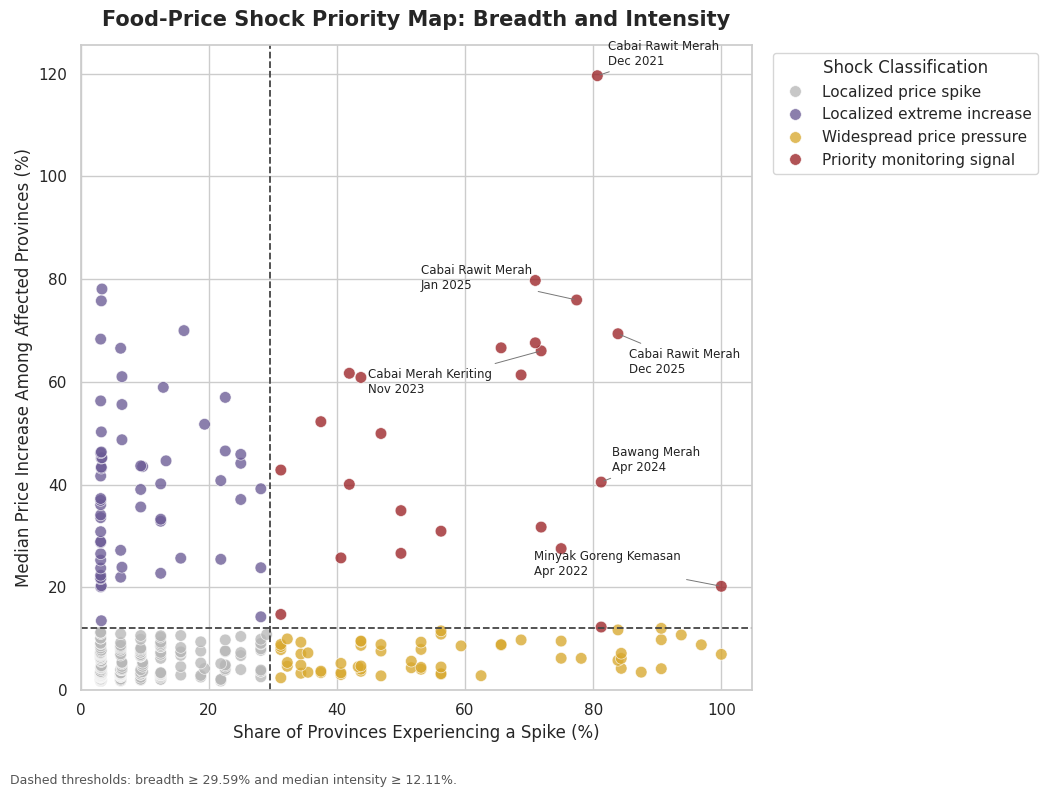

In [ ]:
bq4_plot = con.sql("SELECT * FROM bq4_shock_priority").df().copy()
bq4_plot["price_date"] = pd.to_datetime(bq4_plot["price_date"])

breadth_threshold = 29.59
intensity_threshold = 12.11

classification_order = [
    "Localized price spike",
    "Localized extreme increase",
    "Widespread price pressure",
    "Priority monitoring signal"
]

classification_colors = {
    "Localized price spike": "#B8B8B8",
    "Localized extreme increase": "#6B5B95",
    "Widespread price pressure": "#D8A82E",
    "Priority monitoring signal": "#9B2226"
}

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(13, 8))

sns.scatterplot(
    data=bq4_plot,
    x="shock_breadth_pct",
    y="median_spike_intensity_pct",
    hue="priority_classification",
    hue_order=classification_order,
    palette=classification_colors,
    s=70,
    alpha=0.78,
    edgecolor="white",
    linewidth=0.5,
    ax=ax
)

ax.axvline(
    breadth_threshold,
    color="#444444",
    linestyle="--",
    linewidth=1.3
)

ax.axhline(
    intensity_threshold,
    color="#444444",
    linestyle="--",
    linewidth=1.3
)

label_events = [
    ("Cabai Rawit Merah", "2021-12-01"),
    ("Cabai Rawit Merah", "2025-12-01"),
    ("Cabai Rawit Merah", "2025-01-01"),
    ("Cabai Merah Keriting", "2023-11-01"),
    ("Bawang Merah", "2024-04-01"),
    ("Minyak Goreng Kemasan", "2022-04-01")
]

label_offsets = {
    ("Cabai Rawit Merah", "2021-12-01"): (8, 8),
    ("Cabai Rawit Merah", "2025-12-01"): (8, -28),
    ("Cabai Rawit Merah", "2025-01-01"): (-112, 8),
    ("Cabai Merah Keriting", "2023-11-01"): (-125, -30),
    ("Bawang Merah", "2024-04-01"): (8, 8),
    ("Minyak Goreng Kemasan", "2022-04-01"): (-135, 8)
}

for commodity, event_date in label_events:
    selected = bq4_plot[
        (bq4_plot["commodity"] == commodity)
        & (bq4_plot["price_date"] == pd.Timestamp(event_date))
    ]

    if not selected.empty:
        row = selected.iloc[0]
        offset = label_offsets[(commodity, event_date)]

        ax.annotate(
            f"{commodity}\n{row['price_date']:%b %Y}",
            xy=(
                row["shock_breadth_pct"],
                row["median_spike_intensity_pct"]
            ),
            xytext=offset,
            textcoords="offset points",
            fontsize=8.5,
            color="#222222",
            arrowprops=dict(
                arrowstyle="-",
                color="#777777",
                linewidth=0.7
            )
        )

ax.set_title(
    "Food-Price Shock Priority Map: Breadth and Intensity",
    fontsize=15,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Share of Provinces Experiencing a Spike (%)")
ax.set_ylabel("Median Price Increase Among Affected Provinces (%)")

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

ax.legend(
    title="Shock Classification",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True
)

fig.text(
    0.01,
    0.01,
    "Dashed thresholds: breadth \u2265 29.59% and median intensity \u2265 12.11%.",
    fontsize=9,
    color="#555555"
)

plt.tight_layout(rect=[0, 0.04, 0.82, 1])
plt.show()

### **Business Question 4 Conclusion**

A total of **24 out of 332 spike events (7.23%)** exceeded both the geographical-breadth threshold of **29.59%** and the median-intensity threshold of **12.11%**. These events were classified as **priority monitoring signals**.

The strongest combined signal occurred for **Cabai Rawit Merah in December 2021**. Prices spiked in **25 of 31 provinces (80.65%)**, while the median increase among affected provinces reached **119.58%**. This event ranked highest because it combined extensive geographical coverage with the greatest median intensity in the dataset.

Other major priority signals were also dominated by chili commodities:

- **Cabai Rawit Merah, December 2025:** 83.87% breadth and 69.37% median intensity.
- **Cabai Rawit Merah, January 2025:** 77.42% breadth and 75.94% median intensity.
- **Cabai Rawit Merah, June 2022:** 70.97% breadth and 79.74% median intensity.
- **Cabai Merah Keriting, November 2023:** 71.88% breadth and 66.04% median intensity.

However, the priority category was not limited to chili. **Bawang Merah in April 2024** affected 81.25% of provinces with a median increase of 40.51%. Meanwhile, **Minyak Goreng Kemasan in April 2022** reached the maximum possible breadth of 100%, although its median increase was comparatively lower at 20.23%.

Overall, the findings show that **Cabai Rawit Merah generated the most severe combinations of shock breadth and intensity**. The comparison also demonstrates why breadth and intensity should be assessed together: an event may affect nearly every province without producing the largest price increase, while another may be extremely intense but remain geographically limited.

# Business Question 5: Which Provinces Tended to Show Early Price-Pressure Signals?

This analysis examines whether a province experienced a commodity-specific price spike **one month before** the same commodity developed into a widespread event.

A province–commodity observation is treated as an early signal when:

1. Its month-to-month price increase exceeds the commodity-specific 90th-percentile spike threshold.
2. The signal occurs one month before a widespread spike in the same commodity.
3. The signal month itself has not yet reached the widespread-breadth threshold.

The third condition is important because a spike occurring during an already widespread event is not considered an early warning. This analysis identifies recurring temporal patterns for monitoring purposes and does not imply that price changes in one province caused the subsequent widespread event.

In [ ]:
con.execute("""
CREATE OR REPLACE TABLE bq5_early_signal_events AS

WITH commodity_thresholds AS (
    SELECT
        commodity,
        QUANTILE_CONT(mom_change_pct, 0.90) AS spike_threshold_pct
    FROM longitudinal_price_changes
    WHERE mom_change_pct IS NOT NULL
    GROUP BY commodity
),

province_month_status AS (
    SELECT
        p.province_code,
        p.province_name,
        p.commodity,
        p.price_date,
        p.mom_change_pct,
        t.spike_threshold_pct,
        CASE
            WHEN p.mom_change_pct >= t.spike_threshold_pct THEN 1
            ELSE 0
        END AS is_spike
    FROM longitudinal_price_changes AS p
    JOIN commodity_thresholds AS t
        ON p.commodity = t.commodity
    WHERE p.mom_change_pct IS NOT NULL
),

monthly_breadth AS (
    SELECT
        commodity,
        price_date,
        COUNT(*) AS valid_province_count,
        SUM(is_spike) AS spike_province_count,
        100.0 * SUM(is_spike) / COUNT(*) AS shock_breadth_pct
    FROM province_month_status
    GROUP BY commodity, price_date
),

spike_events AS (
    SELECT *
    FROM monthly_breadth
    WHERE spike_province_count > 0
),

breadth_threshold AS (
    SELECT
        QUANTILE_CONT(shock_breadth_pct, 0.75)
            AS widespread_threshold_pct
    FROM spike_events
),

widespread_events AS (
    SELECT
        s.commodity,
        s.price_date AS widespread_date,
        s.valid_province_count,
        s.spike_province_count,
        s.shock_breadth_pct AS widespread_breadth_pct
    FROM spike_events AS s
    CROSS JOIN breadth_threshold AS b
    WHERE s.shock_breadth_pct >= b.widespread_threshold_pct
)

SELECT
    p.province_code,
    p.province_name,
    p.commodity,
    p.price_date AS signal_date,
    w.widespread_date,
    p.mom_change_pct AS signal_change_pct,
    p.spike_threshold_pct,
    m.shock_breadth_pct AS signal_month_breadth_pct,
    w.spike_province_count AS widespread_spike_provinces,
    w.valid_province_count AS widespread_valid_provinces,
    w.widespread_breadth_pct
FROM province_month_status AS p
JOIN monthly_breadth AS m
    ON p.commodity = m.commodity
    AND p.price_date = m.price_date
JOIN widespread_events AS w
    ON p.commodity = w.commodity
    AND p.price_date + INTERVAL '1 month' = w.widespread_date
CROSS JOIN breadth_threshold AS b
WHERE p.is_spike = 1
  AND m.shock_breadth_pct < b.widespread_threshold_pct
ORDER BY
    w.widespread_date,
    p.commodity,
    p.province_name
""")

bq5_early_signal_events = con.execute("""
SELECT *
FROM bq5_early_signal_events
""").df()

bq5_validation = con.execute("""
SELECT
    COUNT(*) AS province_signal_links,
    COUNT(
        DISTINCT commodity || '|' ||
        CAST(widespread_date AS VARCHAR)
    ) AS widespread_events_preceded,
    COUNT(DISTINCT province_code) AS provinces_with_signal,
    COUNT(DISTINCT commodity) AS commodities_with_signal,
    MIN(signal_date) AS earliest_signal_date,
    MAX(widespread_date) AS latest_widespread_date
FROM bq5_early_signal_events
""").df()

display(bq5_validation)
display(bq5_early_signal_events.head(15))

,province_signal_links,widespread_events_preceded,provinces_with_signal,commodities_with_signal,earliest_signal_date,latest_widespread_date
0,172,41,31,12,2021-02-01,2025-09-01


,province_code,province_name,commodity,signal_date,widespread_date,signal_change_pct,spike_threshold_pct,signal_month_breadth_pct,widespread_spike_provinces,widespread_valid_provinces,widespread_breadth_pct
0,51,Bali,Bawang Putih (Bonggol),2021-02-01,2021-03-01,6.44,6.12,3.12,10.00,32,31.25
1,14,Riau,Daging Sapi Murni,2021-03-01,2021-04-01,1.90,1.64,6.25,14.00,32,43.75
2,71,Sulawesi Utara,Daging Sapi Murni,2021-03-01,2021-04-01,1.84,1.64,6.25,14.00,32,43.75
3,11,Aceh,Kedelai Biji Kering,2021-03-01,2021-04-01,3.86,3.15,22.58,10.00,31,32.26
4,51,Bali,Kedelai Biji Kering,2021-03-01,2021-04-01,4.91,3.15,22.58,10.00,31,32.26
5,17,Bengkulu,Kedelai Biji Kering,2021-03-01,2021-04-01,7.54,3.15,22.58,10.00,31,32.26
6,33,Jawa Tengah,Kedelai Biji Kering,2021-03-01,2021-04-01,4.06,3.15,22.58,10.00,31,32.26
7,76,Sulawesi Barat,Kedelai Biji Kering,2021-03-01,2021-04-01,10.60,3.15,22.58,10.00,31,32.26
8,72,Sulawesi Tengah,Kedelai Biji Kering,2021-03-01,2021-04-01,13.57,3.15,22.58,10.00,31,32.26
9,71,Sulawesi Utara,Kedelai Biji Kering,2021-03-01,2021-04-01,12.78,3.15,22.58,10.00,31,32.26


### Province-Level Early-Signal Ranking

Provinces are evaluated using several complementary indicators:

- **Candidate signals:** commodity-specific provincial spikes occurring while the same-month shock was not yet widespread.
- **Confirmed early signals:** candidate signals followed by a widespread event for the same commodity in the next month.
- **Confirmation rate:** the percentage of candidate signals that were followed by a widespread event.
- **Event coverage:** the percentage of all identified widespread events preceded by the province.
- **Commodity diversity:** the number of different commodities for which the province generated a confirmed early signal.

The ranking prioritizes repeated confirmed signals, followed by commodity diversity and confirmation rate. This prevents a province with only one successful occurrence from being ranked above provinces that produced recurring signals across different events.

In [ ]:
con.execute("""
CREATE OR REPLACE TABLE bq5_province_ranking AS

WITH commodity_thresholds AS (
    SELECT
        commodity,
        QUANTILE_CONT(mom_change_pct, 0.90) AS spike_threshold_pct
    FROM longitudinal_price_changes
    WHERE mom_change_pct IS NOT NULL
    GROUP BY commodity
),

province_month_status AS (
    SELECT
        p.province_code,
        p.province_name,
        p.commodity,
        p.price_date,
        p.mom_change_pct,
        t.spike_threshold_pct,
        CASE
            WHEN p.mom_change_pct >= t.spike_threshold_pct THEN 1
            ELSE 0
        END AS is_spike
    FROM longitudinal_price_changes AS p
    JOIN commodity_thresholds AS t
        ON p.commodity = t.commodity
    WHERE p.mom_change_pct IS NOT NULL
),

monthly_breadth AS (
    SELECT
        commodity,
        price_date,
        COUNT(*) AS valid_province_count,
        SUM(is_spike) AS spike_province_count,
        100.0 * SUM(is_spike) / COUNT(*) AS shock_breadth_pct
    FROM province_month_status
    GROUP BY commodity, price_date
),

spike_events AS (
    SELECT *
    FROM monthly_breadth
    WHERE spike_province_count > 0
),

breadth_threshold AS (
    SELECT
        QUANTILE_CONT(shock_breadth_pct, 0.75)
            AS widespread_threshold_pct
    FROM spike_events
),

candidate_signals AS (
    SELECT
        p.province_code,
        p.province_name,
        p.commodity,
        p.price_date
    FROM province_month_status AS p
    JOIN monthly_breadth AS current_month
        ON p.commodity = current_month.commodity
        AND p.price_date = current_month.price_date
    JOIN monthly_breadth AS next_month
        ON p.commodity = next_month.commodity
        AND p.price_date + INTERVAL '1 month' = next_month.price_date
    CROSS JOIN breadth_threshold AS b
    WHERE p.is_spike = 1
      AND current_month.shock_breadth_pct < b.widespread_threshold_pct
),

candidate_summary AS (
    SELECT
        province_code,
        province_name,
        COUNT(*) AS candidate_signal_count
    FROM candidate_signals
    GROUP BY province_code, province_name
),

confirmed_summary AS (
    SELECT
        province_code,
        province_name,
        COUNT(*) AS confirmed_early_signals,
        COUNT(DISTINCT commodity) AS commodity_diversity,
        AVG(signal_change_pct) AS average_signal_change_pct,
        AVG(widespread_breadth_pct) AS average_following_breadth_pct
    FROM bq5_early_signal_events
    GROUP BY province_code, province_name
),

event_total AS (
    SELECT
        COUNT(
            DISTINCT commodity || '|' ||
            CAST(widespread_date AS VARCHAR)
        ) AS total_preceded_events
    FROM bq5_early_signal_events
),

ranking_base AS (
    SELECT
        c.province_code,
        c.province_name,
        c.candidate_signal_count,
        COALESCE(s.confirmed_early_signals, 0)
            AS confirmed_early_signals,
        COALESCE(s.commodity_diversity, 0)
            AS commodity_diversity,
        ROUND(
            100.0 * COALESCE(s.confirmed_early_signals, 0)
            / c.candidate_signal_count,
            2
        ) AS confirmation_rate_pct,
        ROUND(
            100.0 * COALESCE(s.confirmed_early_signals, 0)
            / e.total_preceded_events,
            2
        ) AS widespread_event_coverage_pct,
        ROUND(s.average_signal_change_pct, 2)
            AS average_signal_change_pct,
        ROUND(s.average_following_breadth_pct, 2)
            AS average_following_breadth_pct
    FROM candidate_summary AS c
    LEFT JOIN confirmed_summary AS s
        ON c.province_code = s.province_code
    CROSS JOIN event_total AS e
)

SELECT
    RANK() OVER (
        ORDER BY
            confirmed_early_signals DESC,
            commodity_diversity DESC,
            confirmation_rate_pct DESC
    ) AS early_signal_rank,
    *
FROM ranking_base
ORDER BY
    early_signal_rank,
    province_name
""")

bq5_province_ranking = con.execute("""
SELECT *
FROM bq5_province_ranking
""").df()

display(bq5_province_ranking.head(15))

,early_signal_rank,province_code,province_name,candidate_signal_count,confirmed_early_signals,commodity_diversity,confirmation_rate_pct,widespread_event_coverage_pct,average_signal_change_pct,average_following_breadth_pct
0,1,34,DI Yogyakarta,37,12,9,32.43,29.27,12.96,59.38
1,2,51,Bali,35,10,8,28.57,24.39,6.96,55.73
2,3,16,Sumatera Selatan,23,9,8,39.13,21.95,12.42,53.19
3,4,33,Jawa Tengah,21,9,7,42.86,21.95,10.85,58.74
4,5,11,Aceh,26,9,7,34.62,21.95,9.07,59.58
5,6,75,Gorontalo,45,9,7,20.00,21.95,15.84,53.24
6,7,17,Bengkulu,31,9,6,29.03,21.95,12.19,51.04
7,8,71,Sulawesi Utara,29,8,6,27.59,19.51,11.97,41.14
8,9,36,Banten,19,7,6,36.84,17.07,7.43,58.18
9,10,15,Jambi,21,7,6,33.33,17.07,17.68,55.07


### Recurring Early-Signal Provinces

The chart ranks the 15 provinces with the highest number of confirmed early signals. Bar length represents how frequently a province preceded a widespread event, while color represents its confirmation rate.

Labels compare confirmed signals with all candidate signals. This distinction helps separate provinces that repeatedly provided useful early signals from provinces that merely experienced frequent localized spikes.

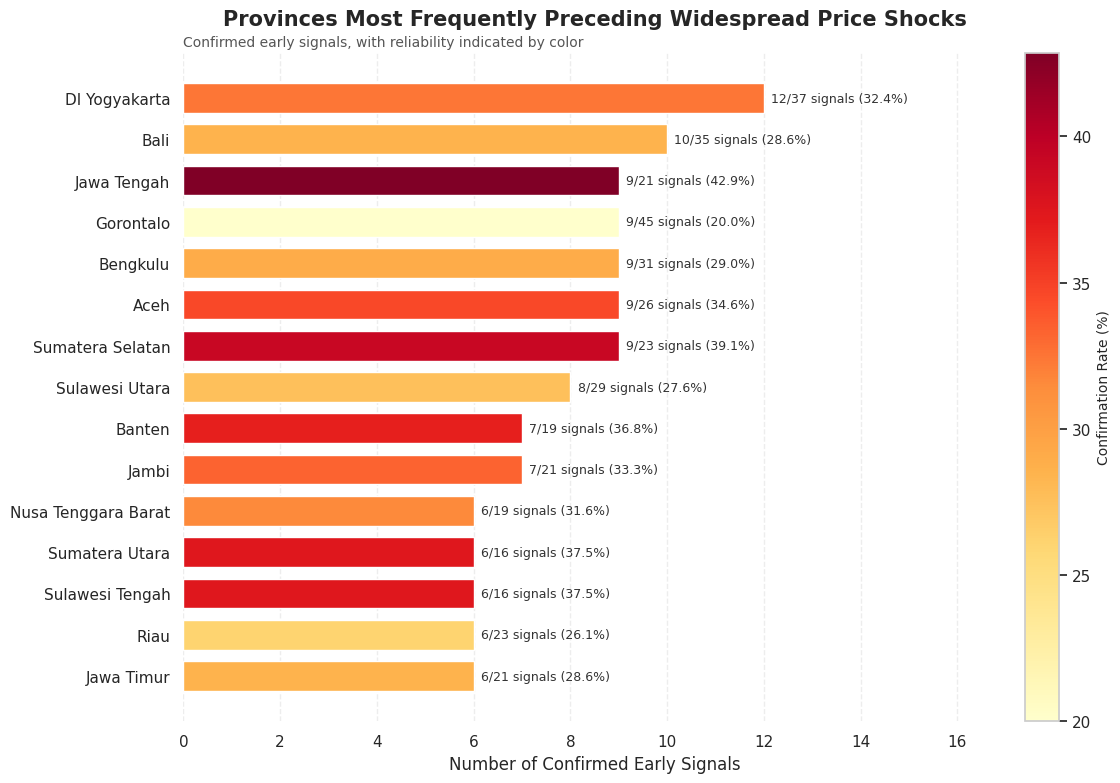

In [ ]:
import matplotlib.dates as mdates
import matplotlib as mpl

top15_signals = (
    bq5_province_ranking
    .head(15)
    .sort_values("confirmed_early_signals", ascending=True)
    .copy()
)

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 8))

norm = mpl.colors.Normalize(
    vmin=top15_signals["confirmation_rate_pct"].min(),
    vmax=top15_signals["confirmation_rate_pct"].max()
)

cmap = mpl.colormaps["YlOrRd"]

bar_colors = cmap(
    norm(top15_signals["confirmation_rate_pct"])
)

bars = ax.barh(
    top15_signals["province_name"],
    top15_signals["confirmed_early_signals"],
    color=bar_colors,
    edgecolor="white",
    height=0.72
)

for bar, (_, row) in zip(bars, top15_signals.iterrows()):
    ax.text(
        bar.get_width() + 0.15,
        bar.get_y() + bar.get_height() / 2,
        (
            f"{int(row['confirmed_early_signals'])}/"
            f"{int(row['candidate_signal_count'])} signals "
            f"({row['confirmation_rate_pct']:.1f}%)"
        ),
        va="center",
        fontsize=9,
        color="#333333"
    )

scalar_map = mpl.cm.ScalarMappable(
    norm=norm,
    cmap=cmap
)
scalar_map.set_array([])

colorbar = fig.colorbar(
    scalar_map,
    ax=ax,
    pad=0.02
)

colorbar.set_label(
    "Confirmation Rate (%)",
    fontsize=10
)

ax.set_title(
    "Provinces Most Frequently Preceding Widespread Price Shocks",
    fontsize=15,
    fontweight="bold",
    pad=20
)

ax.text(
    0,
    1.01,
    "Confirmed early signals, with reliability indicated by color",
    transform=ax.transAxes,
    fontsize=10,
    color="#555555"
)

ax.set_xlabel("Number of Confirmed Early Signals")
ax.set_ylabel("")

ax.set_xlim(
    0,
    top15_signals["confirmed_early_signals"].max() + 5
)

ax.xaxis.set_major_locator(
    mpl.ticker.MaxNLocator(integer=True)
)

ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.grid(axis="y", visible=False)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

### **Business Question 5 Conclusion**

The analysis identified **172 confirmed province-level early signals** preceding **41 widespread commodity shock events**. Confirmed signals appeared in **31 of the 32 provinces** included in the longitudinal analysis and covered all 12 commodities.

**DI Yogyakarta** produced the most frequent early signals. It preceded **12 of the 41 widespread events (29.27%)**, covering nine different commodities. Of its 37 candidate signals, 32.43% were followed by a widespread event in the next month.

**Bali** ranked second with 10 confirmed signals across eight commodities. However, its confirmation rate was lower at 28.57%, indicating that many of its localized spikes did not subsequently become widespread.

Among provinces with nine confirmed signals, **Jawa Tengah** showed the strongest reliability. Nine of its 21 candidate signals were confirmed, resulting in the highest confirmation rate among the leading provinces at **42.86%**. **Sumatera Selatan** also displayed a relatively strong combination of frequency and reliability, with nine confirmed signals across eight commodities and a confirmation rate of 39.13%.

In contrast, **Gorontalo** generated 45 candidate signals—the largest number among the leading provinces—but only nine were followed by widespread shocks. Its 20.00% confirmation rate suggests that price spikes in Gorontalo were frequently localized rather than early indications of broader pressure.

Overall, **DI Yogyakarta was the most frequent and commodity-diverse early-monitoring province**, while **Jawa Tengah provided the most reliable signals among the highest-ranked provinces**. These results identify descriptive monitoring patterns only: they do not demonstrate that price changes in these provinces caused subsequent price movements elsewhere.

# Business Question 6: Which Provinces Recovered Most Quickly After a Food-Price Spike?

Price recovery is evaluated at the province–commodity level. For each identified spike, the price recorded one month before the spike is treated as the pre-spike baseline.

A price is considered recovered when at least **80% of the initial spike increase has been reversed**. Equivalently, the price must return to the pre-spike level plus no more than 20% of the initial increase.

This relative definition adapts to commodities with different levels of price volatility. It also ensures that the recovery target is always below the initial spike price.

Recovery outcomes are classified as:

- **Immediate recovery:** reached the recovery target within one month.
- **Gradual recovery:** reached the recovery target within two to six months.
- **No recovery within six months:** declined from the spike level but did not reverse at least 80% of the increase.
- **Continued price increase:** remained unrecovered and was higher after six months than at the initial spike.

Only spike events with a complete six-month follow-up period are included. Events after June 2025 are excluded to avoid right-censoring.

In [ ]:
con.execute("""
CREATE OR REPLACE TABLE bq6_spike_recovery_events AS

WITH price_history AS (
    SELECT
        province_code,
        province_name,
        commodity,
        price_date,
        analysis_price,
        LAG(analysis_price) OVER (
            PARTITION BY province_code, commodity
            ORDER BY price_date
        ) AS pre_spike_price
    FROM validated_longitudinal_prices
),

commodity_thresholds AS (
    SELECT
        commodity,
        QUANTILE_CONT(mom_change_pct, 0.90)
            AS spike_threshold_pct
    FROM longitudinal_price_changes
    WHERE mom_change_pct IS NOT NULL
    GROUP BY commodity
),

eligible_spikes AS (
    SELECT
        h.province_code,
        h.province_name,
        h.commodity,
        h.price_date AS spike_date,
        h.pre_spike_price,
        h.analysis_price AS spike_price,
        c.mom_change_pct AS spike_change_pct,
        t.spike_threshold_pct
    FROM price_history AS h
    JOIN longitudinal_price_changes AS c
        ON h.province_code = c.province_code
        AND h.commodity = c.commodity
        AND h.price_date = c.price_date
    JOIN commodity_thresholds AS t
        ON h.commodity = t.commodity
    WHERE c.mom_change_pct >= t.spike_threshold_pct
      AND h.pre_spike_price IS NOT NULL
      AND h.analysis_price IS NOT NULL
      AND h.analysis_price > h.pre_spike_price
      AND h.price_date <= DATE '2025-06-01'
),

spikes_with_target AS (
    SELECT
        *,
        pre_spike_price
        + 0.20 * (spike_price - pre_spike_price)
            AS recovery_target_price
    FROM eligible_spikes
),

recovery_search AS (
    SELECT
        s.province_code,
        s.province_name,
        s.commodity,
        s.spike_date,
        s.pre_spike_price,
        s.spike_price,
        s.spike_change_pct,
        s.spike_threshold_pct,
        s.recovery_target_price,

        MIN(
            CASE
                WHEN f.analysis_price <= s.recovery_target_price
                THEN f.price_date
            END
        ) AS recovery_date,

        MAX(
            CASE
                WHEN f.price_date =
                     s.spike_date + INTERVAL '6 months'
                THEN f.analysis_price
            END
        ) AS month_6_price

    FROM spikes_with_target AS s
    LEFT JOIN validated_longitudinal_prices AS f
        ON s.province_code = f.province_code
        AND s.commodity = f.commodity
        AND f.price_date > s.spike_date
        AND f.price_date <=
            s.spike_date + INTERVAL '6 months'

    GROUP BY
        s.province_code,
        s.province_name,
        s.commodity,
        s.spike_date,
        s.pre_spike_price,
        s.spike_price,
        s.spike_change_pct,
        s.spike_threshold_pct,
        s.recovery_target_price
),

recovery_calculation AS (
    SELECT
        *,
        DATE_DIFF(
            'month',
            spike_date,
            recovery_date
        ) AS recovery_months
    FROM recovery_search
    WHERE month_6_price IS NOT NULL
)

SELECT
    province_code,
    province_name,
    commodity,
    spike_date,
    ROUND(pre_spike_price, 2) AS pre_spike_price,
    ROUND(spike_price, 2) AS spike_price,
    ROUND(spike_change_pct, 2) AS spike_change_pct,
    ROUND(recovery_target_price, 2)
        AS recovery_target_price,
    recovery_date,
    recovery_months,
    ROUND(month_6_price, 2) AS month_6_price,

    CASE
        WHEN recovery_months = 1
            THEN 'Immediate recovery'

        WHEN recovery_months BETWEEN 2 AND 6
            THEN 'Gradual recovery'

        WHEN recovery_date IS NULL
             AND month_6_price > spike_price
            THEN 'Continued price increase'

        ELSE 'No recovery within six months'
    END AS recovery_status

FROM recovery_calculation
ORDER BY
    spike_date,
    province_name,
    commodity
""")

bq6_spike_recovery_events = con.execute("""
SELECT *
FROM bq6_spike_recovery_events
""").df()

bq6_recovery_validation = con.execute("""
SELECT
    COUNT(*) AS eligible_spike_events,

    COUNT(*) FILTER (
        WHERE recovery_date IS NOT NULL
    ) AS recovered_events,

    COUNT(*) FILTER (
        WHERE recovery_date IS NULL
    ) AS unrecovered_events,

    ROUND(
        100.0 * COUNT(*) FILTER (
            WHERE recovery_date IS NOT NULL
        ) / COUNT(*),
        2
    ) AS overall_recovery_rate_pct,

    ROUND(
        AVG(recovery_months) FILTER (
            WHERE recovery_months IS NOT NULL
        ),
        2
    ) AS average_recovery_months,

    COUNT(*) FILTER (
        WHERE recovery_target_price >= spike_price
    ) AS invalid_recovery_targets

FROM bq6_spike_recovery_events
""").df()

bq6_status_summary = con.execute("""
SELECT
    recovery_status,
    COUNT(*) AS event_count,
    ROUND(
        100.0 * COUNT(*) /
        SUM(COUNT(*)) OVER (),
        2
    ) AS event_share_pct
FROM bq6_spike_recovery_events
GROUP BY recovery_status
ORDER BY event_count DESC
""").df()

display(bq6_recovery_validation)
display(bq6_status_summary)
display(bq6_spike_recovery_events.head(10))

,eligible_spike_events,recovered_events,unrecovered_events,overall_recovery_rate_pct,average_recovery_months,invalid_recovery_targets
0,2131,857,1274,40.22,3.05,0


,recovery_status,event_count,event_share_pct
0,Continued price increase,975,45.75
1,Gradual recovery,697,32.71
2,No recovery within six months,299,14.03
3,Immediate recovery,160,7.51


,province_code,province_name,commodity,spike_date,pre_spike_price,spike_price,spike_change_pct,recovery_target_price,recovery_date,recovery_months,month_6_price,recovery_status
0,51,Bali,Bawang Putih (Bonggol),2021-02-01,"21,601.00","22,993.00",6.44,"21,879.40",NaT,<NA>,"23,602.00",Continued price increase
1,51,Bali,Cabai Merah Keriting,2021-02-01,"40,250.00","62,909.00",56.30,"44,781.80",2021-05-01,3,"26,679.00",Gradual recovery
2,51,Bali,Kedelai Biji Kering,2021-02-01,"10,277.00","10,677.00",3.89,"10,357.00",NaT,<NA>,"11,707.00",Continued price increase
3,36,Banten,Daging Sapi Murni,2021-02-01,"119,478.00","121,804.00",1.95,"119,943.20",2021-03-01,1,"125,837.00",Immediate recovery
4,34,DI Yogyakarta,Daging Sapi Murni,2021-02-01,"120,241.00","124,138.00",3.24,"121,020.40",NaT,<NA>,"124,419.00",Continued price increase
5,34,DI Yogyakarta,Kedelai Biji Kering,2021-02-01,"9,876.00","11,039.00",11.78,"10,108.60",NaT,<NA>,"10,573.00",No recovery within six months
6,31,DKI Jakarta,Daging Sapi Murni,2021-02-01,"121,254.00","124,302.00",2.51,"121,863.60",NaT,<NA>,"128,918.00",Continued price increase
7,15,Jambi,Kedelai Biji Kering,2021-02-01,"10,250.00","10,617.00",3.58,"10,323.40",NaT,<NA>,"11,435.00",Continued price increase
8,35,Jawa Timur,Kedelai Biji Kering,2021-02-01,"9,668.00","10,083.00",4.29,"9,751.00",NaT,<NA>,"11,112.00",Continued price increase
9,64,Kalimantan Timur,Kedelai Biji Kering,2021-02-01,"11,614.00","12,341.00",6.26,"11,759.40",NaT,<NA>,"12,996.00",Continued price increase


### Province-Level Recovery Performance

Recovery performance is summarized for each province using:

- The total number of eligible spike events.
- The number and percentage of events that recovered within six months.
- The percentage that recovered immediately within one month.
- The median and average recovery duration among recovered events.
- The number of events that remained unrecovered or continued increasing.

Provinces are ranked primarily by their average recovery duration. Recovery rate and immediate-recovery frequency are retained as supporting indicators because a short average based on only a limited number of successful recoveries may not represent consistently strong resilience.

In [ ]:
con.execute("""
CREATE OR REPLACE TABLE bq6_province_recovery_ranking AS

WITH province_summary AS (
    SELECT
        province_code,
        province_name,

        COUNT(*) AS eligible_spike_events,

        COUNT(*) FILTER (
            WHERE recovery_date IS NOT NULL
        ) AS recovered_events,

        COUNT(*) FILTER (
            WHERE recovery_status = 'Immediate recovery'
        ) AS immediate_recovery_events,

        COUNT(*) FILTER (
            WHERE recovery_status = 'Gradual recovery'
        ) AS gradual_recovery_events,

        COUNT(*) FILTER (
            WHERE recovery_status =
                  'No recovery within six months'
        ) AS no_recovery_events,

        COUNT(*) FILTER (
            WHERE recovery_status =
                  'Continued price increase'
        ) AS continued_increase_events,

        100.0 * COUNT(*) FILTER (
            WHERE recovery_date IS NOT NULL
        ) / COUNT(*) AS recovery_rate_pct,

        100.0 * COUNT(*) FILTER (
            WHERE recovery_status = 'Immediate recovery'
        ) / COUNT(*) AS immediate_recovery_rate_pct,

        MEDIAN(recovery_months) FILTER (
            WHERE recovery_months IS NOT NULL
        ) AS median_recovery_months,

        AVG(recovery_months) FILTER (
            WHERE recovery_months IS NOT NULL
        ) AS average_recovery_months

    FROM bq6_spike_recovery_events
    GROUP BY
        province_code,
        province_name
),

rounded_summary AS (
    SELECT
        province_code,
        province_name,
        eligible_spike_events,
        recovered_events,
        immediate_recovery_events,
        gradual_recovery_events,
        no_recovery_events,
        continued_increase_events,
        ROUND(recovery_rate_pct, 2)
            AS recovery_rate_pct,
        ROUND(immediate_recovery_rate_pct, 2)
            AS immediate_recovery_rate_pct,
        ROUND(median_recovery_months, 2)
            AS median_recovery_months,
        ROUND(average_recovery_months, 2)
            AS average_recovery_months
    FROM province_summary
)

SELECT
    RANK() OVER (
        ORDER BY
            average_recovery_months ASC,
            recovery_rate_pct DESC,
            immediate_recovery_rate_pct DESC
    ) AS recovery_speed_rank,
    *
FROM rounded_summary
ORDER BY
    recovery_speed_rank,
    province_name
""")

bq6_province_recovery_ranking = con.execute("""
SELECT *
FROM bq6_province_recovery_ranking
""").df()

display(bq6_province_recovery_ranking.head(15))

,recovery_speed_rank,province_code,province_name,eligible_spike_events,recovered_events,immediate_recovery_events,gradual_recovery_events,no_recovery_events,continued_increase_events,recovery_rate_pct,immediate_recovery_rate_pct,median_recovery_months,average_recovery_months
0,1,64,Kalimantan Timur,70,20,5,15,14,36,28.57,7.14,2.00,2.50
1,2,53,Nusa Tenggara Timur,49,18,3,15,8,23,36.73,6.12,2.00,2.56
2,3,15,Jambi,67,29,9,20,13,25,43.28,13.43,3.00,2.66
3,4,63,Kalimantan Selatan,73,25,4,21,14,34,34.25,5.48,3.00,2.72
4,5,14,Riau,67,33,8,25,5,29,49.25,11.94,2.00,2.76
5,6,52,Nusa Tenggara Barat,69,25,6,19,11,33,36.23,8.70,2.00,2.80
6,7,51,Bali,89,37,8,29,6,46,41.57,8.99,3.00,2.89
7,8,71,Sulawesi Utara,73,33,7,26,11,29,45.21,9.59,3.00,2.91
8,9,76,Sulawesi Barat,75,32,6,26,9,34,42.67,8.00,3.00,2.91
9,10,82,Maluku Utara,46,11,1,10,10,25,23.91,2.17,2.00,2.91


### Recovery Speed and Recovery Success Rate

Average recovery duration alone does not describe the overall resilience of a province. A province may recover quickly among its successful cases while leaving most spike events unrecovered.

The following chart therefore compares:

- **Recovery speed:** average number of months required to reach the recovery target.
- **Recovery success:** percentage of eligible spike events that recovered within six months.
- **Observation volume:** represented by point size based on the number of eligible spike events.

The upper-left area represents the stronger combined profile: faster-than-average recovery together with an above-average recovery rate.

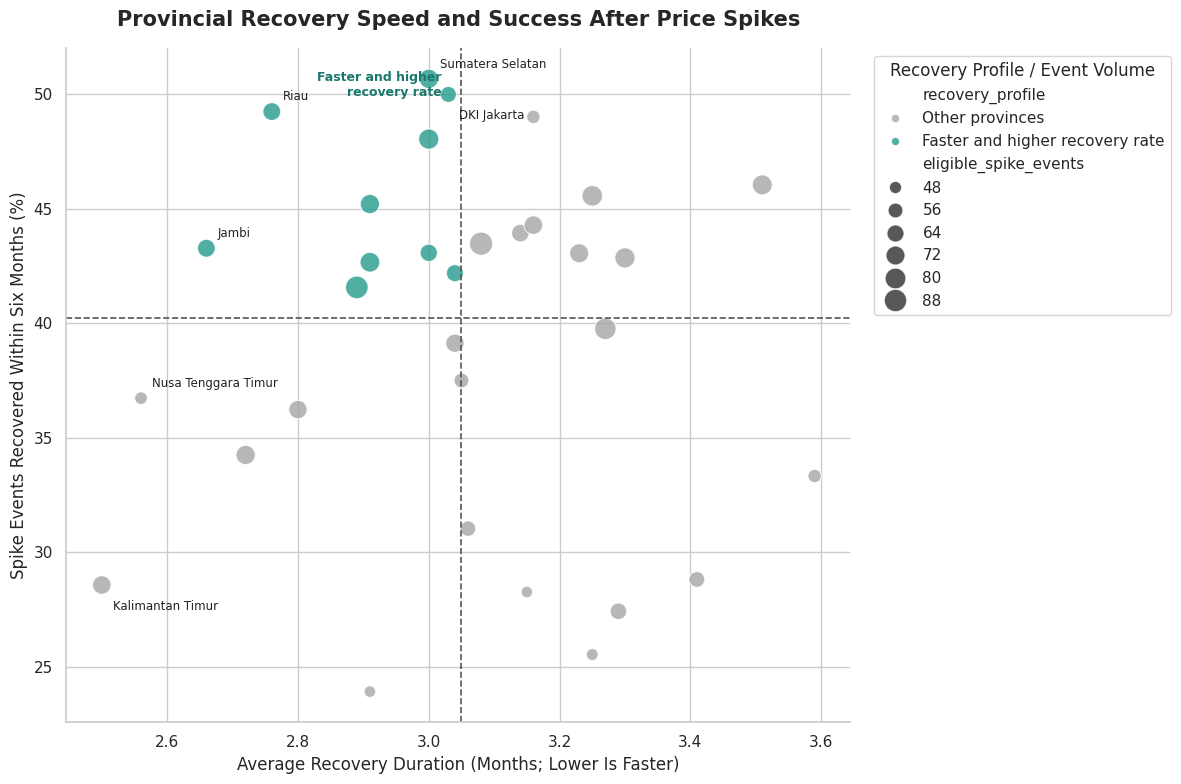

In [ ]:
recovery_plot = bq6_province_recovery_ranking.copy()

overall_recovery_rate = float(
    bq6_recovery_validation.loc[
        0, "overall_recovery_rate_pct"
    ]
)

overall_recovery_months = float(
    bq6_recovery_validation.loc[
        0, "average_recovery_months"
    ]
)

recovery_plot["recovery_profile"] = recovery_plot.apply(
    lambda row: (
        "Faster and higher recovery rate"
        if (
            row["average_recovery_months"]
            <= overall_recovery_months
            and row["recovery_rate_pct"]
            >= overall_recovery_rate
        )
        else "Other provinces"
    ),
    axis=1
)

palette = {
    "Faster and higher recovery rate": "#2A9D8F",
    "Other provinces": "#A7A7A7"
}

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 8))

sns.scatterplot(
    data=recovery_plot,
    x="average_recovery_months",
    y="recovery_rate_pct",
    hue="recovery_profile",
    size="eligible_spike_events",
    sizes=(70, 280),
    palette=palette,
    alpha=0.82,
    edgecolor="white",
    linewidth=0.8,
    ax=ax
)

# Overall benchmarks
ax.axvline(
    overall_recovery_months,
    color="#555555",
    linestyle="--",
    linewidth=1.2
)

ax.axhline(
    overall_recovery_rate,
    color="#555555",
    linestyle="--",
    linewidth=1.2
)

# Label selected provinces
selected_provinces = [
    "Kalimantan Timur",
    "Nusa Tenggara Timur",
    "Jambi",
    "Riau",
    "Sumatera Selatan",
    "DKI Jakarta"
]

label_offsets = {
    "Kalimantan Timur": (8, -18),
    "Nusa Tenggara Timur": (8, 8),
    "Jambi": (8, 8),
    "Riau": (8, 8),
    "Sumatera Selatan": (8, 8),
    "DKI Jakarta": (8, -18)
}

for _, row in recovery_plot[
    recovery_plot["province_name"].isin(selected_provinces)
].iterrows():

    ax.annotate(
        row["province_name"],
        (
            row["average_recovery_months"],
            row["recovery_rate_pct"]
        ),
        xytext=label_offsets[row["province_name"]],
        textcoords="offset points",
        fontsize=8.5,
        color="#222222"
    )

ax.text(
    overall_recovery_months - 0.03,
    ax.get_ylim()[1] - 1,
    "Faster and higher\nrecovery rate",
    ha="right",
    va="top",
    fontsize=9,
    color="#18786E",
    fontweight="bold"
)

ax.set_title(
    "Provincial Recovery Speed and Success After Price Spikes",
    fontsize=15,
    fontweight="bold",
    pad=16
)

ax.set_xlabel(
    "Average Recovery Duration (Months; Lower Is Faster)"
)

ax.set_ylabel(
    "Spike Events Recovered Within Six Months (%)"
)

ax.legend(
    title="Recovery Profile / Event Volume",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True
)

sns.despine()
plt.tight_layout()
plt.show()

### **Business Question 6 Conclusion**

Using an 80% reversal of the initial price increase as the recovery target, **857 of 2,131 eligible spike events (40.22%)** recovered within six months. Among recovered events, the average recovery duration was 3.05 months.

**Kalimantan Timur** recorded the shortest average recovery duration at **2.50 months**. However, only 20 of its 70 eligible spike events recovered, resulting in a relatively low recovery rate of **28.57%**. Therefore, Kalimantan Timur recovered quickly when recovery occurred, but most of its spike events did not reach the recovery target within six months.

**Nusa Tenggara Timur** ranked second in speed at 2.56 months, with a recovery rate of 36.73%. **Jambi** ranked third at 2.66 months and showed a stronger recovery rate of 43.28%.

Among the relatively fast-recovering provinces, **Riau demonstrated the strongest balance between speed and consistency**. Its recovered events returned toward the pre-spike level in an average of **2.76 months**, while 33 of 67 eligible events recovered, producing a recovery rate of **49.25%**.

**Sumatera Selatan** achieved a slightly longer average recovery duration of 3.00 months but recorded the highest recovery rate among the leading provinces at **50.68%**. **DKI Jakarta** showed a similar profile, with an average recovery duration of 3.03 months and a 50.00% recovery rate.

Overall, Kalimantan Timur was the fastest province based strictly on recovery duration. However, Riau presented a stronger combined profile because it maintained relatively rapid recovery together with a substantially higher probability of recovering. This distinction shows that recovery speed and recovery success should be evaluated together when assessing regional price resilience.

# Business Question 7: Which Commodities Were Most Likely to Remain Elevated After an Initial Spike?

Commodity persistence is evaluated using the same recovery target established in the previous analysis: at least 80% of the initial spike increase must be reversed.

A spike is considered to remain elevated through a particular horizon when its price has not reached the recovery target at any monthly observation up to that point.

Persistence is measured at three horizons:

- **One-month persistence:** no recovery within the first month.
- **Three-month persistence:** no recovery within the first three months.
- **Six-month persistence:** no recovery during the complete six-month observation window.

The six-month persistence rate is used as the primary ranking indicator, while the shorter horizons show whether price pressure tends to disappear gradually or remain elevated from the beginning.

In [ ]:
con.execute("""
CREATE OR REPLACE TABLE bq7_commodity_persistence AS

WITH commodity_summary AS (
    SELECT
        commodity,

        COUNT(*) AS eligible_spike_events,

        COUNT(*) FILTER (
            WHERE recovery_months IS NULL
               OR recovery_months > 1
        ) AS elevated_through_1_month,

        COUNT(*) FILTER (
            WHERE recovery_months IS NULL
               OR recovery_months > 3
        ) AS elevated_through_3_months,

        COUNT(*) FILTER (
            WHERE recovery_date IS NULL
        ) AS elevated_through_6_months,

        COUNT(*) FILTER (
            WHERE recovery_status =
                  'Continued price increase'
        ) AS continued_increase_events,

        COUNT(*) FILTER (
            WHERE recovery_date IS NOT NULL
        ) AS recovered_events,

        100.0 * COUNT(*) FILTER (
            WHERE recovery_months IS NULL
               OR recovery_months > 1
        ) / COUNT(*) AS persistence_1_month_pct,

        100.0 * COUNT(*) FILTER (
            WHERE recovery_months IS NULL
               OR recovery_months > 3
        ) / COUNT(*) AS persistence_3_month_pct,

        100.0 * COUNT(*) FILTER (
            WHERE recovery_date IS NULL
        ) / COUNT(*) AS persistence_6_month_pct,

        100.0 * COUNT(*) FILTER (
            WHERE recovery_status =
                  'Continued price increase'
        ) / COUNT(*) AS continued_increase_rate_pct,

        AVG(recovery_months) FILTER (
            WHERE recovery_months IS NOT NULL
        ) AS average_recovery_months

    FROM bq6_spike_recovery_events
    GROUP BY commodity
),

rounded_summary AS (
    SELECT
        commodity,
        eligible_spike_events,
        elevated_through_1_month,
        elevated_through_3_months,
        elevated_through_6_months,
        continued_increase_events,
        recovered_events,
        ROUND(persistence_1_month_pct, 2)
            AS persistence_1_month_pct,
        ROUND(persistence_3_month_pct, 2)
            AS persistence_3_month_pct,
        ROUND(persistence_6_month_pct, 2)
            AS persistence_6_month_pct,
        ROUND(continued_increase_rate_pct, 2)
            AS continued_increase_rate_pct,
        ROUND(average_recovery_months, 2)
            AS average_recovery_months
    FROM commodity_summary
)

SELECT
    RANK() OVER (
        ORDER BY
            persistence_6_month_pct DESC,
            persistence_3_month_pct DESC,
            persistence_1_month_pct DESC
    ) AS persistence_rank,
    *
FROM rounded_summary
ORDER BY
    persistence_rank,
    commodity
""")

bq7_commodity_persistence = con.execute("""
SELECT *
FROM bq7_commodity_persistence
""").df()

display(
    bq7_commodity_persistence[
        [
            "persistence_rank",
            "commodity",
            "eligible_spike_events",
            "persistence_1_month_pct",
            "persistence_3_month_pct",
            "persistence_6_month_pct",
            "continued_increase_rate_pct",
            "average_recovery_months"
        ]
    ]
)

,persistence_rank,commodity,eligible_spike_events,persistence_1_month_pct,persistence_3_month_pct,persistence_6_month_pct,continued_increase_rate_pct,average_recovery_months
0,1,Gula Pasir Lokal/Curah,187,100.00,91.98,85.03,74.33,3.57
1,2,Beras Premium,178,91.57,81.46,77.53,54.49,2.25
2,3,Beras Medium,176,97.16,84.09,77.27,66.48,3.03
3,4,Kedelai Biji Kering,184,98.37,91.30,77.17,65.76,4.33
4,5,Minyak Goreng Kemasan,188,98.40,85.64,67.55,57.45,3.54
5,6,Daging Sapi Murni,189,85.19,73.54,66.67,43.92,2.30
6,7,Bawang Putih (Bonggol),185,98.38,78.92,65.95,47.57,3.21
7,8,Telur Ayam Ras,185,82.16,65.41,45.95,37.84,2.77
8,9,Bawang Merah,171,89.47,55.56,45.61,29.82,2.66
9,10,Cabai Merah Keriting,170,92.94,76.47,40.59,25.29,3.58


### Commodity Persistence Across Recovery Horizons

The following chart compares the percentage of spike events that had not reached the recovery target after one, three, and six months.

A large decline between horizons indicates that many spikes eventually reversed, while consistently high percentages indicate persistent price pressure. Commodities are ordered according to their six-month persistence rate.

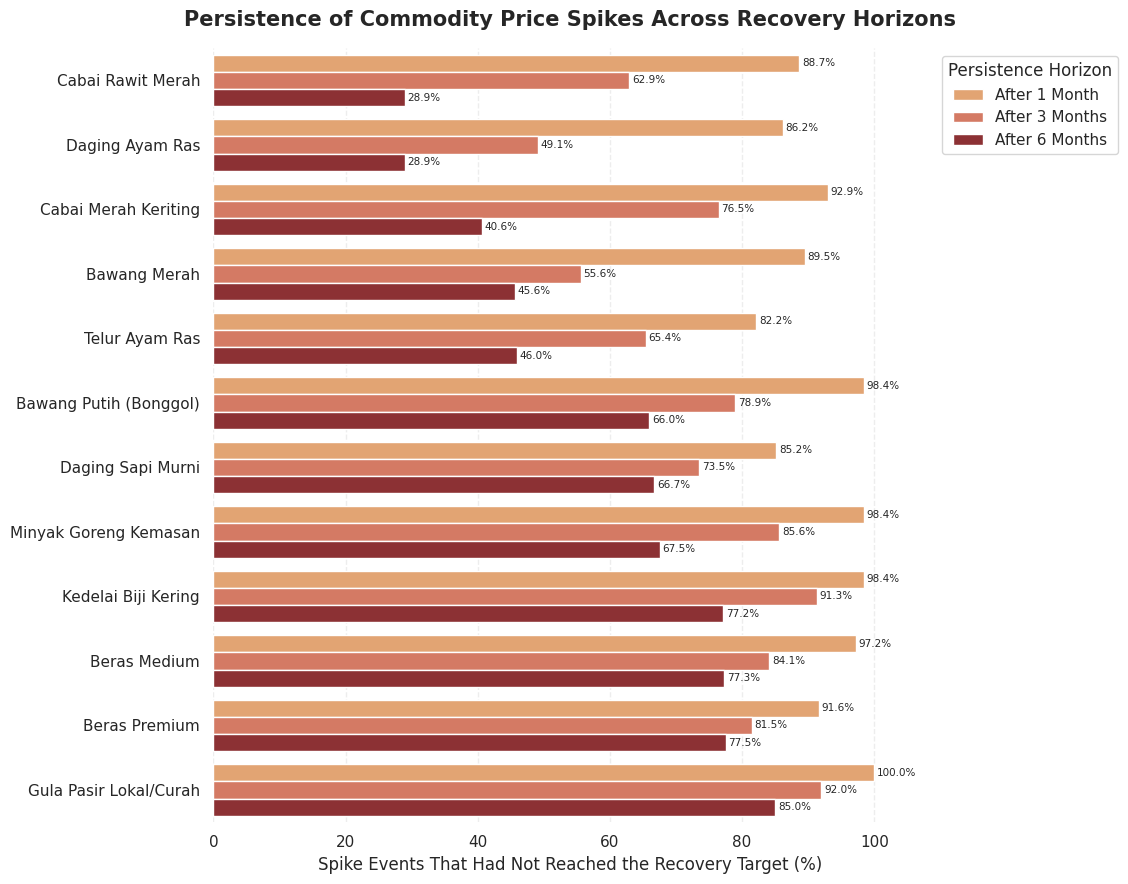

In [ ]:
commodity_order = (
    bq7_commodity_persistence
    .sort_values("persistence_6_month_pct")["commodity"]
    .tolist()
)

persistence_long = bq7_commodity_persistence.melt(
    id_vars=["commodity"],
    value_vars=[
        "persistence_1_month_pct",
        "persistence_3_month_pct",
        "persistence_6_month_pct"
    ],
    var_name="horizon",
    value_name="persistence_rate_pct"
)

horizon_labels = {
    "persistence_1_month_pct": "After 1 Month",
    "persistence_3_month_pct": "After 3 Months",
    "persistence_6_month_pct": "After 6 Months"
}

persistence_long["horizon"] = (
    persistence_long["horizon"]
    .map(horizon_labels)
)

horizon_order = [
    "After 1 Month",
    "After 3 Months",
    "After 6 Months"
]

horizon_colors = {
    "After 1 Month": "#F4A261",
    "After 3 Months": "#E76F51",
    "After 6 Months": "#9B2226"
}

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(14, 9))

sns.barplot(
    data=persistence_long,
    x="persistence_rate_pct",
    y="commodity",
    hue="horizon",
    order=commodity_order,
    hue_order=horizon_order,
    palette=horizon_colors,
    orient="h",
    ax=ax
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=2,
        fontsize=7.5
    )

ax.set_title(
    "Persistence of Commodity Price Spikes Across Recovery Horizons",
    fontsize=15,
    fontweight="bold",
    pad=16
)

ax.set_xlabel(
    "Spike Events That Had Not Reached the Recovery Target (%)"
)

ax.set_ylabel("")

ax.set_xlim(0, 108)

ax.legend(
    title="Persistence Horizon",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    frameon=True
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.35
)

ax.grid(axis="y", visible=False)

sns.despine(left=True, bottom=True)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

### Business Question 7 Conclusion

**Gula Pasir Lokal/Curah** was the commodity most likely to remain elevated after an initial spike. None of its 187 eligible spike events reached the recovery target within the first month. Persistence remained extremely high after three months at **91.98%** and after six months at **85.03%**. Furthermore, 74.33% of its spike events ended the six-month period above the original spike price.

Three other staple commodities also showed high long-term persistence:

- **Beras Premium:** 77.53% remained unrecovered after six months.
- **Beras Medium:** 77.27% remained unrecovered after six months.
- **Kedelai Biji Kering:** 77.17% remained unrecovered after six months.
  
Kedelai Biji Kering also recorded the longest average recovery duration among successfully recovered events at **4.33 months**, indicating that even its eventual recoveries tended to occur slowly.

In contrast, the most volatile commodities were not necessarily the most persistent. **Cabai Rawit Merah**, which had the highest month-to-month volatility, recorded a six-month persistence rate of only **28.93%**. Its persistence declined substantially from 88.68% after one month to 62.89% after three months and 28.93% after six months. **Cabai Merah Keriting** showed a similar pattern, although its six-month persistence rate was somewhat higher at 40.59%.

These results reveal an important distinction between volatility and persistence. Chili prices experienced larger and more abrupt movements but were more likely to reverse within six months. In comparison, sugar, rice, soybeans, and packaged cooking oil generally experienced smaller spikes, but those increases were much more likely to remain elevated.

Therefore, monitoring should consider not only the size of the initial price increase but also the likelihood that the increase will persist. Less dramatic but long-lasting increases may create more sustained price pressure than short-lived extreme spikes.

# Business Question 8: Which Commodities Frequently Experienced Simultaneous Price Pressure?

Simultaneous price pressure occurs when two or more commodities experience geographically widespread spike events during the same month.

Only commodity–month events exceeding the empirical widespread-breadth threshold are included. This prevents ordinary or isolated price movements from being interpreted as simultaneous market pressure.

Commodity pairs are evaluated using:

- **Co-occurrence months:** the number of months in which both commodities experienced widespread pressure.
- **Jaccard similarity:** the proportion of their combined widespread-event months that occurred simultaneously.
- **Co-occurrence lift:** the observed co-occurrence frequency relative to the frequency expected if the timing of the two commodities' events were independent.

A lift greater than 1 indicates that the pair occurred together more frequently than expected from their individual event frequencies. These measures describe common timing patterns and do not demonstrate a causal relationship between commodities.

In [ ]:
con.execute("""
CREATE OR REPLACE TABLE bq8_commodity_pair_cooccurrence AS

WITH breadth_threshold AS (
    SELECT
        QUANTILE_CONT(shock_breadth_pct, 0.75)
            AS widespread_threshold_pct
    FROM bq4_shock_priority
),

widespread_events AS (
    SELECT DISTINCT
        commodity,
        price_date
    FROM bq4_shock_priority
    CROSS JOIN breadth_threshold
    WHERE shock_breadth_pct >= widespread_threshold_pct
),

commodity_event_counts AS (
    SELECT
        commodity,
        COUNT(*) AS widespread_event_months
    FROM widespread_events
    GROUP BY commodity
),

pair_counts AS (
    SELECT
        a.commodity AS commodity_a,
        b.commodity AS commodity_b,
        COUNT(*) AS simultaneous_event_months
    FROM widespread_events AS a
    JOIN widespread_events AS b
        ON a.price_date = b.price_date
        AND a.commodity < b.commodity
    GROUP BY
        a.commodity,
        b.commodity
),

total_period AS (
    SELECT
        COUNT(DISTINCT price_date) AS total_analysis_months
    FROM longitudinal_price_changes
    WHERE mom_change_pct IS NOT NULL
),

pair_metrics AS (
    SELECT
        p.commodity_a,
        p.commodity_b,
        ca.widespread_event_months
            AS commodity_a_event_months,
        cb.widespread_event_months
            AS commodity_b_event_months,
        p.simultaneous_event_months,

        100.0 * p.simultaneous_event_months /
        (
            ca.widespread_event_months
            + cb.widespread_event_months
            - p.simultaneous_event_months
        ) AS jaccard_similarity_pct,

        p.simultaneous_event_months
        * t.total_analysis_months * 1.0 /
        (
            ca.widespread_event_months
            * cb.widespread_event_months
        ) AS cooccurrence_lift

    FROM pair_counts AS p
    JOIN commodity_event_counts AS ca
        ON p.commodity_a = ca.commodity
    JOIN commodity_event_counts AS cb
        ON p.commodity_b = cb.commodity
    CROSS JOIN total_period AS t
)

SELECT
    RANK() OVER (
        ORDER BY
            simultaneous_event_months DESC,
            jaccard_similarity_pct DESC,
            cooccurrence_lift DESC
    ) AS pair_rank,
    commodity_a,
    commodity_b,
    commodity_a_event_months,
    commodity_b_event_months,
    simultaneous_event_months,
    ROUND(jaccard_similarity_pct, 2)
        AS jaccard_similarity_pct,
    ROUND(cooccurrence_lift, 2)
        AS cooccurrence_lift
FROM pair_metrics
ORDER BY
    pair_rank,
    commodity_a,
    commodity_b
""")

bq8_commodity_pair_cooccurrence = con.execute("""
SELECT *
FROM bq8_commodity_pair_cooccurrence
""").df()


con.execute("""
CREATE OR REPLACE TABLE bq8_simultaneous_pressure_months AS

WITH breadth_threshold AS (
    SELECT
        QUANTILE_CONT(shock_breadth_pct, 0.75)
            AS widespread_threshold_pct
    FROM bq4_shock_priority
),

widespread_events AS (
    SELECT
        commodity,
        price_date,
        shock_breadth_pct
    FROM bq4_shock_priority
    CROSS JOIN breadth_threshold
    WHERE shock_breadth_pct >= widespread_threshold_pct
)

SELECT
    price_date,
    COUNT(DISTINCT commodity)
        AS simultaneous_commodity_count,
    STRING_AGG(
        commodity,
        ', '
        ORDER BY commodity
    ) AS commodities,
    ROUND(
        AVG(shock_breadth_pct),
        2
    ) AS average_breadth_pct,
    ROUND(
        MAX(shock_breadth_pct),
        2
    ) AS maximum_breadth_pct
FROM widespread_events
GROUP BY price_date
HAVING COUNT(DISTINCT commodity) >= 2
ORDER BY
    simultaneous_commodity_count DESC,
    average_breadth_pct DESC,
    price_date
""")

bq8_simultaneous_pressure_months = con.execute("""
SELECT *
FROM bq8_simultaneous_pressure_months
""").df()

display(bq8_commodity_pair_cooccurrence.head(15))
display(bq8_simultaneous_pressure_months.head(10))

,pair_rank,commodity_a,commodity_b,commodity_a_event_months,commodity_b_event_months,simultaneous_event_months,jaccard_similarity_pct,cooccurrence_lift
0,1,Beras Medium,Beras Premium,8,6,5,55.56,6.15
1,2,Cabai Merah Keriting,Cabai Rawit Merah,8,6,4,40.00,4.92
2,3,Bawang Merah,Cabai Rawit Merah,7,6,3,30.00,4.21
3,3,Daging Sapi Murni,Kedelai Biji Kering,6,7,3,30.00,4.21
4,5,Cabai Merah Keriting,Minyak Goreng Kemasan,8,6,3,27.27,3.69
5,6,Daging Ayam Ras,Telur Ayam Ras,7,8,3,25.00,3.16
6,7,Cabai Rawit Merah,Minyak Goreng Kemasan,6,6,2,20.00,3.28
7,7,Daging Sapi Murni,Minyak Goreng Kemasan,6,6,2,20.00,3.28
8,9,Cabai Rawit Merah,Gula Pasir Lokal/Curah,6,7,2,18.18,2.81
9,9,Daging Ayam Ras,Daging Sapi Murni,7,6,2,18.18,2.81


,price_date,simultaneous_commodity_count,commodities,average_breadth_pct,maximum_breadth_pct
0,2023-11-01,4,"Bawang Merah, Cabai Merah Keriting, Cabai Rawi...",74.78,100.00
1,2022-04-01,4,"Daging Sapi Murni, Gula Pasir Lokal/Curah, Ked...",70.72,100.00
2,2021-12-01,4,"Cabai Merah Keriting, Cabai Rawit Merah, Minya...",64.69,80.65
3,2022-03-01,4,"Cabai Merah Keriting, Daging Sapi Murni, Kedel...",63.49,83.87
4,2022-06-01,4,"Bawang Merah, Cabai Merah Keriting, Cabai Rawi...",60.71,75.00
5,2023-10-01,4,"Beras Medium, Beras Premium, Cabai Rawit Merah...",55.80,84.38
6,2024-03-01,4,"Beras Medium, Beras Premium, Daging Ayam Ras, ...",50.00,75.00
7,2025-01-01,3,"Cabai Merah Keriting, Cabai Rawit Merah, Minya...",68.52,77.42
8,2025-12-01,3,"Bawang Merah, Cabai Rawit Merah, Daging Ayam Ras",59.21,83.87
9,2022-01-01,3,"Daging Ayam Ras, Gula Pasir Lokal/Curah, Telur...",52.08,56.25


### Pairwise Co-occurrence of Widespread Commodity Pressure

The heatmap shows the number of months in which each commodity pair simultaneously experienced geographically widespread price pressure.

Only one half of the matrix is displayed because the relationship is symmetrical. For example, the simultaneous frequency of Commodity A with Commodity B is identical to that of Commodity B with Commodity A.

Darker cells indicate commodity pairs with more frequent simultaneous pressure. Empty cells indicate that no simultaneous widespread events were observed for the pair during the analysis period.

In [ ]:
commodities = [
    "Bawang Merah",
    "Bawang Putih (Bonggol)",
    "Beras Medium",
    "Beras Premium",
    "Cabai Merah Keriting",
    "Cabai Rawit Merah",
    "Daging Ayam Ras",
    "Daging Sapi Murni",
    "Gula Pasir Lokal/Curah",
    "Kedelai Biji Kering",
    "Minyak Goreng Kemasan",
    "Telur Ayam Ras"
]


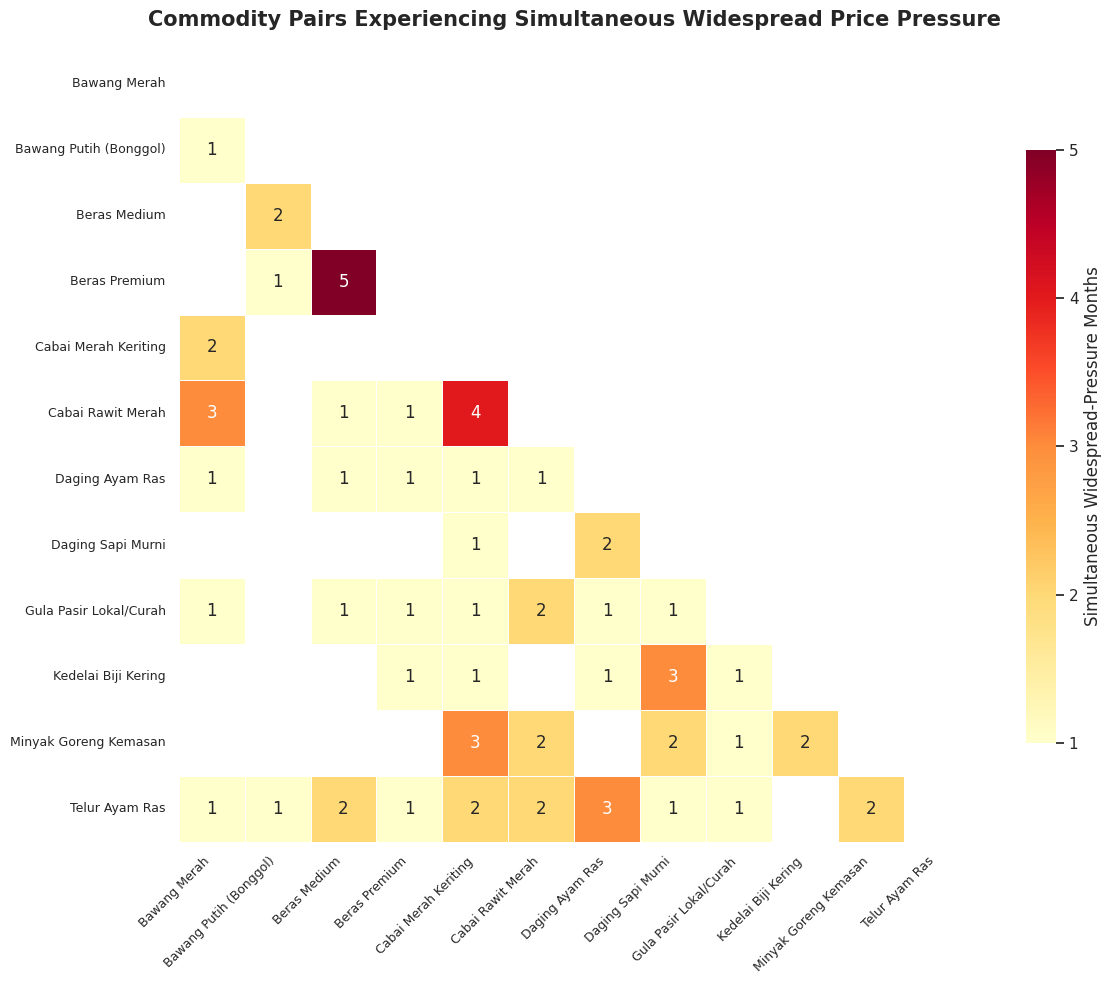

In [ ]:
pair_matrix = pd.DataFrame(
    0.0,
    index=commodities,
    columns=commodities
)

# Fill the matrix symmetrically
for _, row in bq8_commodity_pair_cooccurrence.iterrows():
    commodity_a = row["commodity_a"]
    commodity_b = row["commodity_b"]
    count = float(row["simultaneous_event_months"])

    pair_matrix.loc[commodity_a, commodity_b] = count
    pair_matrix.loc[commodity_b, commodity_a] = count

# Force identical row and column order
pair_matrix = pair_matrix.loc[
    commodities,
    commodities
]

# Maximum observed frequency should be 5
maximum_count = int(
    bq8_commodity_pair_cooccurrence[
        "simultaneous_event_months"
    ].max()
)

# Hide diagonal, upper triangle, and zero-value cells
upper_triangle = np.triu(
    np.ones(
        pair_matrix.shape,
        dtype=bool
    ),
    k=0
)

zero_cells = pair_matrix.to_numpy() == 0

heatmap_mask = upper_triangle | zero_cells

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(13, 10))

sns.heatmap(
    pair_matrix,
    mask=heatmap_mask,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    vmin=1,
    vmax=maximum_count,
    linewidths=0.7,
    linecolor="white",
    square=True,
    cbar_kws={
        "label": "Simultaneous Widespread-Pressure Months",
        "ticks": list(range(1, maximum_count + 1)),
        "shrink": 0.75
    },
    ax=ax
)

ax.set_title(
    "Commodity Pairs Experiencing Simultaneous Widespread Price Pressure",
    fontsize=15,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("")
ax.set_ylabel("")

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment="right",
    fontsize=9
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=9
)

plt.tight_layout()
plt.show()

### **Business Question 8 Conclusion**

The strongest simultaneous price-pressure pattern occurred between **Beras Medium and Beras Premium**. These commodities experienced widespread pressure together in **5 months**, representing **55.56%** of the months in which either commodity experienced widespread pressure. Their lift value of **6.15** indicates that their simultaneous occurrence was substantially more frequent than expected under independent timing.

The second-strongest relationship was observed between **Cabai Merah Keriting and Cabai Rawit Merah**, with **4 simultaneous months**, a Jaccard similarity of **40.00%**, and a lift of **4.92**.

Several other commodity pairs experienced widespread pressure together in three months, including:

- Bawang Merah and Cabai Rawit Merah
- Daging Sapi Murni and Kedelai Biji Kering
- Cabai Merah Keriting and Minyak Goreng Kemasan
- Daging Ayam Ras and Telur Ayam Ras

Seven months recorded widespread pressure in four commodities simultaneously. Among them, **November 2023** had the greatest average geographical breadth at **74.78%**, followed by **April 2022** at **70.72%**. Both months contained at least one commodity whose price pressure affected all eligible provinces.

These findings suggest that some commodities should be monitored as related groups because widespread price pressure frequently emerges during the same months. However, simultaneous timing represents a descriptive association and does not establish a causal relationship between commodity prices.

# Business Question 9: Did Regional Price Disparities Return to Normal After a Shock or Remain Persistently Wide?

This analysis evaluates whether differences in commodity prices across provinces narrowed after a widespread price shock or remained unusually large.

Regional price disparity is measured using therelative interquartile range (relative IQR)

This measure represents the price gap between the middle 50% of provinces relative to the commodity's median price. It is less sensitive to extreme provincial values than the full price range and allows comparison across commodities with different price levels.

For each commodity, the normal disparity threshold is defined as the **75th percentile of relative IQR during non-widespread months**. After a widespread shock:

- **Returned to normal:** disparity is at or below the normal threshold.
- **Persistently wide:** disparity remains above the normal threshold.
- **Unavailable:** the required follow-up month is outside the analysis period.

Disparity conditions are evaluated three and six months after each widespread shock. Only shock events with a complete six-month follow-up period are included in the final comparison.

In [ ]:
available_tables = con.sql("""
    SHOW TABLES
""").df()

display(available_tables)

,name
0,bq1_monthly_price_index
1,bq3_classified_shocks
2,bq3_commodity_spike_thresholds
3,bq3_monthly_shock_breadth
4,bq4_shock_priority
5,bq5_early_signal_events
6,bq5_province_ranking
7,bq6_province_recovery_ranking
8,bq6_spike_recovery_events
9,bq7_commodity_persistence


In [ ]:
tables_to_inspect = [
    "food_prices_longitudinal",
    "bq3_classified_shocks"
]

for table_name in tables_to_inspect:
    print(f"\nTable: {table_name}")
    display(con.sql(f"DESCRIBE {table_name}").df())

    print("Sample rows:")
    display(con.sql(f"""
        SELECT *
        FROM {table_name}
        LIMIT 3
    """).df())


Table: food_prices_longitudinal


,column_name,column_type,null,key,default,extra
0,Kode Provinsi,BIGINT,YES,None,None,None
1,Nama Provinsi,VARCHAR,YES,None,None,None
2,Komoditas,VARCHAR,YES,None,None,None
3,Tahun,BIGINT,YES,None,None,None
4,Bulan,VARCHAR,YES,None,None,None
5,Harga,BIGINT,YES,None,None,None
6,Bulan_Angka,BIGINT,YES,None,None,None
7,Tanggal,TIMESTAMP_NS,YES,None,None,None
8,Coverage_Percentage,DOUBLE,YES,None,None,None
9,Eligible_for_Series_Analysis,BOOLEAN,YES,None,None,None


Sample rows:


,Kode Provinsi,Nama Provinsi,Komoditas,Tahun,Bulan,Harga,Bulan_Angka,Tanggal,Coverage_Percentage,Eligible_for_Series_Analysis,Price_Status
0,11,Aceh,Bawang Merah,2021,Januari,33853,1,2021-01-01,100.00,True,Observed
1,11,Aceh,Bawang Merah,2021,Februari,31971,2,2021-02-01,100.00,True,Observed
2,11,Aceh,Bawang Merah,2021,Maret,33891,3,2021-03-01,100.00,True,Observed



Table: bq3_classified_shocks


,column_name,column_type,null,key,default,extra
0,commodity,VARCHAR,YES,None,None,None
1,price_date,DATE,YES,None,None,None
2,year,INTEGER,YES,None,None,None
3,month_number,INTEGER,YES,None,None,None
4,spike_threshold_pct,DOUBLE,YES,None,None,None
5,valid_mom_provinces,BIGINT,YES,None,None,None
6,spike_provinces,INTEGER,YES,None,None,None
7,shock_breadth_pct,DOUBLE,YES,None,None,None
8,median_spike_intensity_pct,DOUBLE,YES,None,None,None
9,maximum_spike_intensity_pct,DOUBLE,YES,None,None,None


Sample rows:


,commodity,price_date,year,month_number,spike_threshold_pct,valid_mom_provinces,spike_provinces,shock_breadth_pct,median_spike_intensity_pct,maximum_spike_intensity_pct,median_breadth_threshold,p75_breadth_threshold,shock_classification
0,Bawang Merah,2021-02-01,2021,2,21.21,32,0,0.00,NaN,NaN,9.53,29.59,No spike
1,Bawang Merah,2021-03-01,2021,3,21.21,32,1,3.13,21.68,21.68,9.53,29.59,Isolated spike
2,Bawang Merah,2021-04-01,2021,4,21.21,32,0,0.00,NaN,NaN,9.53,29.59,No spike


Shock events are classified as follows:

- **Within normal range at shock:** regional disparity did not exceed the normal threshold during the widespread shock.
- **Returned to normal:** disparity exceeded the normal threshold during the shock but fell to or below it during the follow-up period.
- **Persistently wide:** disparity exceeded the normal threshold during the shock and remained above it during the follow-up period.
- **Unavailable:** the required follow-up month is outside the analysis period.

In [ ]:
con.sql("""
CREATE OR REPLACE TABLE bq9_monthly_disparity AS
SELECT
    "Komoditas" AS commodity,
    CAST("Tanggal" AS DATE) AS price_date,
    COUNT("Harga") AS provinces_observed,
    QUANTILE_CONT("Harga", 0.25) AS q1_price,
    MEDIAN("Harga") AS median_price,
    QUANTILE_CONT("Harga", 0.75) AS q3_price,
    100.0 * (
        QUANTILE_CONT("Harga", 0.75)
        - QUANTILE_CONT("Harga", 0.25)
    ) / NULLIF(MEDIAN("Harga"), 0) AS relative_iqr_pct
FROM food_prices_longitudinal
WHERE
    "Eligible_for_Series_Analysis" = TRUE
    AND "Harga" IS NOT NULL
    AND CAST("Tanggal" AS DATE)
        BETWEEN DATE '2021-01-01' AND DATE '2025-12-01'

    -- Exclude the previously identified invalid observation
    AND NOT (
        "Kode Provinsi" = 11
        AND "Komoditas" = 'Cabai Merah Keriting'
        AND CAST("Tanggal" AS DATE) = DATE '2022-03-01'
    )
GROUP BY
    "Komoditas",
    CAST("Tanggal" AS DATE)
""")

con.sql("""
CREATE OR REPLACE TABLE bq9_normal_disparity_thresholds AS
SELECT
    d.commodity,
    QUANTILE_CONT(d.relative_iqr_pct, 0.75)
        AS normal_disparity_threshold_pct
FROM bq9_monthly_disparity AS d
LEFT JOIN bq3_classified_shocks AS s
    ON d.commodity = s.commodity
    AND d.price_date = s.price_date
WHERE
    COALESCE(LOWER(s.shock_classification), '')
        NOT LIKE '%widespread%'
GROUP BY d.commodity
""")

con.sql("""
CREATE OR REPLACE TABLE bq9_shock_disparity_events AS
SELECT
    s.commodity,
    s.price_date AS shock_date,
    s.shock_breadth_pct,
    t.normal_disparity_threshold_pct,

    pre.relative_iqr_pct AS pre_shock_relative_iqr_pct,
    current.relative_iqr_pct AS shock_relative_iqr_pct,
    month_3.relative_iqr_pct AS relative_iqr_3m_pct,
    month_6.relative_iqr_pct AS relative_iqr_6m_pct,

    CASE
        WHEN current.relative_iqr_pct
             <= t.normal_disparity_threshold_pct
            THEN 'Within normal range at shock'
        WHEN month_3.relative_iqr_pct
             <= t.normal_disparity_threshold_pct
            THEN 'Returned to normal'
        ELSE 'Persistently wide'
    END AS status_after_3m,

    CASE
        WHEN current.relative_iqr_pct
             <= t.normal_disparity_threshold_pct
            THEN 'Within normal range at shock'
        WHEN month_6.relative_iqr_pct
             <= t.normal_disparity_threshold_pct
            THEN 'Returned to normal'
        ELSE 'Persistently wide'
    END AS status_after_6m

FROM bq3_classified_shocks AS s

JOIN bq9_monthly_disparity AS current
    ON s.commodity = current.commodity
    AND s.price_date = current.price_date

LEFT JOIN bq9_monthly_disparity AS pre
    ON s.commodity = pre.commodity
    AND pre.price_date =
        CAST(s.price_date - INTERVAL 1 MONTH AS DATE)

JOIN bq9_monthly_disparity AS month_3
    ON s.commodity = month_3.commodity
    AND month_3.price_date =
        CAST(s.price_date + INTERVAL 3 MONTH AS DATE)

JOIN bq9_monthly_disparity AS month_6
    ON s.commodity = month_6.commodity
    AND month_6.price_date =
        CAST(s.price_date + INTERVAL 6 MONTH AS DATE)

JOIN bq9_normal_disparity_thresholds AS t
    ON s.commodity = t.commodity

WHERE
    LOWER(s.shock_classification) LIKE '%widespread%'
    AND s.price_date <= DATE '2025-06-01'
""")

validation_bq9 = con.sql("""
SELECT
    (SELECT COUNT(*) FROM bq9_monthly_disparity)
        AS commodity_month_rows,
    (SELECT COUNT(DISTINCT commodity)
     FROM bq9_monthly_disparity)
        AS commodities,
    (SELECT COUNT(*)
     FROM bq9_shock_disparity_events)
        AS widespread_events_with_full_followup,
    (SELECT COUNT(*)
     FROM bq9_shock_disparity_events
     WHERE shock_relative_iqr_pct >
           normal_disparity_threshold_pct)
        AS shocks_with_elevated_disparity
""").df()

display(validation_bq9)

bq9_overall_results = con.sql("""
SELECT
    '3 months' AS follow_up_period,
    status_after_3m AS disparity_status,
    COUNT(*) AS event_count,
    ROUND(
        100.0 * COUNT(*) /
        SUM(COUNT(*)) OVER (),
        2
    ) AS percentage_of_events
FROM bq9_shock_disparity_events
GROUP BY status_after_3m

UNION ALL

SELECT
    '6 months' AS follow_up_period,
    status_after_6m AS disparity_status,
    COUNT(*) AS event_count,
    ROUND(
        100.0 * COUNT(*) /
        SUM(COUNT(*)) OVER (),
        2
    ) AS percentage_of_events
FROM bq9_shock_disparity_events
GROUP BY status_after_6m

ORDER BY
    follow_up_period,
    event_count DESC
""").df()

display(bq9_overall_results)

,commodity_month_rows,commodities,widespread_events_with_full_followup,shocks_with_elevated_disparity
0,720,12,77,11


,follow_up_period,disparity_status,event_count,percentage_of_events
0,3 months,Within normal range at shock,66,85.71
1,3 months,Returned to normal,8,10.39
2,3 months,Persistently wide,3,3.90
3,6 months,Within normal range at shock,66,85.71
4,6 months,Returned to normal,6,7.79
5,6 months,Persistently wide,5,6.49


In [ ]:
con.sql("""
CREATE OR REPLACE TABLE bq9_commodity_disparity_summary AS
SELECT
    commodity,

    COUNT(*) AS widespread_events,

    SUM(
        CASE
            WHEN shock_relative_iqr_pct >
                 normal_disparity_threshold_pct
            THEN 1 ELSE 0
        END
    ) AS elevated_disparity_events,

    ROUND(
        100.0 * SUM(
            CASE
                WHEN shock_relative_iqr_pct >
                     normal_disparity_threshold_pct
                THEN 1 ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS elevated_disparity_rate_pct,

    SUM(
        CASE
            WHEN shock_relative_iqr_pct >
                 normal_disparity_threshold_pct
             AND status_after_3m = 'Returned to normal'
            THEN 1 ELSE 0
        END
    ) AS returned_to_normal_3m,

    SUM(
        CASE
            WHEN shock_relative_iqr_pct >
                 normal_disparity_threshold_pct
             AND status_after_3m = 'Persistently wide'
            THEN 1 ELSE 0
        END
    ) AS persistently_wide_3m,

    ROUND(
        100.0 * SUM(
            CASE
                WHEN shock_relative_iqr_pct >
                     normal_disparity_threshold_pct
                 AND status_after_3m = 'Persistently wide'
                THEN 1 ELSE 0
            END
        ) / NULLIF(
            SUM(
                CASE
                    WHEN shock_relative_iqr_pct >
                         normal_disparity_threshold_pct
                    THEN 1 ELSE 0
                END
            ),
            0
        ),
        2
    ) AS persistent_rate_3m_pct,

    SUM(
        CASE
            WHEN shock_relative_iqr_pct >
                 normal_disparity_threshold_pct
             AND status_after_6m = 'Returned to normal'
            THEN 1 ELSE 0
        END
    ) AS returned_to_normal_6m,

    SUM(
        CASE
            WHEN shock_relative_iqr_pct >
                 normal_disparity_threshold_pct
             AND status_after_6m = 'Persistently wide'
            THEN 1 ELSE 0
        END
    ) AS persistently_wide_6m,

    ROUND(
        100.0 * SUM(
            CASE
                WHEN shock_relative_iqr_pct >
                     normal_disparity_threshold_pct
                 AND status_after_6m = 'Persistently wide'
                THEN 1 ELSE 0
            END
        ) / NULLIF(
            SUM(
                CASE
                    WHEN shock_relative_iqr_pct >
                         normal_disparity_threshold_pct
                    THEN 1 ELSE 0
                END
            ),
            0
        ),
        2
    ) AS persistent_rate_6m_pct

FROM bq9_shock_disparity_events
GROUP BY commodity
ORDER BY
    persistently_wide_6m DESC,
    elevated_disparity_events DESC,
    commodity
""")

bq9_commodity_results = con.sql("""
SELECT *
FROM bq9_commodity_disparity_summary
""").df()

display(bq9_commodity_results)


bq9_transition_results = con.sql("""
SELECT
    CASE
        WHEN status_after_3m = 'Returned to normal'
         AND status_after_6m = 'Returned to normal'
            THEN 'Normal at both checkpoints'

        WHEN status_after_3m = 'Returned to normal'
         AND status_after_6m = 'Persistently wide'
            THEN 'Normal at 3m, widened again by 6m'

        WHEN status_after_3m = 'Persistently wide'
         AND status_after_6m = 'Returned to normal'
            THEN 'Wide at 3m, normal by 6m'

        WHEN status_after_3m = 'Persistently wide'
         AND status_after_6m = 'Persistently wide'
            THEN 'Wide at both checkpoints'
    END AS disparity_transition,

    COUNT(*) AS event_count,

    ROUND(
        100.0 * COUNT(*) / SUM(COUNT(*)) OVER (),
        2
    ) AS percentage_of_elevated_events

FROM bq9_shock_disparity_events
WHERE
    shock_relative_iqr_pct >
    normal_disparity_threshold_pct
GROUP BY disparity_transition
ORDER BY event_count DESC
""").df()

display(bq9_transition_results)

bq9_persistent_events = con.sql("""
SELECT
    commodity,
    shock_date,
    ROUND(shock_breadth_pct, 2) AS shock_breadth_pct,
    ROUND(normal_disparity_threshold_pct, 2)
        AS normal_threshold_pct,
    ROUND(pre_shock_relative_iqr_pct, 2)
        AS pre_shock_iqr_pct,
    ROUND(shock_relative_iqr_pct, 2)
        AS shock_iqr_pct,
    ROUND(relative_iqr_3m_pct, 2)
        AS iqr_3m_pct,
    ROUND(relative_iqr_6m_pct, 2)
        AS iqr_6m_pct,
    ROUND(
        relative_iqr_6m_pct
        - normal_disparity_threshold_pct,
        2
    ) AS gap_above_normal_6m_pct

FROM bq9_shock_disparity_events
WHERE
    shock_relative_iqr_pct >
        normal_disparity_threshold_pct
    AND status_after_6m = 'Persistently wide'
ORDER BY
    gap_above_normal_6m_pct DESC,
    shock_date
""").df()

display(bq9_persistent_events)

,commodity,widespread_events,elevated_disparity_events,elevated_disparity_rate_pct,returned_to_normal_3m,persistently_wide_3m,persistent_rate_3m_pct,returned_to_normal_6m,persistently_wide_6m,persistent_rate_6m_pct
0,Daging Sapi Murni,6,2.00,33.33,1.00,1.00,50.00,0.00,2.00,100.00
1,Gula Pasir Lokal/Curah,7,3.00,42.86,2.00,1.00,33.33,2.00,1.00,33.33
2,Kedelai Biji Kering,7,1.00,14.29,1.00,0.00,0.00,0.00,1.00,100.00
3,Minyak Goreng Kemasan,6,1.00,16.67,1.00,0.00,0.00,0.00,1.00,100.00
4,Bawang Putih (Bonggol),7,2.00,28.57,1.00,1.00,50.00,2.00,0.00,0.00
5,Bawang Merah,6,1.00,16.67,1.00,0.00,0.00,1.00,0.00,0.00
6,Cabai Merah Keriting,7,1.00,14.29,1.00,0.00,0.00,1.00,0.00,0.00
7,Beras Medium,7,0.00,0.00,0.00,0.00,NaN,0.00,0.00,NaN
8,Beras Premium,6,0.00,0.00,0.00,0.00,NaN,0.00,0.00,NaN
9,Cabai Rawit Merah,5,0.00,0.00,0.00,0.00,NaN,0.00,0.00,NaN


,disparity_transition,event_count,percentage_of_elevated_events
0,Normal at both checkpoints,5,45.45
1,"Normal at 3m, widened again by 6m",3,27.27
2,Wide at both checkpoints,2,18.18
3,"Wide at 3m, normal by 6m",1,9.09


,commodity,shock_date,shock_breadth_pct,normal_threshold_pct,pre_shock_iqr_pct,shock_iqr_pct,iqr_3m_pct,iqr_6m_pct,gap_above_normal_6m_pct
0,Minyak Goreng Kemasan,2022-03-01,81.25,10.69,12.10,12.51,9.91,22.09,11.40
1,Daging Sapi Murni,2023-04-01,31.25,11.62,13.93,14.13,12.28,12.72,1.10
2,Daging Sapi Murni,2022-05-01,62.50,11.62,9.56,11.86,9.85,12.25,0.63
3,Kedelai Biji Kering,2021-02-01,43.33,11.95,13.95,17.56,10.55,12.57,0.61
4,Gula Pasir Lokal/Curah,2022-02-01,56.25,5.70,5.71,5.96,5.75,5.90,0.20


In [ ]:
con.sql("""
CREATE OR REPLACE TABLE bq9_elevated_disparity_events AS
SELECT
    *,
    CASE
        WHEN pre_shock_relative_iqr_pct IS NULL
            THEN 'Pre-shock condition unavailable'

        WHEN pre_shock_relative_iqr_pct >
             normal_disparity_threshold_pct
            THEN 'Already wide before shock'

        ELSE 'Became wide during shock'
    END AS disparity_timing
FROM bq9_shock_disparity_events
WHERE
    shock_relative_iqr_pct >
    normal_disparity_threshold_pct
""")

# disparity timing n six-month condition
bq9_timing_summary = con.sql("""
SELECT
    disparity_timing,
    status_after_6m,
    COUNT(*) AS event_count,
    ROUND(
        100.0 * COUNT(*) / SUM(COUNT(*)) OVER (),
        2
    ) AS percentage_of_elevated_events
FROM bq9_elevated_disparity_events
GROUP BY
    disparity_timing,
    status_after_6m
ORDER BY
    disparity_timing,
    event_count DESC
""").df()

display(bq9_timing_summary)

,disparity_timing,status_after_6m,event_count,percentage_of_elevated_events
0,Already wide before shock,Persistently wide,4,36.36
1,Already wide before shock,Returned to normal,2,18.18
2,Became wide during shock,Returned to normal,4,36.36
3,Became wide during shock,Persistently wide,1,9.09


In [ ]:
# crte normalized disparity

bq9_event_trajectory = con.sql("""
SELECT
    commodity,
    shock_date,
    disparity_timing,
    status_after_3m,
    status_after_6m,

    100.0 * shock_relative_iqr_pct
        / normal_disparity_threshold_pct
        AS shock_month,

    100.0 * relative_iqr_3m_pct
        / normal_disparity_threshold_pct
        AS month_3,

    100.0 * relative_iqr_6m_pct
        / normal_disparity_threshold_pct
        AS month_6

FROM bq9_elevated_disparity_events
ORDER BY month_6 DESC
""").df()

display(bq9_event_trajectory)



,commodity,shock_date,disparity_timing,status_after_3m,status_after_6m,shock_month,month_3,month_6
0,Minyak Goreng Kemasan,2022-03-01,Already wide before shock,Returned to normal,Persistently wide,116.95,92.69,206.59
1,Daging Sapi Murni,2023-04-01,Already wide before shock,Persistently wide,Persistently wide,121.61,105.66,109.47
2,Daging Sapi Murni,2022-05-01,Became wide during shock,Returned to normal,Persistently wide,102.08,84.73,105.39
3,Kedelai Biji Kering,2021-02-01,Already wide before shock,Returned to normal,Persistently wide,146.87,88.31,105.12
4,Gula Pasir Lokal/Curah,2022-02-01,Already wide before shock,Persistently wide,Persistently wide,104.48,100.72,103.46
5,Bawang Merah,2024-01-01,Became wide during shock,Returned to normal,Returned to normal,108.52,74.83,100.00
6,Gula Pasir Lokal/Curah,2022-01-01,Became wide during shock,Returned to normal,Returned to normal,100.10,99.68,99.08
7,Gula Pasir Lokal/Curah,2023-11-01,Became wide during shock,Returned to normal,Returned to normal,101.43,88.04,80.69
8,Bawang Putih (Bonggol),2023-02-01,Already wide before shock,Returned to normal,Returned to normal,106.86,54.06,58.70
9,Cabai Merah Keriting,2021-12-01,Became wide during shock,Returned to normal,Returned to normal,107.41,52.32,50.56


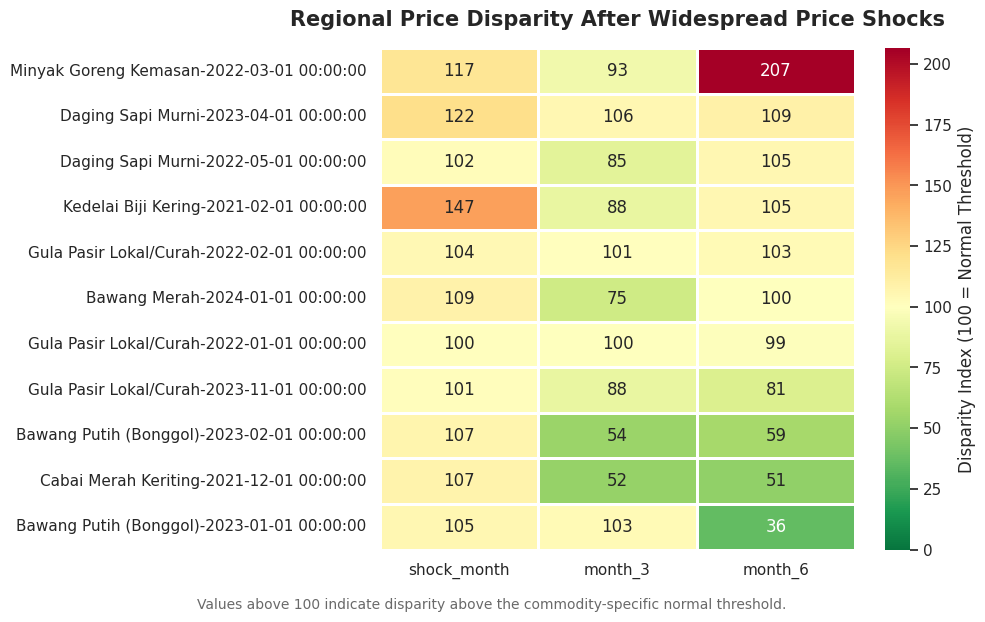

In [ ]:
trajectory_matrix = bq9_event_trajectory.set_index([
    "commodity",
    "shock_date"
])[[ "shock_month", "month_3", "month_6"]]

maximum_deviation = max(
    abs(trajectory_matrix.min().min() - 100),
    abs(trajectory_matrix.max().max() - 100)
)

color_minimum = max(0, 100 - maximum_deviation)
color_maximum = 100 + maximum_deviation

# plot event-level disparity
plt.figure(figsize=(10, max(6, len(trajectory_matrix) * 0.55)))

ax = sns.heatmap(
    trajectory_matrix,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn_r",
    center=100,
    vmin=color_minimum,
    vmax=color_maximum,
    linewidths=0.8,
    linecolor="white",
cbar_kws={
        "label": "Disparity Index (100 = Normal Threshold)"
    }
)

ax.set_title(
    "Regional Price Disparity After Widespread Price Shocks",
    fontsize=15,
    fontweight="bold",
    pad=16
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)

plt.figtext(
    0.5,
    -0.02,
    "Values above 100 indicate disparity above the commodity-specific normal threshold.",
    ha="center",
    fontsize=10,
    color="dimgray"
)

plt.tight_layout()
plt.show()

### **Business Question 9 Conclusion**

Widespread price pressure did not usually produce unusually large regional price disparities. Of the **77 widespread shock events** with a complete six-month follow-up period, **66 events (85.71%)** remained within their commodity-specific normal disparity range during the shock month.

Only **11 events** recorded regional disparity above the normal threshold during a widespread shock. Among these events:

- **8 events (72.73%)** were within the normal range after three months.
- **6 events (54.55%)** were within the normal range after six months.
- **5 events (45.45%)** remained above the normal threshold after six months.

The lower normalization rate at six months indicates that disparity recovery was not always permanent. Five events were normal at both follow-up checkpoints, while three returned to normal after three months but widened again by the sixth month. Two remained wide at both checkpoints, and one showed delayed normalization between the third and sixth month.

The timing analysis provides an important distinction. Of the 11 elevated-disparity events:

- Six were already above the normal threshold before the widespread shock.
- Five became unusually wide during the shock.
- Four of the five disparities that emerged during the shock returned to normal within six months.
- Four of the five events that remained wide after six months had already been wide before the shock.

This suggests that persistent regional price gaps were more commonly associated with pre-existing disparity than with disparity newly emerging during a widespread shock.

The most pronounced case was **Minyak Goreng Kemasan in March 2022**. Its disparity briefly fell below the normal threshold after three months but increased to approximately **207% of the normal threshold** after six months. **Daging Sapi Murni** also recorded two events that remained above normal after six months.

Overall, widespread price pressure and regional price disparity represent different dimensions of food-price risk. A shock may affect many provinces simultaneously without substantially widening provincial price gaps. When abnormal disparity emerged during a shock, it generally normalized, while persistent cases were more likely to reflect regional differences that were already present beforehand.

These results are descriptive. They do not establish that widespread shocks caused regional disparities, and the commodity-level percentages should be interpreted cautiously because only 11 events recorded elevated disparity.

# Business Question 10: Which Province–Commodity Combinations Should Be Prioritized in the Monitoring Watchlist?

This analysis integrates the previous findings into a province–commodity monitoring watchlist.

Each eligible province–commodity combination is evaluated using six dimensions:

1. **Spike magnitude:** the median magnitude of detected monthly price spikes.
2. **Spike frequency:** the proportion of valid months classified as price spikes.
3. **Geographical breadth:** the average percentage of provinces simultaneously experiencing a spike when the combination recorded a spike.
4. **Persistence:** the proportion of spike events that did not recover within six months.
5. **Recovery duration:** the average number of months required for recovery, with unrecovered events assigned a value beyond the six-month observation window.
6. **Regional disparity:** the average absolute percentage difference between the provincial price and the corresponding commodity-month median.

Because these indicators use different units, each measure is converted into a percentile score from 0 to 100. The final monitoring score is calculated as the equal-weighted average of the six percentile scores.

Equal weighting is used to avoid implying that one risk dimension is inherently more important without an official policy basis.

The final score is classified using empirical percentile boundaries:

- **Priority:** score at or above the 90th percentile
- **High:** score from the 75th to below the 90th percentile
- **Moderate:** score from the 50th to below the 75th percentile
- **Lower:** score below the 50th percentile

The resulting categories are project-specific analytical indicators and should not be interpreted as official government classifications.

To reduce instability from small recovery-event samples, the persistence and recovery-duration measures are adjusted toward their overall averages using three pseudo-events. Combinations supported by many recovery events retain most of their observed values, while estimates based on only one or two events receive stronger adjustment. Raw values remain available for interpretation and transparency.

In [ ]:
watchlist_source_tables = [
    "longitudinal_price_changes",
    "bq3_commodity_spike_thresholds",
    "bq3_monthly_shock_breadth",
    "bq6_spike_recovery_events"
]

for table_name in watchlist_source_tables:
    print(f"\n{'=' * 70}")
    print(f"Table: {table_name}")
    print(f"{'=' * 70}")

    display(
        con.sql(f"""
            DESCRIBE {table_name}
        """).df()
    )

    print("Sample rows:")
    display(
        con.sql(f"""
            SELECT *
            FROM {table_name}
            LIMIT 3
        """).df()
    )


Table: longitudinal_price_changes


,column_name,column_type,null,key,default,extra
0,province_code,INTEGER,YES,None,None,None
1,province_name,VARCHAR,YES,None,None,None
2,commodity,VARCHAR,YES,None,None,None
3,price_date,DATE,YES,None,None,None
4,year,INTEGER,YES,None,None,None
5,month_number,INTEGER,YES,None,None,None
6,raw_price,DOUBLE,YES,None,None,None
7,price,DOUBLE,YES,None,None,None
8,data_quality_flag,VARCHAR,YES,None,None,None
9,coverage_percentage,DOUBLE,YES,None,None,None


Sample rows:


,province_code,province_name,commodity,price_date,year,month_number,raw_price,price,data_quality_flag,coverage_percentage,eligible_for_series_analysis,previous_month_price,previous_month_date,previous_year_price,previous_year_date,mom_change_pct,yoy_change_pct
0,15,Jambi,Beras Premium,2021-01-01,2021,1,"12,323.00","12,323.00",Valid observed price,100.00,True,NaN,NaT,NaN,NaT,NaN,NaN
1,15,Jambi,Beras Premium,2021-02-01,2021,2,"12,249.00","12,249.00",Valid observed price,100.00,True,"12,323.00",2021-01-01,NaN,NaT,-0.60,NaN
2,15,Jambi,Beras Premium,2021-03-01,2021,3,"12,001.00","12,001.00",Valid observed price,100.00,True,"12,249.00",2021-02-01,NaN,NaT,-2.02,NaN



Table: bq3_commodity_spike_thresholds


...

,commodity,price_date,year,month_number,spike_threshold_pct,valid_mom_provinces,spike_provinces,shock_breadth_pct,median_spike_intensity_pct,maximum_spike_intensity_pct
0,Bawang Merah,2021-02-01,2021,2,21.21,32,0,0.00,NaN,NaN
1,Bawang Merah,2021-03-01,2021,3,21.21,32,1,3.13,21.68,21.68
2,Bawang Merah,2021-04-01,2021,4,21.21,32,0,0.00,NaN,NaN



Table: bq6_spike_recovery_events


,column_name,column_type,null,key,default,extra
0,province_code,INTEGER,YES,None,None,None
1,province_name,VARCHAR,YES,None,None,None
2,commodity,VARCHAR,YES,None,None,None
3,spike_date,DATE,YES,None,None,None
4,pre_spike_price,DOUBLE,YES,None,None,None
5,spike_price,DOUBLE,YES,None,None,None
6,spike_change_pct,DOUBLE,YES,None,None,None
7,recovery_target_price,DOUBLE,YES,None,None,None
8,recovery_date,DATE,YES,None,None,None
9,recovery_months,BIGINT,YES,None,None,None


Sample rows:


,province_code,province_name,commodity,spike_date,pre_spike_price,spike_price,spike_change_pct,recovery_target_price,recovery_date,recovery_months,month_6_price,recovery_status
0,51,Bali,Bawang Putih (Bonggol),2021-02-01,"21,601.00","22,993.00",6.44,"21,879.40",NaT,<NA>,"23,602.00",Continued price increase
1,51,Bali,Cabai Merah Keriting,2021-02-01,"40,250.00","62,909.00",56.30,"44,781.80",2021-05-01,3,"26,679.00",Gradual recovery
2,51,Bali,Kedelai Biji Kering,2021-02-01,"10,277.00","10,677.00",3.89,"10,357.00",NaT,<NA>,"11,707.00",Continued price increase


In [ ]:
# Spike magnitude, frequency, and geographical breadth


con.sql("""
CREATE OR REPLACE TABLE bq10_spike_metrics AS
WITH detected_spikes AS (
    SELECT
        p.province_code,
        p.province_name,
        p.commodity,
        p.price_date,
        p.mom_change_pct,
        t.spike_threshold_pct,
        b.shock_breadth_pct,

        CASE
            WHEN p.mom_change_pct >= t.spike_threshold_pct
            THEN 1 ELSE 0
        END AS is_spike

    FROM longitudinal_price_changes AS p

    JOIN bq3_commodity_spike_thresholds AS t
        ON p.commodity = t.commodity

    LEFT JOIN bq3_monthly_shock_breadth AS b
        ON p.commodity = b.commodity
        AND p.price_date = b.price_date

    WHERE
        p.eligible_for_series_analysis = TRUE
        AND p.mom_change_pct IS NOT NULL
        AND p.price_date BETWEEN
            DATE '2021-01-01' AND DATE '2025-12-01'
)

SELECT
    province_code,
    province_name,
    commodity,

    COUNT(*) AS valid_mom_months,
    SUM(is_spike) AS spike_events,

    ROUND(
        100.0 * SUM(is_spike) / COUNT(*),
        2
    ) AS spike_frequency_pct,

    ROUND(
        MEDIAN(
            CASE
                WHEN is_spike = 1
                THEN mom_change_pct
            END
        ),
        2
    ) AS median_spike_magnitude_pct,

    ROUND(
        AVG(
            CASE
                WHEN is_spike = 1
                THEN shock_breadth_pct
            END
        ),
        2
    ) AS average_shock_breadth_pct

FROM detected_spikes
GROUP BY
    province_code,
    province_name,
    commodity
""")

In [ ]:
# Persistence and recovery duration

con.sql("""
CREATE OR REPLACE TABLE bq10_recovery_metrics AS
SELECT
    province_code,
    province_name,
    commodity,

    COUNT(*) AS recovery_eligible_events,

    SUM(
        CASE
            WHEN recovery_months IS NULL
            THEN 1 ELSE 0
        END
    ) AS unrecovered_events,

    ROUND(
        100.0 * SUM(
            CASE
                WHEN recovery_months IS NULL
                THEN 1 ELSE 0
            END
        ) / COUNT(*),
        2
    ) AS unrecovered_rate_pct,

    ROUND(
        AVG(
            COALESCE(recovery_months, 7)
        ),
        2
    ) AS monitoring_duration_months

FROM bq6_spike_recovery_events
GROUP BY
    province_code,
    province_name,
    commodity
""")

In [ ]:
# Province-level regional price disparity

con.sql("""
CREATE OR REPLACE TABLE bq10_regional_disparity_metrics AS
WITH commodity_month_medians AS (
    SELECT
        commodity,
        price_date,
        MEDIAN(price) AS national_median_price

    FROM longitudinal_price_changes

    WHERE
        eligible_for_series_analysis = TRUE
        AND price IS NOT NULL
        AND price_date BETWEEN
            DATE '2021-01-01' AND DATE '2025-12-01'

    GROUP BY
        commodity,
        price_date
),

province_month_disparity AS (
    SELECT
        p.province_code,
        p.province_name,
        p.commodity,
        p.price_date,

        100.0 * ABS(
            p.price - m.national_median_price
        ) / NULLIF(m.national_median_price, 0)
            AS absolute_price_gap_pct

    FROM longitudinal_price_changes AS p

    JOIN commodity_month_medians AS m
        ON p.commodity = m.commodity
        AND p.price_date = m.price_date

    WHERE
        p.eligible_for_series_analysis = TRUE
        AND p.price IS NOT NULL
)

SELECT
    province_code,
    province_name,
    commodity,

    ROUND(
        AVG(absolute_price_gap_pct),
        2
    ) AS average_regional_disparity_pct

FROM province_month_disparity
GROUP BY
    province_code,
    province_name,
    commodity
""")

In [ ]:
# 4. Combine the six watchlist dimensions

con.sql("""
CREATE OR REPLACE TABLE bq10_watchlist_metrics AS
WITH eligible_combinations AS (
    SELECT DISTINCT
        province_code,
        province_name,
        commodity

    FROM longitudinal_price_changes

    WHERE eligible_for_series_analysis = TRUE
)

SELECT
    e.province_code,
    e.province_name,
    e.commodity,

    COALESCE(s.valid_mom_months, 0)
        AS valid_mom_months,

    COALESCE(s.spike_events, 0)
        AS spike_events,

    COALESCE(s.median_spike_magnitude_pct, 0)
        AS median_spike_magnitude_pct,

    COALESCE(s.spike_frequency_pct, 0)
        AS spike_frequency_pct,

    COALESCE(s.average_shock_breadth_pct, 0)
        AS average_shock_breadth_pct,

    COALESCE(r.recovery_eligible_events, 0)
        AS recovery_eligible_events,

    COALESCE(r.unrecovered_rate_pct, 0)
        AS unrecovered_rate_pct,

    COALESCE(r.monitoring_duration_months, 0)
        AS monitoring_duration_months,

    COALESCE(d.average_regional_disparity_pct, 0)
        AS average_regional_disparity_pct

FROM eligible_combinations AS e

LEFT JOIN bq10_spike_metrics AS s
    ON e.province_code = s.province_code
    AND e.commodity = s.commodity

LEFT JOIN bq10_recovery_metrics AS r
    ON e.province_code = r.province_code
    AND e.commodity = r.commodity

LEFT JOIN bq10_regional_disparity_metrics AS d
    ON e.province_code = d.province_code
    AND e.commodity = d.commodity
""")

In [ ]:
# 5. Convert every dimension into a percentile score

con.sql("""
CREATE OR REPLACE TABLE bq10_component_scores AS
WITH normalized AS (
    SELECT
        *,

        100.0 * PERCENT_RANK() OVER (
            ORDER BY median_spike_magnitude_pct
        ) AS magnitude_score,

        100.0 * PERCENT_RANK() OVER (
            ORDER BY spike_frequency_pct
        ) AS frequency_score,

        100.0 * PERCENT_RANK() OVER (
            ORDER BY average_shock_breadth_pct
        ) AS breadth_score,

        100.0 * PERCENT_RANK() OVER (
            ORDER BY unrecovered_rate_pct
        ) AS persistence_score,

        100.0 * PERCENT_RANK() OVER (
            ORDER BY monitoring_duration_months
        ) AS recovery_duration_score,

        100.0 * PERCENT_RANK() OVER (
            ORDER BY average_regional_disparity_pct
        ) AS disparity_score

    FROM bq10_watchlist_metrics
)

SELECT
    *,

    ROUND(
        (
            magnitude_score
            + frequency_score
            + breadth_score
            + persistence_score
            + recovery_duration_score
            + disparity_score
        ) / 6.0,
        2
    ) AS monitoring_score

FROM normalized
""")

In [ ]:
# Create empirical score thresholds and priority categories

con.sql("""
CREATE OR REPLACE TABLE bq10_score_thresholds AS
SELECT
    QUANTILE_CONT(monitoring_score, 0.50)
        AS p50_score,
    QUANTILE_CONT(monitoring_score, 0.75)
        AS p75_score,
    QUANTILE_CONT(monitoring_score, 0.90)
        AS p90_score
FROM bq10_component_scores
""")

con.sql("""
CREATE OR REPLACE TABLE bq10_monitoring_watchlist AS
SELECT
    s.*,

    CASE
        WHEN s.monitoring_score >= t.p90_score
            THEN 'Priority'
        WHEN s.monitoring_score >= t.p75_score
            THEN 'High'
        WHEN s.monitoring_score >= t.p50_score
            THEN 'Moderate'
        ELSE 'Lower'
    END AS priority_category,

    DENSE_RANK() OVER (
        ORDER BY s.monitoring_score DESC
    ) AS watchlist_rank

FROM bq10_component_scores AS s
CROSS JOIN bq10_score_thresholds AS t
ORDER BY
    monitoring_score DESC,
    province_name,
    commodity
""")

In [ ]:
# final : Validate and inspect the final watchlist

bq10_validation = con.sql("""
SELECT
    COUNT(*) AS province_commodity_combinations,
    COUNT(DISTINCT province_code) AS provinces,
    COUNT(DISTINCT commodity) AS commodities,
    MIN(monitoring_score) AS minimum_score,
    MAX(monitoring_score) AS maximum_score
FROM bq10_monitoring_watchlist
""").df()

display(bq10_validation)


bq10_threshold_results = con.sql("""
SELECT *
FROM bq10_score_thresholds
""").df()

display(bq10_threshold_results)


bq10_category_distribution = con.sql("""
SELECT
    priority_category,
    COUNT(*) AS combinations,
    ROUND(
        100.0 * COUNT(*) / SUM(COUNT(*)) OVER (),
        2
    ) AS percentage
FROM bq10_monitoring_watchlist
GROUP BY priority_category
ORDER BY
    CASE priority_category
        WHEN 'Priority' THEN 1
        WHEN 'High' THEN 2
        WHEN 'Moderate' THEN 3
        ELSE 4
    END
""").df()

display(bq10_category_distribution)


bq10_top20 = con.sql("""
SELECT
    watchlist_rank,
    province_name,
    commodity,
    spike_events,
    recovery_eligible_events,
    ROUND(median_spike_magnitude_pct, 2)
        AS magnitude_pct,
    ROUND(spike_frequency_pct, 2)
        AS frequency_pct,
    ROUND(average_shock_breadth_pct, 2)
        AS breadth_pct,
    ROUND(unrecovered_rate_pct, 2)
        AS unrecovered_pct,
    ROUND(monitoring_duration_months, 2)
        AS monitoring_months,
    ROUND(average_regional_disparity_pct, 2)
        AS disparity_pct,
    monitoring_score,
    priority_category
FROM bq10_monitoring_watchlist
ORDER BY
    watchlist_rank,
    province_name,
    commodity
LIMIT 20
""").df()

display(bq10_top20)

,province_commodity_combinations,provinces,commodities,minimum_score,maximum_score
0,382,32,12,10.06,78.35


,p50_score,p75_score,p90_score
0,49.59,55.34,59.62


,priority_category,combinations,percentage
0,Priority,39,10.21
1,High,57,14.92
2,Moderate,95,24.87
3,Lower,191,50.00


,watchlist_rank,province_name,commodity,spike_events,recovery_eligible_events,magnitude_pct,frequency_pct,breadth_pct,unrecovered_pct,monitoring_months,disparity_pct,monitoring_score,priority_category
0,1,Kalimantan Tengah,Cabai Rawit Merah,3.00,2,80.36,5.08,80.65,100.00,7.00,35.47,78.35,Priority
1,2,Nusa Tenggara Timur,Minyak Goreng Kemasan,7.00,7,10.58,11.86,73.66,85.71,6.71,10.33,75.50,Priority
2,3,Maluku Utara,Minyak Goreng Kemasan,7.00,7,9.03,11.86,65.28,85.71,6.29,18.77,75.11,Priority
3,4,Sulawesi Tenggara,Minyak Goreng Kemasan,6.00,6,10.96,10.17,76.04,83.33,6.50,10.92,71.39,Priority
4,5,Maluku,Minyak Goreng Kemasan,3.00,3,17.37,5.08,71.88,100.00,7.00,16.09,70.38,Priority
5,6,Maluku,Daging Ayam Ras,1.00,1,14.46,1.69,56.25,100.00,7.00,29.77,68.24,Priority
6,7,Kalimantan Barat,Cabai Rawit Merah,4.00,3,65.09,6.78,61.29,66.67,6.33,33.42,68.11,Priority
7,8,Nusa Tenggara Timur,Daging Ayam Ras,1.00,1,19.84,1.69,56.25,100.00,7.00,22.70,68.02,Priority
8,9,Nusa Tenggara Barat,Cabai Merah Keriting,5.00,5,51.21,8.47,55.89,80.00,6.40,14.81,67.98,Priority
9,10,Kalimantan Utara,Minyak Goreng Kemasan,5.00,5,12.78,8.77,87.50,80.00,6.40,5.33,67.72,Priority


In [ ]:
# calculate overall recovery benchmarks
con.sql("""
CREATE OR REPLACE TABLE bq10_recovery_benchmarks AS
SELECT
    100.0 * AVG(
        CASE
            WHEN recovery_months IS NULL
            THEN 1.0 ELSE 0.0
        END
    ) AS overall_unrecovered_rate_pct,

    AVG(
        COALESCE(recovery_months, 7)
    ) AS overall_monitoring_duration_months

FROM bq6_spike_recovery_events
""")

display(
    con.sql("""
        SELECT
            ROUND(overall_unrecovered_rate_pct, 2)
                AS overall_unrecovered_rate_pct,
            ROUND(overall_monitoring_duration_months, 2)
                AS overall_monitoring_duration_months
        FROM bq10_recovery_benchmarks
    """).df()
)

,overall_unrecovered_rate_pct,overall_monitoring_duration_months
0,59.78,5.41


In [ ]:
con.sql("""
CREATE OR REPLACE TABLE bq10_adjusted_metrics AS
SELECT
    w.*,

    ROUND(
        (
            w.recovery_eligible_events
                * w.unrecovered_rate_pct
            + 3.0
                * b.overall_unrecovered_rate_pct
        ) / (
            w.recovery_eligible_events + 3.0
        ),
        2
    ) AS adjusted_unrecovered_rate_pct,

    ROUND(
        (
            w.recovery_eligible_events
                * w.monitoring_duration_months
            + 3.0
                * b.overall_monitoring_duration_months
        ) / (
            w.recovery_eligible_events + 3.0
        ),
        2
    ) AS adjusted_monitoring_duration_months,

    ROUND(
        100.0 * w.recovery_eligible_events
        / (w.recovery_eligible_events + 3.0),
        2
    ) AS recovery_evidence_weight_pct,

    CASE
        WHEN w.recovery_eligible_events >= 5
            THEN 'Stronger evidence'
        WHEN w.recovery_eligible_events >= 3
            THEN 'Moderate evidence'
        ELSE 'Limited evidence'
    END AS recovery_evidence

FROM bq10_watchlist_metrics AS w
CROSS JOIN bq10_recovery_benchmarks AS b
""")

In [ ]:
# recalculate component scores using adjusted recovery measures

con.sql("""
CREATE OR REPLACE TABLE bq10_component_scores AS
WITH normalized AS (
    SELECT
        *,

        100.0 * PERCENT_RANK() OVER (
            ORDER BY median_spike_magnitude_pct
        ) AS magnitude_score,

        100.0 * PERCENT_RANK() OVER (
            ORDER BY spike_frequency_pct
        ) AS frequency_score,

        100.0 * PERCENT_RANK() OVER (
            ORDER BY average_shock_breadth_pct
        ) AS breadth_score,

        100.0 * PERCENT_RANK() OVER (
            ORDER BY adjusted_unrecovered_rate_pct
        ) AS persistence_score,

        100.0 * PERCENT_RANK() OVER (
            ORDER BY adjusted_monitoring_duration_months
        ) AS recovery_duration_score,

        100.0 * PERCENT_RANK() OVER (
            ORDER BY average_regional_disparity_pct
        ) AS disparity_score

    FROM bq10_adjusted_metrics
)

SELECT
    *,

    ROUND(
        (
            magnitude_score
            + frequency_score
            + breadth_score
            + persistence_score
            + recovery_duration_score
            + disparity_score
        ) / 6.0,
        2
    ) AS monitoring_score

FROM normalized
""")

In [ ]:
# recalculate empirical category thresholds

con.sql("""
CREATE OR REPLACE TABLE bq10_score_thresholds AS
SELECT
    QUANTILE_CONT(monitoring_score, 0.50)
        AS p50_score,
    QUANTILE_CONT(monitoring_score, 0.75)
        AS p75_score,
    QUANTILE_CONT(monitoring_score, 0.90)
        AS p90_score
FROM bq10_component_scores
""")

con.sql("""
CREATE OR REPLACE TABLE bq10_monitoring_watchlist AS
SELECT
    s.*,

    CASE
        WHEN s.monitoring_score >= t.p90_score
            THEN 'Priority'
        WHEN s.monitoring_score >= t.p75_score
            THEN 'High'
        WHEN s.monitoring_score >= t.p50_score
            THEN 'Moderate'
        ELSE 'Lower'
    END AS priority_category,

    DENSE_RANK() OVER (
        ORDER BY s.monitoring_score DESC
    ) AS watchlist_rank

FROM bq10_component_scores AS s
CROSS JOIN bq10_score_thresholds AS t
ORDER BY
    monitoring_score DESC,
    province_name,
    commodity
""")

In [ ]:
# validate the reliability-adjusted watchlist

bq10_revised_thresholds = con.sql("""
SELECT
    ROUND(p50_score, 2) AS p50_score,
    ROUND(p75_score, 2) AS p75_score,
    ROUND(p90_score, 2) AS p90_score
FROM bq10_score_thresholds
""").df()

display(bq10_revised_thresholds)


bq10_revised_categories = con.sql("""
SELECT
    priority_category,
    COUNT(*) AS combinations,
    ROUND(
        100.0 * COUNT(*) / SUM(COUNT(*)) OVER (),
        2
    ) AS percentage
FROM bq10_monitoring_watchlist
GROUP BY priority_category
ORDER BY
    CASE priority_category
        WHEN 'Priority' THEN 1
        WHEN 'High' THEN 2
        WHEN 'Moderate' THEN 3
        ELSE 4
    END
""").df()

display(bq10_revised_categories)


bq10_revised_top20 = con.sql("""
SELECT
    watchlist_rank,
    province_name,
    commodity,

    spike_events,
    recovery_eligible_events,
    recovery_evidence,

    ROUND(median_spike_magnitude_pct, 2)
        AS magnitude_pct,

    ROUND(spike_frequency_pct, 2)
        AS frequency_pct,

    ROUND(average_shock_breadth_pct, 2)
        AS breadth_pct,

    ROUND(unrecovered_rate_pct, 2)
        AS raw_unrecovered_pct,

    ROUND(adjusted_unrecovered_rate_pct, 2)
        AS adjusted_unrecovered_pct,

    ROUND(adjusted_monitoring_duration_months, 2)
        AS adjusted_monitoring_months,

    ROUND(average_regional_disparity_pct, 2)
        AS disparity_pct,

    monitoring_score,
    priority_category

FROM bq10_monitoring_watchlist
ORDER BY
    watchlist_rank,
    province_name,
    commodity
LIMIT 20
""").df()

display(bq10_revised_top20)

,p50_score,p75_score,p90_score
0,50.20,55.37,60.91


,priority_category,combinations,percentage
0,Priority,39,10.21
1,High,57,14.92
2,Moderate,95,24.87
3,Lower,191,50.00


,watchlist_rank,province_name,commodity,spike_events,recovery_eligible_events,recovery_evidence,magnitude_pct,frequency_pct,breadth_pct,raw_unrecovered_pct,adjusted_unrecovered_pct,adjusted_monitoring_months,disparity_pct,monitoring_score,priority_category
0,1,Nusa Tenggara Timur,Minyak Goreng Kemasan,7.00,7,Stronger evidence,10.58,11.86,73.66,85.71,77.93,6.32,10.33,77.12,Priority
1,2,Kalimantan Tengah,Cabai Rawit Merah,3.00,2,Limited evidence,80.36,5.08,80.65,100.00,75.87,6.05,35.47,76.99,Priority
2,3,Maluku Utara,Minyak Goreng Kemasan,7.00,7,Stronger evidence,9.03,11.86,65.28,85.71,77.93,6.03,18.77,76.07,Priority
3,4,Sulawesi Tenggara,Minyak Goreng Kemasan,6.00,6,Stronger evidence,10.96,10.17,76.04,83.33,75.48,6.14,10.92,72.18,Priority
4,5,Maluku,Minyak Goreng Kemasan,3.00,3,Moderate evidence,17.37,5.08,71.88,100.00,79.89,6.21,16.09,70.73,Priority
5,6,Sulawesi Tenggara,Bawang Putih (Bonggol),4.00,4,Moderate evidence,8.74,6.78,58.47,100.00,82.76,6.32,18.58,68.24,Priority
6,7,Nusa Tenggara Barat,Cabai Merah Keriting,5.00,5,Stronger evidence,51.21,8.47,55.89,80.00,72.42,6.03,14.81,67.89,Priority
7,8,Kalimantan Utara,Minyak Goreng Kemasan,5.00,5,Stronger evidence,12.78,8.77,87.50,80.00,72.42,6.03,5.33,67.63,Priority
8,9,Sulawesi Selatan,Cabai Merah Keriting,7.00,7,Stronger evidence,48.59,11.86,48.40,57.14,57.93,5.92,26.32,67.54,Priority
9,10,Jawa Timur,Bawang Putih (Bonggol),6.00,6,Stronger evidence,10.82,10.17,54.09,83.33,75.48,5.92,14.08,67.02,Priority


In [ ]:
# priority combinations by commodity
bq10_priority_by_commodity = con.sql("""
SELECT
    commodity,
    COUNT(*) AS priority_combinations,
    COUNT(DISTINCT province_code) AS priority_provinces,
    ROUND(AVG(monitoring_score), 2)
        AS average_monitoring_score,
    ROUND(MAX(monitoring_score), 2)
        AS maximum_monitoring_score

FROM bq10_monitoring_watchlist

WHERE priority_category = 'Priority'

GROUP BY commodity

ORDER BY
    priority_combinations DESC,
    average_monitoring_score DESC
""").df()

display(bq10_priority_by_commodity)


# provinces with the largest number of Priority commodities
bq10_priority_by_province = con.sql("""
SELECT
    province_name,
    COUNT(*) AS priority_commodities,
    ROUND(AVG(monitoring_score), 2)
        AS average_monitoring_score,
    ROUND(MAX(monitoring_score), 2)
        AS maximum_monitoring_score

FROM bq10_monitoring_watchlist

WHERE priority_category = 'Priority'

GROUP BY province_name

ORDER BY
    priority_commodities DESC,
    average_monitoring_score DESC,
    province_name

LIMIT 15
""").df()

display(bq10_priority_by_province)

,commodity,priority_combinations,priority_provinces,average_monitoring_score,maximum_monitoring_score
0,Minyak Goreng Kemasan,10,10,68.47,77.12
1,Cabai Merah Keriting,6,6,64.05,67.89
2,Beras Premium,5,5,62.21,64.17
3,Bawang Merah,4,4,61.94,62.64
4,Gula Pasir Lokal/Curah,4,4,61.82,63.65
5,Cabai Rawit Merah,3,3,69.32,76.99
6,Bawang Putih (Bonggol),3,3,66.78,68.24
7,Daging Sapi Murni,2,2,63.36,64.35
8,Daging Ayam Ras,2,2,61.70,61.81


,province_name,priority_commodities,average_monitoring_score,maximum_monitoring_score
0,Kalimantan Tengah,4,66.27,76.99
1,Nusa Tenggara Timur,4,65.18,77.12
2,Jawa Timur,4,63.64,67.02
3,Sulawesi Tenggara,3,67.26,72.18
4,Maluku Utara,2,68.63,76.07
5,Maluku,2,66.27,70.73
6,Sulawesi Selatan,2,65.44,67.54
7,Kalimantan Barat,2,65.14,66.84
8,Kalimantan Timur,2,65.05,65.75
9,Kalimantan Utara,2,65.01,67.63


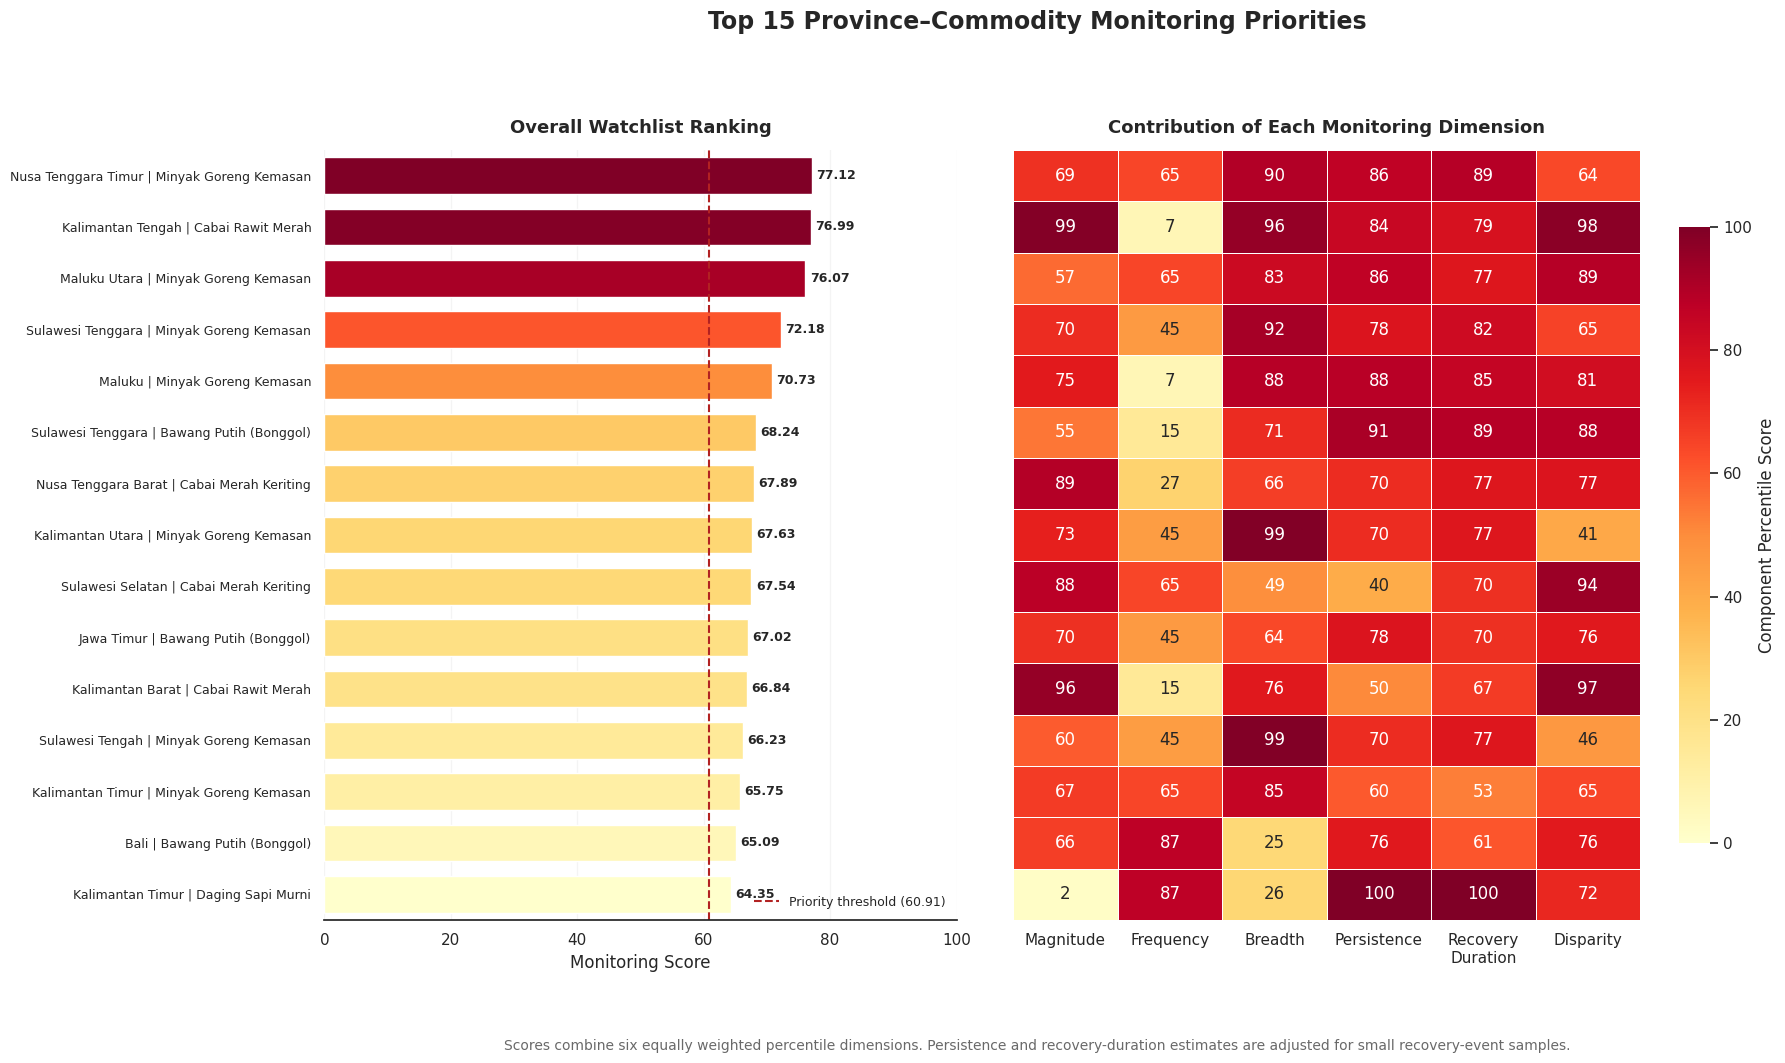

In [ ]:
watchlist_top15 = con.sql("""
SELECT
    watchlist_rank,
    province_name,
    commodity,
    recovery_evidence,
    magnitude_score,
    frequency_score,
    breadth_score,
    persistence_score,
    recovery_duration_score,
    disparity_score,
    monitoring_score

FROM bq10_monitoring_watchlist

ORDER BY
    watchlist_rank,
    province_name,
    commodity

LIMIT 15
""").df()

watchlist_top15["combination"] = (
    watchlist_top15["province_name"]
    + " | "
    + watchlist_top15["commodity"]
)

watchlist_top15 = watchlist_top15.sort_values(
    ["watchlist_rank", "province_name", "commodity"]
).reset_index(drop=True)

component_columns = [
    "magnitude_score",
    "frequency_score",
    "breadth_score",
    "persistence_score",
    "recovery_duration_score",
    "disparity_score"
]

component_labels = [
    "Magnitude",
    "Frequency",
    "Breadth",
    "Persistence",
    "Recovery\nDuration",
    "Disparity"
]

component_matrix = watchlist_top15[
    component_columns
].copy()

component_matrix.columns = component_labels
component_matrix.index = watchlist_top15["combination"]

priority_threshold = float(
    con.sql("""
        SELECT p90_score
        FROM bq10_score_thresholds
    """).fetchone()[0]
)

number_of_rows = len(watchlist_top15)
row_positions = np.arange(number_of_rows) + 0.5

fig, (ax_bar, ax_heatmap) = plt.subplots(
    1,
    2,
    figsize=(19, 10),
    gridspec_kw={
        "width_ratios": [1.25, 1.55],
        "wspace": 0.08
    }
)

# Overall monitoring score

score_normalizer = plt.Normalize(
    watchlist_top15["monitoring_score"].min(),
    watchlist_top15["monitoring_score"].max()
)

bar_colors = plt.cm.YlOrRd(
    score_normalizer(
        watchlist_top15["monitoring_score"]
    )
)

ax_bar.barh(
    row_positions,
    watchlist_top15["monitoring_score"],
    height=0.72,
    color=bar_colors,
    edgecolor="white"
)

ax_bar.axvline(
    priority_threshold,
    color="firebrick",
    linestyle="--",
    linewidth=1.5,
    label=f"Priority threshold ({priority_threshold:.2f})"
)

for position, score in zip(
    row_positions,
    watchlist_top15["monitoring_score"]
):
    ax_bar.text(
        score + 0.7,
        position,
        f"{score:.2f}",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

ax_bar.set_yticks(row_positions)
ax_bar.set_yticklabels(
    watchlist_top15["combination"],
    fontsize=9
)

ax_bar.set_ylim(number_of_rows, 0)
ax_bar.set_xlim(0, 100)
ax_bar.set_xlabel("Monitoring Score")
ax_bar.set_ylabel("")
ax_bar.set_title(
    "Overall Watchlist Ranking",
    fontsize=13,
    fontweight="bold",
    pad=12
)
ax_bar.grid(axis="x", alpha=0.2)
ax_bar.legend(
    loc="lower right",
    frameon=False,
    fontsize=9
)

sns.despine(ax=ax_bar, left=True)

# Panel B: Component percentile scores

sns.heatmap(
    component_matrix,
    ax=ax_heatmap,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    vmin=0,
    vmax=100,
    linewidths=0.7,
    linecolor="white",
    yticklabels=False,
    cbar_kws={
        "label": "Component Percentile Score",
        "shrink": 0.8
    }
)

ax_heatmap.set_xlabel("")
ax_heatmap.set_ylabel("")
ax_heatmap.set_title(
    "Contribution of Each Monitoring Dimension",
    fontsize=13,
    fontweight="bold",
    pad=12
)
ax_heatmap.tick_params(axis="x", rotation=0)

fig.suptitle(
    "Top 15 Province–Commodity Monitoring Priorities",
    fontsize=17,
    fontweight="bold",
    y=1.02
)

fig.text(
    0.5,
    -0.02,
    (
        "Scores combine six equally weighted percentile dimensions. "
        "Persistence and recovery-duration estimates are adjusted "
        "for small recovery-event samples."
    ),
    ha="center",
    fontsize=10,
    color="dimgray"
)

plt.tight_layout()
plt.show()

### **Business Question 10 Conclusion**

The monitoring watchlist evaluated **382 eligible province–commodity combinations** across 32 provinces and 12 commodities. Based on the empirical score distribution:

- **39 combinations (10.21%)** were classified as Priority.
- **57 combinations (14.92%)** were classified as High.
- **95 combinations (24.87%)** were classified as Moderate.
- **191 combinations (50.00%)** were classified as Lower.

The 90th-percentile threshold for the Priority category was a monitoring score of **60.91**.

The highest-ranked combination was **Nusa Tenggara Timur–Minyak Goreng Kemasan**, with a monitoring score of **77.12**. This result was supported by seven recovery-eligible events, relatively frequent spikes, broad geographical pressure, a high adjusted non-recovery rate, and a long adjusted monitoring duration.

**Kalimantan Tengah–Cabai Rawit Merah** ranked second with a score of **76.99**. Its ranking was driven by extremely high spike magnitude, geographical breadth, and regional disparity. However, its recovery indicators were based on only two eligible events, so this combination should be interpreted with greater caution.

**Maluku Utara–Minyak Goreng Kemasan** ranked third with a score of **76.07**, supported by seven recovery-eligible events and high scores across frequency, breadth, persistence, recovery duration, and regional disparity.

Minyak Goreng Kemasan was the most common commodity in the Priority category, appearing in **10 provinces** with an average monitoring score of **68.47**. It was followed by:

- Cabai Merah Keriting: 6 Priority provinces
- Beras Premium: 5 Priority provinces
- Bawang Merah: 4 Priority provinces
- Gula Pasir Lokal/Curah: 4 Priority provinces
- Cabai Rawit Merah: 3 Priority provinces
- Bawang Putih (Bonggol): 3 Priority provinces

Although Cabai Rawit Merah appeared in fewer Priority combinations, it recorded the highest average score among the represented commodities at **69.32**, reflecting the exceptional magnitude of several chili-price shocks.

At the provincial level, **Kalimantan Tengah, Nusa Tenggara Timur, and Jawa Timur** each contained four Priority commodities. Sulawesi Tenggara followed with three. These results indicate that monitoring priorities are geographically concentrated, particularly across several provinces outside Java, although Jawa Timur also displayed multiple commodity-level signals.

The component heatmap demonstrates that combinations can enter the Priority category for different reasons. Some were driven primarily by extreme spike magnitude and regional disparity, while others were driven by repeated spikes, widespread pressure, slow recovery, or persistent elevation. Therefore, the final score should be interpreted together with its component scores rather than as a standalone risk probability.

Reliability adjustment reduced the influence of persistence and recovery estimates based on very small samples. Nevertheless, combinations marked as having limited recovery evidence should still be interpreted cautiously.

Overall, the watchlist provides a structured method for identifying combinations that repeatedly exhibited multiple forms of historical price pressure. It is a relative, project-specific monitoring tool and does not represent an official risk assessment or policy recommendation.

In [ ]:
available_tables = con.execute("""
    SHOW TABLES
""").df()

display(available_tables)

,name
0,bq10_adjusted_metrics
1,bq10_component_scores
2,bq10_monitoring_watchlist
3,bq10_recovery_benchmarks
4,bq10_recovery_metrics
5,bq10_regional_disparity_metrics
6,bq10_score_thresholds
7,bq10_spike_metrics
8,bq10_watchlist_metrics
9,bq1_monthly_price_index


In [ ]:
import sys
!{sys.executable} -m pip install xlsxwriter
powerbi_tables = {
    "Monthly_Prices": "longitudinal_price_changes",
    "Price_Index": "bq1_monthly_price_index",
    "Shock_Events": "bq4_shock_priority",
    "Early_Signals": "bq5_province_ranking",
    "Recovery": "bq6_province_recovery_ranking",
    "Persistence": "bq7_commodity_persistence",
    "Cooccurrence": "bq8_commodity_pair_cooccurrence",
    "Disparity": "bq9_shock_disparity_events",
    "Watchlist": "bq10_monitoring_watchlist"
}

output_file = "food_price_monitoring_powerbi.xlsx"

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    for sheet_name, table_name in powerbi_tables.items():
        table_df = con.execute(
            f'SELECT * FROM "{table_name}"'
        ).df()

        table_df.to_excel(
            writer,
            sheet_name=sheet_name,
            index=False
        )

        worksheet = writer.sheets[sheet_name]

        if len(table_df) > 0:
            worksheet.add_table(
                0,
                0,
                len(table_df),
                len(table_df.columns) - 1,
                {
                    "name": f"tbl_{sheet_name}",
                    "columns": [
                        {"header": column}
                        for column in table_df.columns
                    ]
                }
            )

            for column_number, column_name in enumerate(table_df.columns):
                column_width = min(
                    max(len(str(column_name)) + 2, 12),
                    30
                )
                worksheet.set_column(
                    column_number,
                    column_number,
                    column_width
                )

print(f"File berhasil dibuat: {output_file}")
files.download(output_file)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 2.1 MB/s eta 0:00:00
File berhasil dibuat: food_price_monitoring_powerbi.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>